# Case Study 5 — report generation and quality assurance with generative AI

This notebook drafts the part of a Solvency and Financial Condition Report (SFCR) that is written for policy holders — a language model writes the words, code owns every number — and then checks the draft as an external reviewer would: deterministic checks first, LLM checks whose findings stay warnings unless code confirms them, and a human sign-off. It also measures the checker itself, on planted errors, a clean control and a labelled test set for the LLM judge, and ends with a Lithuanian machine translation and its checks.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/simonhatzesberger/advanced-genai-actuarial/blob/main/notebooks/07_cs5_report_qa/07_cs5_report_qa.ipynb)

EAA seminar **E0572 — Advanced Applications of Generative AI in Actuarial Science**, Vilnius, 1–2 October 2026. Lecturer: Dr Simon Hatzesberger.

Repository: [simonhatzesberger/advanced-genai-actuarial](https://github.com/simonhatzesberger/advanced-genai-actuarial)

Unlike Case Studies 1 to 4, this case study is not one of the article's. It takes up a proposal of the article's Sect. 7.2 — to draft SFCR and risk reports with language models — for one regulated document, and adds the checks such a draft needs:

> Hatzesberger S, Nonneman I (2026) Advanced applications of generative AI in actuarial science: case studies beyond ChatGPT. *European Actuarial Journal* 16(2):481–523. https://doi.org/10.1007/s13385-026-00464-9

**The legal basis.** Directive (EU) 2025/2 splits the SFCR into a part for policy holders and beneficiaries and a part for market professionals (Art. 51(1), second subparagraph, of Directive 2009/138/EC, as replaced; Art. 51(1a) lists what the policyholder part must contain). Commission Delegated Regulation (EU) 2026/269 says what the policyholder part must contain — new Art. 292 of Delegated Regulation (EU) 2015/35: a language notice at the start, fixed elements, a prescribed definition of the two capital requirements and at most five pages — and adds Art. 298a on translations, with a duty to disclose a machine translation. Both acts apply from 30 January 2027. Section 3 quotes the provisions from the Official Journal, in English and in Lithuanian, as retrieved on 23 September 2026; `data/README.md` lists the sources. Two points rest on less than the text of the acts, and the notebook says so where they matter: that the SFCR for financial year 2027 is the first in the new format is EIOPA's stated view, not a provision, and the Regulation defines no page format for the five-page cap.

**A working-group prototype.** Two ideas of the checking design — the LLM extracts and Python decides, and a checker is measured on planted errors and a clean control — also run through a working-group prototype for validating a technical actuarial document. Section 7 comes back to it. None of its code or text is used here.

**The business problem.** Reports turn numbers into narrative, and every page of them has to be checked before it is published. The new policyholder part of the SFCR is a short, prescribed, public text that every Solvency II insurer will publish, as a rule once a year — only a captive that meets the conditions of Art. 51(3) is exempt — and, if it sells across borders, translate on request. A language model drafts such a text in seconds. The questions that remain are the actuary's: does every figure agree with the figures the actuary signed, does every stated cause have a source, is the prescribed legal text there word for word, does the part fit five pages — and who signs it.

**What the notebook does.** The document is the policyholder part for Brisendale Mutual, a fictitious Irish mutual that sells motor and home insurance and does business in Lithuania under the freedom to provide services. Its year-end 2026 and 2025 figures are synthetic, and the report is labelled a dry run of the new format. GPT-6 Luna drafts the text with placeholders; code fills in the numbers and inserts the fixed texts (section 4). Twelve deterministic checks (section 5) and five LLM checks plus a blind read of the chart (section 6) examine the result. Sections 7 and 8 measure the checks: 16 planted errors, 6 of them planted by a different model after the checks were frozen, a clean control, and 30 labelled sentences for the LLM judge. Section 9 translates the document into Lithuanian and checks the translation, and section 10 is the sign-off.

**Reading it and running it.** Like the other notebooks, this one ships with its outputs, so every result can be read without a key. Four things run live, as in the room: the arithmetic check of the warm-up (no key needed), the draft, one checking cell on the gold document, the planted document and your own draft, and exercise (a), whose deterministic part needs no key either. Everything that needs no model runs live as well, without a key: every deterministic check, the gate on the gold, planted and fresh documents in section 5.4 and the checks of the Lithuanian text in section 9 among them, and — because `RUN_MUTANTS_LIVE` is on by default — the mutant sweep of section 5.5, which takes about 30 seconds and prints the recorded result beside its own (`RUN_MUTANTS_LIVE = False` reads the sweep from the recording). In the saved run the live calls — 16 of them — cost USD 0.0094 at list prices, or USD 0.0086 had none of their input been cached. Everything else — five GPT-6 Luna runs and one GPT-6 Sol run of all checks on the gold and planted documents, the judge test, the Lithuanian translation, the blind chart reads and three drafts — was recorded once, on 23 September 2026, and is read from `data/recordings.json`. The case study's build, pilots and three drafts discarded for a gate bug included, cost USD 0.2519 in 167 paid calls, and building this notebook USD 0.0435 more in 90 calls, including its paid test runs (the saved one among them) and the last two recordings. The other `RUN_*` switches of section 1 repeat any of the recorded work live. Without a key, once the key has no credit left, or when the API stops answering, a live cell shows the recording instead and says so. A rerun drafts different words and gets different warnings, and the commentary describes the saved run.

## Learning objectives

After working through this notebook you will be able to:

- **explain** what the new policyholder part of the SFCR must contain, which of its texts are prescribed, and why its figures, its causes and its translation each need a check of their own;
- **draft** a regulated document with a language model while code owns every number, every year and every fixed legal text;
- **check** a document in two layers: deterministic checks first, then LLM checks in which the model extracts or judges, code grounds every quote, and findings stay warnings unless code confirms them;
- **measure** a checker with planted errors in a development and a hold-out batch, a clean control, a mutant sweep and a labelled test set for the LLM judge — and read small counts with intervals rather than as percentages;
- **translate** a regulated document by machine without machine-translating the texts that have an official translation, and check the translation's numbers, prescribed wording and disclosure;
- **sign off** a report with a named decision on every warning, in a log that ties each decision to the document, the checks and the model settings that produced it.

## Contents

1. [Setup](#1-setup)
2. [Warm-up: a check that passes claims nobody can verify](#2-warm-up-a-check-that-passes-claims-nobody-can-verify)
3. [The document and its rules](#3-the-document-and-its-rules)
4. [Drafting: code owns every number](#4-drafting-code-owns-every-number)
5. [Deterministic checks](#5-deterministic-checks)
6. [LLM checks and the blind chart read](#6-llm-checks-and-the-blind-chart-read)
7. [Planted errors, hold-out errors and the clean control](#7-planted-errors-hold-out-errors-and-the-clean-control)
8. [The judge needs its own test set](#8-the-judge-needs-its-own-test-set)
9. [Lithuanian translation](#9-lithuanian-translation)
10. [Sign-off](#10-sign-off)
11. [What to take away](#11-what-to-take-away)
12. [Exercises](#12-exercises)

**Cost.** The saved run cost USD 0.0094 at list prices, all of it in the two live cells of sections 4 and 6: the draft (USD 0.0010) and the checks on three documents (USD 0.0084). Nothing else calls a model unless you switch it on; the session as a whole is capped at USD 0.50, checked before every call. The bundle of files the notebook needs (about 0.2 MB) and its recordings (about 1 MB) are read from `data/` next to the notebook; in Colab they are downloaded once from GitHub into `_local/data/`. In Colab, `_local/` lives on the temporary machine and is lost when the session ends.

---

## 1 Setup

### Why it matters for actuaries

A check of a report can be repeated and audited only if everything around it is fixed and written down: the package versions, the models and their settings, the prices used to cost each call, the cap on what the session may spend, the checksum of every input file, and the version of the checks. That version is the one frozen before the hold-out errors of section 7 were planted, plus three changes made afterwards, which are applied and logged as such. This section fixes all of them before anything calls a model.

Four cells, run once. The first checks the packages this notebook uses and installs, at its pinned version, only a package whose import fails. The second holds everything you may want to change — the `RUN_*` switches, the session cap and the switch for the example sign-off of section 10 — and then fixes the models, their settings and their prices, finds your key without ever printing it, and sets up a ledger that records the tokens and the cost of every paid call, cache writes included. The third fetches the notebook's bundle and its recordings once, checks every file against a published checksum, and unpacks the bundle into `_local/cs5_bundle/`. The fourth applies the three changes made to the checks after they were frozen, and lists them. If you change a switch or the cap later, run the second cell again: the ledger keeps the calls already paid for, and the new cap and client reach the call module at once.

Colab ships every package used here; on your own machine, `requirements.txt` in the repository pins them. Read an `[ATTENTION]` in the first cell's output as information, not as an error: on Colab, for example, `openai` 2.54 differs from the pin, and the notebook runs regardless.

In [1]:
# Colab already ships every package this notebook uses. A package is installed, at its pinned version,
# only if its import fails - on Colab and on a local install from requirements.txt nothing is installed.
import importlib.util
import platform
from importlib.metadata import PackageNotFoundError, version

PINS = {  # import name: the pin in the repository's requirements.txt
    "openai": "openai==3.14.0",
    "pandas": "pandas==2.2.3",
    "numpy": "numpy==2.1.3",
    "matplotlib": "matplotlib==3.10.0",
    "PIL": "pillow==11.3.0",
}
missing = " ".join(pin for module, pin in PINS.items() if importlib.util.find_spec(module) is None)
if missing:
    %pip install -q {missing}

mismatches = 0
for pin in PINS.values():
    name, pinned = pin.split("==")
    try:
        installed = version(name)
    except PackageNotFoundError:
        installed = "not installed"
    if installed == pinned:
        print(f"[PASS]      {name:<11} {installed}")
    else:
        mismatches += 1
        print(f"[ATTENTION] {name:<11} installed {installed}, pinned {pinned}")
print(f"            {'Python':<11} {platform.python_version()}")
if mismatches:
    print(f"{mismatches} of {len(PINS)} packages differ from their pins. The notebook usually runs regardless; if a")
    print("cell fails, install the pinned versions from the repository's requirements.txt and restart the session.")

[PASS]      openai      3.14.0
[PASS]      pandas      2.2.3
[PASS]      numpy       2.1.3
[PASS]      matplotlib  3.10.0
[PASS]      pillow      11.3.0
            Python      3.13.15


A few words on the models and their settings before the cell that fixes them.

| Role | Model | Reasoning effort | `temperature` |
| --- | --- | --- | --- |
| The draft, the LLM checks, the blind chart read and the translation | `gpt-6-luna` | `none` | 0 |
| The hold-out errors of section 7 (two calls), one comparison run of the checks and one of the judge test (all recorded) | `gpt-6-sol` | `low` | not sent |

- **GPT-6 Luna and GPT-6 Sol** are the cheapest and a larger model of OpenAI's GPT-6 family. Both exist only under these aliases, not as dated snapshots, so their behaviour may change without their names changing — one more reason to record runs and keep them.
- **`temperature=0`.** GPT-6 models accept a temperature only at reasoning effort `none`; at `low` or higher they reject the parameter. Luna therefore gets `temperature=0` and Sol none. It makes the answers more repeatable, not identical: section 4 shows three drafts of the same facts, and section 7 five runs of the same checks.
- **Prices.** In USD per million tokens — input, cached input, input written to the cache, output: Luna 0.10, 0.01, 0.125, 0.50; Sol 2.00, 0.20, 2.50, 10.00. These are OpenAI's list prices for standard processing, retrieved from its pricing page on 22 September 2026. Images are billed as input tokens. The ledger shows two figures: what a call cost, and what it would have cost with every input token at the ordinary input price.
- **The cap.** `SESSION_CAP_USD` limits everything this session pays for. It is checked *before* every call, against the worst case — the estimated input at the input price plus the most output the call may return at the output price — and counts the worst case of every call still under way, so that calls sent in parallel cannot pass it together. A call that could break the cap is not sent.
- **`store=False`** on every call: nothing is kept on OpenAI's side for later retrieval, as one would want for an unpublished report.

In [2]:
import hashlib
import inspect
import json
import os
import re
import shutil
import sys
import tempfile
import threading
import time
import urllib.error
import urllib.request
import zipfile
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
from datetime import datetime, timezone
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import openai
import pandas as pd
from IPython.display import Image, Markdown, display
from openai import OpenAI

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 200)

# ---- What you may want to change ------------------------------------------------------------------
LIVE_DRAFT = True             # section 4: GPT-6 Luna drafts the part live if a key is visible, else the recorded draft
LIVE_CHECKS = True            # section 6: the LLM checks run live on gold, planted and your draft (about USD 0.006)
RUN_VISION_LIVE = False       # section 6: the blind chart read live as well (about USD 0.0002 per read)
RUN_MUTANTS_LIVE = True       # section 5: the mutant sweep of 220 one-error documents (no API; about 30 seconds)
RUN_REPEATS_LIVE = False      # section 7: N_REPEATS more Luna runs of all checks on gold and planted (about USD 0.004 each)
N_REPEATS = 2
RUN_JUDGE_LIVE = False        # section 8: the judge test live with GPT-6 Luna (about USD 0.0012)
RUN_TRANSLATION_LIVE = False  # section 9: the Lithuanian translation live (about USD 0.0014); L-TRANS stays recorded
RUN_EXERCISE_LLM = False      # exercise (a): the LLM checks on your planted document too (about USD 0.002)
RUN_EXERCISE_C_LIVE = False   # exercise (c): the reference prompt live (a prompt of your own always runs live)
USE_POST_HOC = True           # the three changes made after the freeze (section 1); False gives the frozen checks
SIGN_WITH_EXAMPLES = False    # section 10: True logs the example decisions of 10.2 as if a reviewer had taken them
SESSION_CAP_USD = 0.50        # all paid calls of this session together, checked before every call

# ---- The models -----------------------------------------------------------------------------------
SOL, LUNA = "gpt-6-sol", "gpt-6-luna"  # aliases: there are no dated snapshots
EFFORT = {SOL: "low", LUNA: "none"}    # reasoning effort of each model
TEMPERATURE = 0                         # GPT-6 accepts a temperature only at reasoning effort "none"

# List prices in USD per million tokens: (input, cached input, cache write, output).
# OpenAI pricing page, standard processing, as retrieved on 22 September 2026.
PRICES_USD_PER_MTOK = {LUNA: (0.10, 0.01, 0.125, 0.50), SOL: (2.00, 0.20, 2.50, 10.00)}

LOCAL_DIR = Path("_local")    # machine-local downloads next to this notebook, never committed
DATA_DIR = Path("data")       # the committed data files next to this notebook
RAW_DATA_URL = ("https://raw.githubusercontent.com/simonhatzesberger/advanced-genai-actuarial/main/"
                "notebooks/07_cs5_report_qa/data/")
LOCAL_DIR.mkdir(exist_ok=True)


def sampling_options(effort: str) -> dict:
    # GPT-6 accepts a temperature only at reasoning effort "none"; at any other effort it is left out.
    options = {"reasoning": {"effort": effort}}
    if effort == "none":
        options["temperature"] = TEMPERATURE
    return options


def find_api_key(name: str = "OPENAI_API_KEY") -> str | None:
    """Return the key if this environment can see one, otherwise None. Never raises."""
    try:
        from google.colab import userdata  # available on Colab only

        value = userdata.get(name)
        if value:
            return value
    except Exception:
        # Not on Colab, or the secret does not exist, or notebook access is off.
        pass
    return os.environ.get(name) or None


key = find_api_key()
# Retries are handled by the bundle's call module (cs5_llm.call, configured in the third cell); the client does not retry.
# A request that takes longer than 60 seconds counts as failed: the longest recorded call took 18.7 seconds.
client = OpenAI(api_key=key, max_retries=0, timeout=60) if key else None
NO_CREDIT = globals().get("NO_CREDIT", {"flag": False})  # the same dict on a re-run: the call module holds it
NO_CREDIT["flag"] = False  # set once the key reports that it has no credit left; a re-run asks the key again

LEDGER: list[dict] = globals().get("LEDGER", [])  # one row per API call that came back with a response in this session;
# a re-run of this cell keeps the calls already paid for, so that the cap and the bill cover the whole session
_LEDGER_LOCK = threading.Lock()


def log_usage(model: str, purpose: str, input_tokens: int, cached_tokens: int = 0, output_tokens: int = 0,
              cache_write_tokens: int = 0) -> dict:
    """Record one paid call in the ledger and return its row, with the cost in USD at the list prices above."""
    price_in, price_cached, price_write, price_out = PRICES_USD_PER_MTOK[model]
    row = {
        "purpose": purpose,
        "model": model,
        "input_tokens": input_tokens,
        "cached_tokens": cached_tokens,
        "cache_write_tokens": cache_write_tokens,
        "output_tokens": output_tokens,
        "cost_usd": ((input_tokens - cached_tokens - cache_write_tokens) * price_in + cached_tokens * price_cached
                     + cache_write_tokens * price_write + output_tokens * price_out) / 1e6,
        # With no caching at all, every input token pays the input price: nothing is read from or written to the cache.
        "cost_usd_no_cache": (input_tokens * price_in + output_tokens * price_out) / 1e6,
    }
    with _LEDGER_LOCK:
        LEDGER.append(row)
    return row


def session_cost() -> float:
    """USD spent in this session so far, from the ledger."""
    return sum(row["cost_usd"] for row in LEDGER)


def spend_report() -> pd.DataFrame:
    """Calls, tokens and cost of everything this session has paid for, by purpose."""
    counts = ["calls", "input_tokens", "cached_tokens", "cache_write_tokens", "output_tokens"]
    costs = ["cost_usd", "cost_usd_no_cache"]
    if not LEDGER:
        print("No paid calls in this session.")
        return pd.DataFrame(columns=counts + costs)
    table = (
        pd.DataFrame(LEDGER)
        .groupby(["purpose", "model"], sort=False)
        .agg(calls=("cost_usd", "size"), input_tokens=("input_tokens", "sum"), cached_tokens=("cached_tokens", "sum"),
             cache_write_tokens=("cache_write_tokens", "sum"), output_tokens=("output_tokens", "sum"),
             cost_usd=("cost_usd", "sum"), cost_usd_no_cache=("cost_usd_no_cache", "sum"))
    )
    table.loc[("total", ""), :] = table.sum()
    table[counts] = table[counts].astype(int)
    return table.round({column: 5 for column in costs})


def short_error(exc: Exception) -> str:
    """One line describing a failed call. It never repeats a key, not even a masked one."""
    text = re.sub(r"sk-[A-Za-z0-9_\-*]{4,}", "sk-***", " ".join(str(exc).split()))
    return f"{type(exc).__name__}: {text[:160]}"


if key:
    print(f"[PASS] A key named OPENAI_API_KEY is visible ({len(key)} characters long).")
    print("       Its value is never printed - not here, not anywhere.")
else:
    print("[ATTENTION] No key named OPENAI_API_KEY is visible to this notebook.")
    print("            The live cells of sections 4 and 6 show recorded runs instead; everything else runs without")
    print("            a key. Notebook 00, section 6 explains how to add one.")

# Which models can this key use? Looking a model up costs nothing.
AVAILABLE = {}
for model in (LUNA, SOL):
    if client is None:
        AVAILABLE[model] = False
        continue
    try:
        client.models.retrieve(model)
        AVAILABLE[model] = True
        print(f"[PASS]      {model:<11} available to this key")
    except openai.NotFoundError:
        AVAILABLE[model] = False
        print(f"[ATTENTION] {model:<11} not visible to this key - its cells show recorded runs")
    except Exception as exc:
        AVAILABLE[model] = False
        print(f"[ATTENTION] {model:<11} could not be checked ({short_error(exc)})")


def can_call(model: str = LUNA) -> bool:
    # A model is called live if this key can see it and still has credit; otherwise the cells show recordings.
    return client is not None and AVAILABLE.get(model, False) and not NO_CREDIT["flag"]


switches = [name for name, value in list(globals().items()) if name.startswith("RUN_") and value is True]
print(f"Models      : {LUNA} (effort '{EFFORT[LUNA]}', temperature {TEMPERATURE}); {SOL} (effort '{EFFORT[SOL]}')")
print(f"Live cells  : draft {'on' if LIVE_DRAFT else 'off'}, checks {'on' if LIVE_CHECKS else 'off'}; "
      f"RUN_* switches on: {', '.join(switches) or 'none'}")
print(f"Session cap : USD {SESSION_CAP_USD:.2f}, checked before every call")
print(f"Local cache : {LOCAL_DIR.as_posix()}/ (next to where the notebook runs)")

if "llm" in globals():  # a re-run of this cell: hand the new client, cap and ledger to the call module at once
    llm.configure(client=client if can_call(LUNA) else None, book=log_usage, session_cap_usd=SESSION_CAP_USD,
                  session_cost=session_cost, no_credit=NO_CREDIT)
    print(f"Call module : reconfigured; {len(LEDGER)} paid call(s) of this session kept, USD {session_cost():.6f}")

[PASS] A key named OPENAI_API_KEY is visible (164 characters long).
       Its value is never printed - not here, not anywhere.


[PASS]      gpt-6-luna  available to this key


[PASS]      gpt-6-sol   available to this key
Models      : gpt-6-luna (effort 'none', temperature 0); gpt-6-sol (effort 'low')
Live cells  : draft on, checks on; RUN_* switches on: RUN_MUTANTS_LIVE
Session cap : USD 0.50, checked before every call
Local cache : _local/ (next to where the notebook runs)


The third cell fetches three files. `cs5_bundle.zip` holds the case study's Python modules and documents: the facts and driver bullets, the three versions of the document, the charts, the label files and the legal specification. `cs5_bundle_manifest.json` lists every file of the bundle with its checksum, and `recordings.json` holds every recorded run. On your machine the three come from `data/` next to the notebook; in Colab they are downloaded once from GitHub into `_local/data/`. The manifest's own checksum is written into the cell, the manifest holds the checksums of the other two and of every file in the bundle, and a file that does not match is not used.

The modules keep the names and the folder layout they had when the checks were frozen, so that two of them can be compared with the checksums taken at the freeze. They are:

| Module | What it holds | Sections |
| --- | --- | --- |
| `cs5_core` | facts, number formats, document assembly, the parser, the number scanner, the page estimate, the chart | 3–5 |
| `cs5_draft` | the drafting prompt and the drafting gate | 4 |
| `cs5_checks` | the twelve deterministic checks, and `D-PP` for exercise (b) | 5 |
| `cs5_llm`, `cs5_llm_checks` | one structured call with cap, retries, a stop after repeated failures, and ledger; the five LLM checks, the blind chart read and `run_gate()` | 6 |
| `cs5_score`, `cs5_mutants` | scoring against the error log, Wilson intervals, McNemar; the mutant sweep | 5, 7, 8 |
| `cs5_translate` | the Lithuanian translation and its checks | 9 |
| `cs5_signoff` | the sign-off rules and the hash-chained log | 10 |
| `cs5_warmup`, `cs5_exercise` | the warm-up excerpt and its checks; `show_sentences()` and `plant()` | 2, 12 |

In [3]:
MANIFEST_SHA256 = "81c984b60dd48210708c76b6f73d1e5e61702f30fc01b54fbdc913036c038f8d"


def sha256_of(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()


def data_file(name: str, expected_sha256: str | None = None) -> Path | None:
    """A committed data file: from data/ next to this notebook, otherwise downloaded once from GitHub into
    _local/data/. The download is written to a temporary name and renamed only once it is complete."""
    for candidate in (DATA_DIR / name, LOCAL_DIR / "data" / name):
        if candidate.exists():
            path = candidate
            break
    else:
        path = LOCAL_DIR / "data" / name
        path.parent.mkdir(parents=True, exist_ok=True)
        partial = path.with_name(name + ".part")
        try:
            with urllib.request.urlopen(RAW_DATA_URL + name, timeout=120) as response:
                partial.write_bytes(response.read())
            os.replace(partial, path)  # atomic: the file appears under its name only once it is complete
        except Exception as exc:
            partial.unlink(missing_ok=True)
            reason = f"HTTP {exc.code}" if isinstance(exc, urllib.error.HTTPError) else type(exc).__name__
            print(f"[ATTENTION] data/{name} is not next to this notebook, and the download from GitHub failed ({reason}).")
            print(f"            Download it by hand from {RAW_DATA_URL + name}")
            print("            and put it into a folder called data/ next to this notebook (in Colab: the folder icon on the")
            print("            left), then run the cell again.")
            return None
    if expected_sha256 is not None and sha256_of(path) != expected_sha256:
        print(f"[ATTENTION] {path.as_posix()} is not byte-identical to the published file (its checksum differs).")
        print("            Delete it and run the cell again to download a fresh copy.")
        return None
    return path


def unpack_bundle(zip_path: Path, manifest: dict, target: Path) -> int:
    """Unzip the bundle into `target` unless every file is already there with the right checksum; then check
    every file against the manifest. Returns the number of files checked."""
    expected = {f["path"]: f["sha256"] for f in manifest["files"]}

    def all_present() -> bool:
        return all((target / p).is_file() and sha256_of(target / p) == s for p, s in expected.items())

    if not all_present():
        shutil.rmtree(target, ignore_errors=True)
        with zipfile.ZipFile(zip_path) as archive, tempfile.TemporaryDirectory(dir=LOCAL_DIR) as tmp:
            archive.extractall(tmp)
            shutil.move(str(Path(tmp) / manifest["root"].rstrip("/")), str(target))
    bad = [p for p, s in expected.items() if not (target / p).is_file() or sha256_of(target / p) != s]
    if bad:
        raise RuntimeError(f"{len(bad)} files of the bundle do not match the manifest, e.g. {bad[:3]}")
    return len(expected)


manifest_path = data_file("cs5_bundle_manifest.json", expected_sha256=MANIFEST_SHA256)
if manifest_path is None:
    raise FileNotFoundError("cs5_bundle_manifest.json is needed from here on - see the message above.")
MANIFEST = json.loads(manifest_path.read_text(encoding="utf-8"))
zip_path = data_file("cs5_bundle.zip", expected_sha256=MANIFEST["zip_sha256"])
recordings_path = data_file("recordings.json", expected_sha256=MANIFEST["recordings"]["sha256"])
if zip_path is None or recordings_path is None:
    raise FileNotFoundError("cs5_bundle.zip and recordings.json are needed from here on - see the message above.")

BUNDLE_DIR = LOCAL_DIR / "cs5_bundle"
n_checked = unpack_bundle(zip_path, MANIFEST, BUNDLE_DIR)
BUILD_DIR = BUNDLE_DIR / "build"          # the modules and documents, in the layout they were frozen in
(BUILD_DIR / "work").mkdir(exist_ok=True)  # the provenance check D-CHART keeps its reference render here
if str(BUILD_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(BUILD_DIR.resolve()))  # makes the modules importable

import cs5_checks as ch  # noqa: E402  the deterministic checks and the Finding record
import cs5_core as core  # noqa: E402  facts, formats, assembly, parser, numbers, page estimate, chart
import cs5_draft as dr  # noqa: E402  the drafting prompt and the drafting gate
import cs5_exercise as ex  # noqa: E402  show_sentences() and plant()
import cs5_llm as llm  # noqa: E402  one structured call: cap, retries, ledger
import cs5_llm_checks as lc  # noqa: E402  the LLM checks and run_gate()
import cs5_mutants as mu  # noqa: E402  the mutant sweep
import cs5_score as sc  # noqa: E402  scoring, Wilson intervals, McNemar
import cs5_signoff as so  # noqa: E402  sign-off rules and the log
import cs5_translate as tr  # noqa: E402  the Lithuanian translation and its checks
import cs5_warmup as wu  # noqa: E402  the warm-up

RECORDINGS = json.loads(recordings_path.read_text(encoding="utf-8"))
FREEZE = RECORDINGS["meta"]["freeze"]
# The bundle's call module books every call in this notebook's ledger and checks this notebook's cap.
llm.configure(client=client if can_call(LUNA) else None, book=log_usage, session_cap_usd=SESSION_CAP_USD,
              session_cost=session_cost, no_credit=NO_CREDIT)

print(f"[PASS] {manifest_path.as_posix()}: sha256 {MANIFEST_SHA256[:8]}... as published.")
print(f"[PASS] {zip_path.as_posix()}: {MANIFEST['zip_bytes']:,} bytes, sha256 {MANIFEST['zip_sha256'][:8]}... as in the manifest;")
print(f"       unpacked into {BUNDLE_DIR.as_posix()}/, all {n_checked} files byte-identical to the manifest.")
print(f"[PASS] {recordings_path.as_posix()}: {MANIFEST['recordings']['bytes']:,} bytes, sha256 "
      f"{MANIFEST['recordings']['sha256'][:8]}... as in the manifest.")
for name in ("cs5_checks.py", "cs5_llm_checks.py"):
    now = sha256_of(BUILD_DIR / name)
    if now == FREEZE[name]:
        print(f"[PASS] {name:<18} sha256 {now[:12]}... = the version frozen at {FREEZE['frozen_utc']}")
    else:
        print(f"[ATTENTION] {name} differs from the frozen version: its results can differ from the recordings.")

[PASS] data/cs5_bundle_manifest.json: sha256 81c984b6... as published.
[PASS] data/cs5_bundle.zip: 213,660 bytes, sha256 cd45718b... as in the manifest;
       unpacked into _local/cs5_bundle/, all 29 files byte-identical to the manifest.
[PASS] data/recordings.json: 1,072,731 bytes, sha256 f26e2436... as in the manifest.
[PASS] cs5_checks.py      sha256 96c9ecb36a10... = the version frozen at 2026-09-23T10:09:00Z
[PASS] cs5_llm_checks.py  sha256 d3b1cca97c14... = the version frozen at 2026-09-23T10:09:00Z


The two check modules on disk are the ones hashed at the freeze, at 10:09 UTC on 23 September 2026 — before the hold-out errors of section 7 were planted. Three changes were made after that time, when the recordings of the Lithuanian translation and of the five-page cap showed a false alarm, a formatting defect and a page estimate that ran long. They were adopted on 23 September 2026 and are logged as **post-hoc**: they were not part of the checks that the planted errors measured. The cell below applies them at run time, so that the frozen code stays untouched, and `USE_POST_HOC = False` in the setup cell switches them off.

None of the three changes a finding on the English gold or planted documents. PH1 concerns the Lithuanian notice only, and PH2 changes nothing in English, where no value ends in a full stop. PH3 lowers the English page estimates — gold from 2.96 to 2.79 pages, planted from 2.87 to 2.71 — and both stay below the warning at 4.5 pages; among the English documents it changes a finding only on the overflow variant of section 5.6. The recorded runs of section 7 were made with the frozen checks, so the recall figures there are those of the frozen checks either way; sections 5.6 and 9.3 show what each change does.

In [4]:
# ---- The three changes made after the freeze (post-hoc) ------------------------------------------------------
# The frozen rules are captured once per session: a second run of this cell (Run all without a restart) must not
# take the rules that the first run patched in for the frozen ones.
if not hasattr(core, "FROZEN_RULES_CS5"):
    core.FROZEN_RULES_CS5 = {"lt_official_language": ch.NOTICE_KEYS_LT["official language"],
                             "render_placeholders": core.render_placeholders,
                             "lines_per_page": core.PAGE_FORMAT["lines_per_page"]}
FROZEN_RULES = core.FROZEN_RULES_CS5
assert FROZEN_RULES["lines_per_page"] == 50 and FROZEN_RULES["render_placeholders"].__name__ == "render_placeholders", \
    "the frozen rules were overwritten in this session: restart the session and run the notebook again"
POST_HOC_RULES = {"lt_official_language": r"oficial\w*\W+(?:\w+\W+){0,8}?kalb",  # up to 8 words in between
                  "lines_per_page": 53}


def render_placeholders_post_hoc(text: str, facts: dict, lang: str) -> str:
    """The frozen renderer, except that a value ending in a full stop ('proc.', 'proc. punkt.') absorbs the full stop
    that follows the placeholder, so that no sentence ends in '..'. No English value ends in a full stop."""
    index = core.fact_index(facts)

    def fill(match):
        fact_id, stop = match.group(1), match.group(2)
        if fact_id not in index:
            return f"[unknown {fact_id}]" + stop
        shown = index[fact_id]["display_" + lang]
        return shown if stop == "." and shown.endswith(".") else shown + stop

    return re.sub(r"\{\{\s*([^{}\s]+)\s*\}\}(\.?)", fill, text)


def set_rules(post_hoc: bool) -> str:
    """Switch between the frozen checks and the checks with the three post-hoc changes."""
    ch.NOTICE_KEYS_LT["official language"] = POST_HOC_RULES["lt_official_language"] if post_hoc \
        else FROZEN_RULES["lt_official_language"]
    core.render_placeholders = render_placeholders_post_hoc if post_hoc else FROZEN_RULES["render_placeholders"]
    core.PAGE_FORMAT["lines_per_page"] = POST_HOC_RULES["lines_per_page"] if post_hoc else FROZEN_RULES["lines_per_page"]
    return "frozen checks with the three post-hoc changes" if post_hoc else "frozen checks"


POST_HOC_LOG = pd.DataFrame([
    {"change": "PH1 Lithuanian language notice (D-NOTICE)",
     "frozen": "'oficialiąja' and 'kalba' next to each other",
     "after": "up to 8 words between them",
     "why": "the translation writes 'oficialiąja tos ES valstybės narės, kurioje gyvenate, kalba': a false alarm",
     "shown in": "9.3"},
    {"change": "PH2 renderer: no double full stop",
     "frozen": "'708 proc..' at the end of a sentence",
     "after": "'708 proc.'",
     "why": "a Lithuanian value ending in 'proc.' met the sentence's own full stop; no check flagged it",
     "shown in": "9.3"},
    {"change": "PH3 page estimate (D-PAGE)",
     "frozen": "50 lines per page",
     "after": "53 lines per page",
     "why": "read off the eleven typeset variants of section 5.6 after the freeze; the estimate ran long for English",
     "shown in": "5.6"},
]).set_index("change")
RULES = set_rules(USE_POST_HOC)
with pd.option_context("display.max_colwidth", None):
    display(POST_HOC_LOG)
print(f"Rules in force from here on: {RULES}"
      + (" (the three changes were adopted on 23 September 2026, after the freeze)." if USE_POST_HOC
         else f" (the version hashed at the freeze, {FREEZE['frozen_utc']}; the three post-hoc changes are off)."))

,frozen,after,why,shown in
change,,,,
PH1 Lithuanian language notice (D-NOTICE),'oficialiąja' and 'kalba' next to each other,up to 8 words between them,"the translation writes 'oficialiąja tos ES valstybės narės, kurioje gyvenate, kalba': a false alarm",9.3
PH2 renderer: no double full stop,'708 proc..' at the end of a sentence,'708 proc.',a Lithuanian value ending in 'proc.' met the sentence's own full stop; no check flagged it,9.3
PH3 page estimate (D-PAGE),50 lines per page,53 lines per page,read off the eleven typeset variants of section 5.6 after the freeze; the estimate ran long for English,5.6


Rules in force from here on: frozen checks with the three post-hoc changes (the three changes were adopted on 23 September 2026, after the freeze).


---

## 2 Warm-up: a check that passes claims nobody can verify

### Why it matters for actuaries

A review that finds every planted error can still wave through statements that nobody can check. An actuary who signs a report needs both: the errors found, and a list of what could not be verified, with nothing skipped in silence. A multi-agent review demonstration from 2025 — a supervisor agent with a language checker and a calculation checker — found all three errors planted in a short SFCR excerpt and passed every claim that the excerpt gave no means to check. The excerpt below is an abridged English version of the excerpt used there, with its figures and its three planted errors: the wrong expense ratio unchanged, the grammar and spelling errors re-created in English.

### 2.1 The excerpt

The cell prints the excerpt sentence by sentence, each with the id that every check in this notebook uses to say where it found something: `0.p1.s2` is the second sentence of the first paragraph (section `0`, because the excerpt has no lettered sections). It also defines `findings_table()`, which shows the findings of any check in the same format throughout the notebook. Read the excerpt before running the checks: what would you flag?

In [5]:
def as_dicts(findings) -> list[dict]:
    """Findings as dictionaries, whether they come from a live check (Finding objects) or from a recording."""
    return [f.to_dict() if hasattr(f, "to_dict") else dict(f) for f in findings]


def findings_table(findings, width: int = 70) -> pd.DataFrame:
    """One row per finding: which check, how severe, where, the evidence it quotes and its message."""
    rows = as_dicts(findings)
    columns = ["check", "severity", "status", "where", "evidence", "message"]
    if not rows:
        return pd.DataFrame(columns=columns)
    table = pd.DataFrame({
        "check": [f["check_id"] for f in rows],
        "severity": [f["severity"] for f in rows],
        "status": [f["status"] for f in rows],
        "where": [f["sid"] or "(document)" for f in rows],
        "evidence": [f["quote"][:width] for f in rows],
        "message": [f["message"][:width + 20] for f in rows],
    })
    table.index = range(1, len(table) + 1)
    return table


for unit in wu._units(wu.EXCERPT):
    print(f"[{unit.sid}] {unit.text}")

[0.p1.s1] The company's solvency ratio is 175% (eligible own funds EUR 3.5 billion, SCR EUR 2.0 billion).
[0.p1.s2] It is therefore well above the internal target corridor and rose by 5 percentage points year on year.
[0.p2.s1] The expense ratio is 28% (costs EUR 140 million, gross premiums EUR 700 million) and therefore exceeds the target.
[0.p3.s1] The SCR consists of 62% market risk and 38% underwriting risk.
[0.p4.s1] Because of the higher interest rates, the policyholder bonus rates was adjusted.
[0.p4.s2] The surplus partcipation for 2026 was set at a level that protects the company's financial strength.
[0.p5.s1] New business consisted of 40% single premiums and 60% regular premiums.
[0.p5.s2] Sample checks found no material deviations.


### 2.2 The ratio-and-spelling check

The first checker does what the 2025 demonstration did: code recomputes every ratio and every split, and a proofreader reads the text. The arithmetic runs live and needs no key: `w_ratio()` finds every "X% (A, B)" and recomputes A / B with each input varied by half a unit of its last printed digit, and `w_sum()` adds up the parts of a split. The proofreading is an LLM check, `L-SPELL`, recorded with GPT-6 Luna on 23 September 2026.

In [6]:
started = time.perf_counter()
arithmetic = wu.w_ratio(wu.EXCERPT) + wu.w_sum(wu.EXCERPT)
arithmetic_ms = 1000 * (time.perf_counter() - started)

WARMUP = RECORDINGS["warmup"]
proofreading = [ch.Finding(**f) for f in WARMUP["ratio_and_spelling"]["findings"] if f["check_id"] == "L-SPELL"]
ratio_and_spelling = arithmetic + proofreading
with pd.option_context("display.max_colwidth", None):
    display(findings_table(ratio_and_spelling))
print(f"Arithmetic (live, no key)          : {len(arithmetic)} finding(s) in {arithmetic_ms:.1f} milliseconds")
print(f"Proofreading (recorded, GPT-6 Luna): {len(proofreading)} finding(s)")

,check,severity,status,where,evidence,message
1,W-RATIO,error,fail,0.p2.s1,"28% (costs EUR 140 million, gross premiums EUR 700 million)",ratio does not match its inputs
2,L-SPELL,warning,fail,0.p4.s1,rates was,grammar (LLM)
3,L-SPELL,warning,fail,0.p4.s2,partcipation,spelling (LLM)


Arithmetic (live, no key)          : 1 finding(s) in 0.7 milliseconds
Proofreading (recorded, GPT-6 Luna): 2 finding(s)


The arithmetic check finds the expense ratio: 28% printed, where EUR 140 million over EUR 700 million gives 20.0%. The proofreader finds "rates was" and "partcipation". Three planted errors, three findings — the result the 2025 demonstration reported too.

### 2.3 The full gate

The second checker adds three checks that report what cannot be verified, instead of saying nothing about it:

- `W-VERIFY` (code): a change stated without its previous figure, a target or limit that is not given, and an assurance statement without evidence;
- `W-CONSEQ` (code): a conclusion ("therefore", "thus") drawn from a figure that failed a check;
- `L-VERIFY` (an LLM check, recorded): every statement that the excerpt gives no means to check, with a quote that code grounds in the text.

Every "not verifiable" is a finding, reported like an error but with a different status. The cell scores both checkers against the labels written with the excerpt: three planted errors and five statements nobody can verify.

In [7]:
verify_llm = [ch.Finding(**f) for f in WARMUP["full_gate"]["findings"] if f["check_id"] == "L-VERIFY"]
full_gate = ratio_and_spelling + wu.w_verify(wu.EXCERPT) + wu.w_conseq(wu.EXCERPT, arithmetic) + verify_llm
WARMUP_SCORES = {"ratio-and-spelling check": wu.score(ratio_and_spelling), "full gate": wu.score(full_gate)}

display(pd.DataFrame({
    name: {"planted errors found": f"{s['planted_found']} of {len(wu.LABELS['planted_errors'])}",
           "unverifiable statements reported": f"{s['unverifiable_reported']} of {len(wu.LABELS['unverifiable_claims'])}"}
    for name, s in WARMUP_SCORES.items()}).T)

rows = []
for item in wu.LABELS["planted_errors"] + wu.LABELS["unverifiable_claims"]:
    kind = "planted" if item["id"].startswith("W") else "unverifiable"
    rows.append({"id": item["id"], "what": item["what"],
                 **{name: ", ".join(s[kind][item["id"]]) or "-" for name, s in WARMUP_SCORES.items()}})
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(rows).set_index("id"))
conseq = [f for f in full_gate if f.check_id == "W-CONSEQ"]
print(f"W-CONSEQ: {conseq[0].message if conseq else 'no finding'}")
print(f"Recorded LLM calls of the warm-up: USD {WARMUP['usd']:.6f} and {WARMUP['seconds']:.1f} seconds; "
      f"the code checks took {arithmetic_ms:.1f} milliseconds.")

,planted errors found,unverifiable statements reported
ratio-and-spelling check,3 of 3,0 of 5
full gate,3 of 3,5 of 5


,what,ratio-and-spelling check,full gate
id,,,
W1,expense ratio 28% where 140 / 700 = 20%,W-RATIO,W-RATIO
W2,grammar: 'rates was' (subject-verb agreement),L-SPELL,L-SPELL
W3,spelling: 'partcipation',L-SPELL,L-SPELL
V1,'rose by 5 percentage points year on year': no prior-year figure,-,"L-VERIFY, W-VERIFY"
V2,'well above the internal target corridor': no corridor given,-,"L-VERIFY, W-VERIFY"
V3,"'therefore exceeds the target': no target given, and drawn from the wrong 28%",-,"L-VERIFY, W-VERIFY"
V4,'Sample checks found no material deviations': no evidence given,-,"L-VERIFY, W-VERIFY"
V5,'a level that protects the company's financial strength': not checkable,-,L-VERIFY


W-CONSEQ: conclusion drawn from a figure that failed a check; re-assess after correcting the figure
Recorded LLM calls of the warm-up: USD 0.000235 and 4.8 seconds; the code checks took 0.7 milliseconds.


**Both checkers find the three errors; only the full gate says what it could not check.** The ratio-and-spelling check reports 0 of the 5 statements nobody can verify; the full gate reports 5 — 4 of them by code alone (`W-VERIFY`), all 5 by the LLM check. `W-CONSEQ` adds a point no reviewer should miss: "therefore exceeds the target" was concluded from the wrong ratio, so the conclusion has to be re-assessed once the ratio is corrected. A report that passes the first checker has not been checked; it has been proofread and recalculated.

That is the thread of this notebook: what a checker cannot verify has to appear in its output, not disappear from it.

---

## 3 The document and its rules

### Why it matters for actuaries

A checker is only as good as the rules it encodes, and the policyholder part of the SFCR has precise ones: a notice that must come first, elements that must be there, a legal text to be reproduced word for word, eight figures for two dates, and a cap of five pages. Precise rules are good news for automated checks — each can be written as code — and they are also the places where an unchecked language model fails in predictable ways: it paraphrases the legal text, it forgets to say that something is absent, it rounds a figure or attaches it to the wrong year. This section collects the rules and the inputs; sections 5 and 6 turn them into checks.

### 3.1 What Article 292 requires

New Art. 292 of Delegated Regulation (EU) 2015/35, as inserted by Delegated Regulation (EU) 2026/269, in the English text of the Official Journal. The part must start with the notice:

> 1\. The part of the solvency and financial condition report targeted at policy holders and beneficiaries shall start with an indication that policy holders and beneficiaries have the right to request a version of that part in the official language of the Member State where they reside, provided that the insurance or reinsurance undertaking operates in that Member State through the right of establishment or the freedom to provide services.

It needs a section on the business and performance (Art. 292(2), points (a) to (f)), a section on capital management and the risk profile with, among other things,

> (b) the Solvency Capital Requirement and Minimum Capital Requirement, the eligible own funds, and the ratio of coverage both at the end of the reporting period and the previous reporting period;

a prescribed definition of the two capital requirements (Art. 292(3), second subparagraph, quoted in 3.2), a section on other material information (Art. 292(4)), and a length limit:

> 5\. The part of the solvency and financial condition targeted at policy holders and beneficiaries shall not exceed five pages.
>
> Compliance with the first subparagraph shall not result in an omission or the abridgement of the relevant information referred to in paragraphs 1 to 4.

(The word "report" is missing after "financial condition" in the English Official Journal text; the Lithuanian text has it.) New Art. 298a(1) adds, for a translation sent on request:

> Where the translation is generated by a machine translation tool, insurance or reinsurance undertakings shall disclose to that policyholder that that part of the solvency and financial condition report has been machine translated.

Four readings are this notebook's, not the Regulation's. No wording is prescribed for the notice or for the machine-translation disclosure, so both texts are the case study's own. "The eligible own funds" and "the ratio of coverage" are singular; the document shows both for the SCR and for the MCR. A missing figure for the own funds eligible to cover the MCR or for the MCR coverage ratio is a warning, not an error; the SCR, the MCR, the own funds eligible to cover the SCR and the SCR coverage ratio are required for both dates, and a missing one is an error. Art. 292(3)(c) asks for information only where the SCR or the MCR was not complied with during the reporting period or at the time of disclosure, and Art. 292(2)(d) only where the undertaking belongs to a group. The explicit statements that Brisendale Mutual met both requirements and belongs to no group are therefore the case study's own. `D-SPEC` still treats a missing one as an error, so the planted error E07 (section 7), and the mutant operator "drop an element" when it removes one of these statements (5.5), test a house element, not one the Regulation requires of an insurer that complied. And the Regulation defines no page, so every page count before typesetting is an estimate (3.6). The cell lists the elements as `legal/spec.json` records them, with the checks that look for each.

In [8]:
SPEC = core.load_spec()
with pd.option_context("display.max_colwidth", 80):
    display(pd.DataFrame([{"element": e["id"], "source": e["source"],
                           "checked by": ", ".join(dict.fromkeys(re.findall(r"\b[DL]-[A-Z]+\b", e["check"])))}
                          for e in SPEC["elements"]]).set_index("element"))
print(f"Section headings of Annex XX (English | Lithuanian):")
for s in SPEC["structure"]:
    print(f"  {s['id']}. {s['title_en']:<45} | {s['id']}. {s['title_lt']}")

,source,checked by
element,,
A1_language_notice,"Art. 292(1), first sentence",D-NOTICE
A2_language_links,"Art. 292(1), second sentence",D-SPEC
B1_name_legal_form,Art. 292(2)(a),D-SPEC
B2_supervisory_authority,Art. 292(2)(b),D-SPEC
B3_qualifying_holdings,Art. 292(2)(c),D-SPEC
B4_group,Art. 292(2)(d),D-SPEC
B5_significant_events,Art. 292(2)(e),"D-SPEC, L-COVER"
B6_uw_investment_performance,Art. 292(2)(f),"D-SPEC, D-TIE, L-AUDIENCE"
C1_scr_mcr_definition,"Art. 292(3), first subparagraph, point (a), and second subparagraph",D-TEXT


Section headings of Annex XX (English | Lithuanian):
  A. Languages in which this part is available     | A. Kalbos, kuriomis ši dalis pateikiama
  B. Business and Performance                      | B. Veikla ir rezultatai
  C. Capital Management and Risk Profile           | C. Kapitalo valdymas ir rizikos pobūdis
  D. Other information                             | D. Kita informacija


### 3.2 The prescribed text, in English and in Lithuanian

Art. 292(3) says that the definition of the two capital requirements "shall contain the following text". Here it is in both official versions, as `legal/spec.json` holds them.

In [9]:
for lang in ("en", "lt"):
    paragraphs = SPEC["prescribed_text"][lang]["paragraphs"]
    text = " ".join(paragraphs)
    print(f"--- {lang.upper()}: {len(text.split())} words, {len(text)} characters, "
          f"abbreviations SCR/MCR: {'yes' if re.search(r'SCR|MCR', text) else 'none'}")
    for paragraph in paragraphs:
        print(paragraph)
    print()

--- EN: 129 words, 781 characters, abbreviations SCR/MCR: yes
Two capital requirements aim at measuring the financial soundness of the undertaking: the Solvency Capital Requirement (SCR) and the Minimum Capital Requirement (MCR). The SCR should deliver a level of capital that enables an undertaking to absorb significant unforeseen losses over a one-year time horizon and should give reasonable assurance to policy holders that payments will be made as they fall due. The MCR is intended to provide a minimum level of security to be held at all times by the undertaking and below which the amount of financial resources (own funds) should not fall.
The capital requirements will need to be covered by capital (own funds) of sufficient quality to ensure that losses can be covered on a going-concern basis as well as in the event of winding-up

--- LT: 97 words, 799 characters, abbreviations SCR/MCR: none
Siekiant įvertinti įmonės finansinį patikimumą, taikomi du kapitalo reikalavimai: mokumo kapi

Two differences decide how the document is built. The Lithuanian text uses no abbreviations: it writes "mokumo kapitalo reikalavimas" and "minimalaus kapitalo reikalavimas" in full every time, where the English text says "the SCR" and "the MCR". And its quotation marks are „…“ with the full stop inside, where the English text closes with ”. — so a machine translation of the English text cannot reproduce the Lithuanian one. The rule of this notebook follows: **text that has an official version is inserted by code, in every language, and never generated.** The check `D-TEXT` compares it with the official wording after normalising quotation marks, spaces and one final full stop.

### 3.3 Brisendale Mutual and its figures

Brisendale Mutual is a fictitious Irish mutual that sells motor and home insurance; it has no shareholders and belongs to no group, and it does business in Lithuania under the freedom to provide services, without a branch there. That last fact is what makes the right announced by the language notice apply to policyholders and beneficiaries living in Lithuania (Art. 292(1)), and what entitles a policyholder there to the part in Lithuanian on request (Art. 298a(1)), the translation of section 9. The notice itself must open the part in any case. Its supervisor, the home supervisor, is named only by a placeholder, "Home Supervisory Authority", and every address in the document ends in `.example`, a domain reserved so that no link can reach a real site.

`facts.json` holds 65 facts from a seeded generator (seed 20261003). Totals and ratios are derived by code from the rounded amounts, never typed. The generator asserts the tier limits of Art. 82 of Delegated Regulation (EU) 2015/35, and the MCR coverage ratio uses the own funds eligible for the MCR — tier 1 plus tier 2 up to 20% of the MCR, no tier 3 — not those eligible for the SCR. Six internal figures (the tiers, the diversification, the loss-absorbing capacity of deferred taxes and the basic SCR) never reach the text. The figures are year-end 2026 and 2025, and the report is labelled a dry run: in EIOPA's stated view, not in a provision, the SFCR for financial year 2027 is the first in the new format.

In [10]:
FACTS = json.loads((BUILD_DIR / "facts.json").read_text(encoding="utf-8"))
FACT = core.fact_index(FACTS)
YEAR_CUR, YEAR_PREV = FACTS["meta"]["year_cur"], FACTS["meta"]["year_prev"]
public = [m for m, info in FACTS["metrics"].items() if not info["internal_only"]]
display(pd.DataFrame([{"figure": FACTS["metrics"][m]["label"], str(YEAR_CUR): FACT[f"{m}_cur"]["display_en"],
                       str(YEAR_PREV): FACT[f"{m}_prev"]["display_en"],
                       "change": next((FACT[k]["display_en"] + (" up" if FACT[k]["direction"] == "increase" else " down")
                                       for k in (f"{m}_change_pct", f"{m}_change_pp") if k in FACT), "")}
                      for m in public]).set_index("figure"))

problems = core.check_facts_consistency(FACTS)
print(("[PASS] " if not problems else "[ATTENTION] ")
      + f"{len(FACTS['facts'])} facts; every total and ratio recomputed from the stored values: "
      + ("consistent." if not problems else "; ".join(problems)))
for m in sorted(core.RATIO_METRICS):
    pp = FACT[f"{m}_change_pp"]
    relative = 100 * (FACT[f"{m}_cur"]["value"] / FACT[f"{m}_prev"]["value"] - 1)
    print(f"       {FACTS['metrics'][m]['label']:<22}: change {pp['display_en']:<23} relative change "
          f"{relative:.{pp['dp']}f}% - they differ at the printed precision")

,2026,2025,change
figure,,,
"gross written premium, motor",EUR 676.6 million,EUR 641.4 million,
"gross written premium, home",EUR 482.1 million,EUR 467.5 million,
"gross written premium, total","EUR 1,158.7 million","EUR 1,108.9 million",4.5% up
net earned premium,EUR 976.5 million,"EUR 1,012.2 million",
net claims incurred,EUR 683.0 million,EUR 655.9 million,4.1% up
operating expenses,EUR 271.3 million,EUR 265.5 million,2.2% up
combined ratio (net),97.7%,91.0%,6.7 percentage points up
underwriting result,EUR 22.2 million,EUR 90.8 million,
investment income,EUR 86.0 million,EUR 54.7 million,


[PASS] 65 facts; every total and ratio recomputed from the stored values: consistent.
       combined ratio (net)  : change 6.7 percentage points   relative change 7.4% - they differ at the printed precision
       MCR coverage ratio    : change 98 percentage points    relative change 16% - they differ at the printed precision
       SCR coverage ratio    : change 16 percentage points    relative change 8% - they differ at the printed precision
       investment return     : change 1.2 percentage points   relative change 53.8% - they differ at the printed precision


The last lines matter for section 5 and exercise (b): for every ratio, the change in percentage points and the relative change differ at the precision printed. A coverage ratio that rose from 204% to 220% rose by 16 percentage points, or by 8% — so a text that says "rose by 16%" is wrong, and a check can tell which of the two the writer meant.

### 3.4 The driver bullets

The finance and risk teams explain the movements in six bullets. They are the only evidence for any cause the report may state. Two of them say what is not known.

In [11]:
DRIVERS_MD = (BUILD_DIR / "drivers.md").read_text(encoding="utf-8")
DRIVERS = core.drivers_dict()
for bullet_id, text in DRIVERS.items():
    print(f"[{bullet_id}] {text}")

[DR1] Motor claims inflation: Motor repair costs rose during the year because spare parts and labour became more expensive; this raised the average cost of a motor claim.
[DR2] New motor reinsurance: From the start of the year, a new quota-share reinsurance contract passes a fixed share of the premiums and claims of every motor policy to reinsurers; this reduces the insurance risk that Brisendale Mutual keeps and increases the amounts owed by reinsurers.
[DR3] Interest rates: Euro interest rates fell in the second half of the year, which increased the market value of the bonds that Brisendale Mutual holds.
[DR4] October windstorm: A windstorm in October caused a large number of home insurance claims, mainly for roof and fence damage.
[DR5] Investment policy: The investment policy was updated during the year to exclude companies that earn most of their revenue from thermal coal; the effect on investment returns has not been measured.
[DR6] Expenses: Operating expenses were higher than a

DR5 and DR6 are there on purpose. A draft that says why expenses rose contradicts DR6, and one that credits the coal exclusion with the investment return contradicts DR5; both are the kind of plausible sentence a language model writes readily, and no figure in `facts.json` can catch it.

### 3.5 The chart

Figure 1 of the document shows the SCR by risk module, before diversification, for both years. Code draws it from `facts.json`, with gridlines and a legend and without value labels: reading it is a real test for a vision model (section 6.4), and because the data behind it are known, a provenance check can compare any chart with a render of the facts.

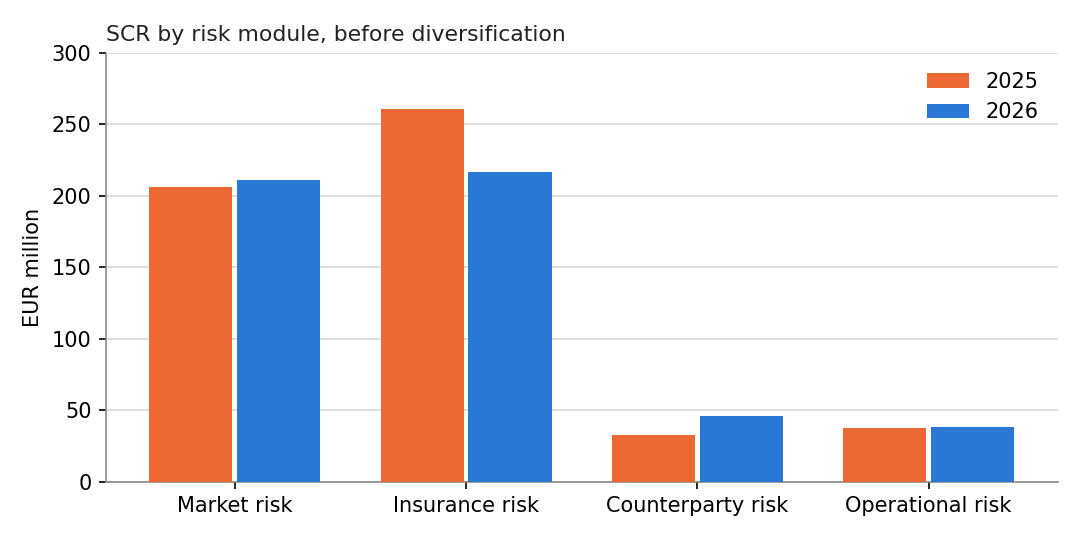

[PASS] A re-render from facts.json on this machine (matplotlib 3.10.0) is identical, pixel for pixel, to the chart in the document.


In [12]:
display(Image(filename=str(BUILD_DIR / "chart_scr_modules.png"), width=620))

# The provenance check D-CHART compares a chart with the reference render made in the build and shipped in the
# bundle. Re-rendering it here shows whether this machine's matplotlib reproduces it pixel for pixel.
rerender = LOCAL_DIR / "chart_rerender_here.png"
core.draw_chart(FACTS, rerender)  # draw_chart() switches matplotlib to its file backend; the next line switches it back
%matplotlib inline
same, n_pixels = core.chart_pixels_equal(BUILD_DIR / "chart_scr_modules.png", rerender)
if same:
    print(f"[PASS] A re-render from facts.json on this machine (matplotlib {matplotlib.__version__}) is identical, "
          "pixel for pixel, to the chart in the document.")
else:
    print(f"[ATTENTION] A re-render on this machine (matplotlib {matplotlib.__version__}) differs in {n_pixels:,} pixels "
          "from the chart in the document.")
    print("            Fonts and library versions change pixels; D-CHART therefore compares with the reference render")
    print("            shipped in the bundle, not with a render made here.")

### 3.6 The five-page cap

Art. 292(5) caps the part at five pages and defines no page. The notebook declares a house format — A4, Arial 11 pt, line height 1.35, margins of 2 cm — and estimates the length in lines: every paragraph takes ceil(characters / 98) lines plus 0.6 of a line for the gap after it, a heading 2 to 3 lines, a table row 1.25 lines and the figure 22 lines. It warns above 4.5 pages and fails above 5.0. **It is an estimate, not a typeset count**: section 5.6 compares it with the pages that a browser printed, and shows the post-hoc change to the lines per page that came out of that comparison.

In [13]:
GOLD_MD = (BUILD_DIR / "gold.md").read_text(encoding="utf-8")
estimate = core.estimate_pages(GOLD_MD)
print(f"Gold document: {estimate['lines']} lines -> {estimate['pages']} pages ({estimate['note']}); status {estimate['status']}")
print(f"  lines by kind : {estimate['detail']}")
print(f"  rule          : {estimate['rule']}")

Gold document: 148.0 lines -> 2.79 pages (estimate, not a typeset count); status pass


  lines by kind : {'paragraph': 93.8, 'heading': 23.5, 'table': 8.8, 'figure': 22.0}
  rule          : ceil(chars/98) lines per paragraph + 0.6 gap; headings {'#': 3.0, '##': 2.5, '###': 2.0}; table rows 1.25; figure 22 lines; 53 lines per page (A4, Arial 11 pt, line height 1.35, margins 2.0 cm)


---

## 4 Drafting: code owns every number

### Why it matters for actuaries

Case Study 4 showed this pattern on an analysis report: the model writes the sentences, and every number is a placeholder that code fills in from the figures the actuary signed. Here it meets a regulated document. The model never types a digit — not an amount, not a ratio, not a year — so a figure in the report cannot be mistyped, though it can still be bound to the wrong sentence. The rule against quantities in words ("doubled", "a third") is only partly enforced: the drafting gate and `D-TIE` recognise a short list of such words and only warn about them, and a word outside the list, such as "a fifth", passes both unnoticed. Code also inserts every text that is fixed: the headings of Annex XX, the language notice, the prescribed definition, the key-figures table, the chart and the statement on sustainability plans. What is left for the model is what it does well: turning figures and bullets into plain sentences.

### 4.1 The prompt and the slots

The model writes seven text slots, one per group of elements of Art. 292; everything around them is assembled by code. Its input is the list of slots with the element each must cover, a catalogue of the placeholders it may use (53 facts, each with its rendered value, its meaning and its period), the text facts about the insurer and the six driver bullets. The instructions are printed in full, with the first lines of the catalogue. The briefs of the first slot and of the compliance slot cite Art. 292(2)(d) and 292(3)(c), but the explicit statements they ask for — no group, both requirements met — are house elements (3.1).

In [14]:
print(dr.DRAFT_PROMPT)
print()
print("SLOTS, and the elements each must cover:")
for slot, brief in dr.SLOT_BRIEF.items():
    print(f"  {slot:<15} {brief[:100]}{'...' if len(brief) > 100 else ''}")
catalogue = dr.catalogue(FACTS).splitlines()
print(f"\nFACTS CATALOGUE: {len(catalogue)} placeholders, for example")
for line in catalogue[:6] + catalogue[-6:-3]:
    print(f"  {line}")
user_message = dr.user_message(FACTS, DRIVERS_MD)
print(f"\nThe whole request: {len(dr.DRAFT_PROMPT):,} characters of instructions and {len(user_message):,} characters of input.")

You draft the part of a Solvency and Financial Condition Report (SFCR) that is written for policy
holders and beneficiaries, for the insurer described in the facts. You write only the text slots listed below.
Code inserts everything else: the headings, the language notice, the legal definition of the SCR and MCR (a
prescribed text), Table 1 with the capital figures, Figure 1, and the statement on sustainability plans.

Rules (code checks each one; a draft that breaks one comes back to you):
1. NUMBERS. Every number, year and date is a placeholder {{ID}} copied exactly from the facts catalogue. Code
   replaces it by the value WITH its unit: {{scr_cur}} becomes "EUR 373.1 million", {{cov_scr_cur}} becomes "220%",
   {{cov_scr_change_pp}} becomes "16 percentage points", {{year_cur}} becomes the year. So never type a digit, and
   never write a unit, a currency, "%", "per cent" or "million" next to a placeholder. Do not use number words either
   ("two", "doubled", "a third").
2. CHANGES.

Rule 1 is the heart of it: `{{scr_cur}}` becomes "EUR 373.1 million" and `{{cov_scr_change_pp}}` "16 percentage points", unit included, so the model may not write a unit, a currency or "%" next to a placeholder. Rule 2 ties direction words to the direction the catalogue gives, and rule 4 asks for every causal sentence with the bullet that supports it. The drafter's own list of causal claims is not used as evidence later: section 6 re-extracts the claims from the text, because a generator that grades itself is not a check.

### 4.2 The drafting gate

Before a draft is accepted, code checks the placeholder template — the model's text with the placeholders still in it. The cell runs the gate on a recorded draft into which four mistakes have been put by hand: an invented placeholder, a typed figure, a unit next to a placeholder and an abbreviation used before the prescribed text defines it. This is what the model would get back as feedback, once, before its draft is rejected.

In [15]:
flawed = dict(RECORDINGS["drafts"]["runs"][0]["draft"])
flawed["capital"] = (flawed["capital"].replace("our SCR was {{scr_cur}}", "our SCR was {{scr_current}}", 1)
                     .replace("The SCR coverage ratio was {{cov_scr_cur}}", "The SCR coverage ratio was 220%", 1))
flawed["performance"] = (flawed["performance"]
                         .replace("Investment income was {{invest_income_cur}}", "Investment income was EUR {{invest_income_cur}}", 1)
                         + " The SCR fell over the year.")
gate = dr.drafting_gate(flawed, FACTS)
print(f"Drafting gate: {'passed' if gate['passed'] else 'rejected'}, {len(gate['errors'])} errors, "
      f"{gate['placeholders']} placeholders")
for error in gate["errors"]:
    print(f"  - {error}")

Drafting gate: rejected, 4 errors, 69 placeholders
  - performance: unit next to a placeholder in 'prev}}. Investment income was EUR {{invest_inc'; code renders the unit, remove it
  - performance: abbreviation 'SCR' before the prescribed text defines it; write it in full
  - capital: unknown placeholder {{scr_current}}; did you mean {{scr_cur}}, {{mcr_cur}}?
  - capital: digit(s) ['220%'] outside a placeholder in 'The SCR coverage ratio was 220% and the MCR coverage ratio was  .'; use a placeholder or rephrase


Each message says what is wrong and, where it can, what to write instead: "did you mean `{{scr_cur}}`?" is the hint that lets a model repair an invented identifier in one round. The three drafts recorded for this case study all passed at the first attempt (4.4), but the revision round stays in the code: a gate that can reject a draft needs a way back.

### 4.3 One draft, live

`run_draft()` sends the request to GPT-6 Luna with the draft schema as a strict JSON schema, runs the drafting gate on the answer and, if the gate rejects it, sends the errors back once for a corrected draft. Code then assembles the template — headings, notice, links, prescribed text, table, chart, plans statement around the seven slots — and renders every placeholder. Without a key the cell shows the first of the three drafts recorded on 23 September 2026, which became the "fresh" document of the case study.

In [16]:
llm.configure(purpose="draft (section 4)")
DRAFT_SOURCE = "recorded draft 1 of 23 September 2026"
draft_run = None
if LIVE_DRAFT and can_call(LUNA):
    draft_run = dr.run_draft(FACTS, DRIVERS_MD, run_id="notebook_draft")
    if draft_run["passed"]:
        DRAFT_SOURCE = "live"
    else:
        last = draft_run["attempts"][-1]
        print(f"[ATTENTION] The live draft did not pass ({last.get('error') or '; '.join(last.get('gate', {}).get('errors', [])[:2])}).")
        print("            The sections below use the recorded draft instead.")
elif LIVE_DRAFT:
    print("[ATTENTION] No key (or no credit): this cell shows the recorded draft instead of a live one.")
if DRAFT_SOURCE != "live":
    draft_run = RECORDINGS["drafts"]["runs"][0]

print("THE REQUEST")
print(f"  model        : {LUNA}, options {sampling_options(EFFORT[LUNA])}, store=False, max_output_tokens 6000")
print(f"  instructions : dr.DRAFT_PROMPT, {len(dr.DRAFT_PROMPT):,} characters")
print(f"  input        : slots, catalogue, text facts and bullets, {len(user_message):,} characters")
print(f"  text.format  : strict JSON schema '{dr.DRAFT_SCHEMA['name']}': 7 slots and a list of causal claims")
recorded_fp = RECORDINGS["drafts"]["runs"][0]["prompt_fingerprint"]
print(("[PASS] " if draft_run["prompt_fingerprint"] == recorded_fp else "[ATTENTION] ")
      + f"Fingerprint {draft_run['prompt_fingerprint'][:12]}: prompt, schema and settings "
      + ("are those of the three recorded drafts." if draft_run["prompt_fingerprint"] == recorded_fp else "differ from the recorded drafts."))
print()
print(f"THE ANSWER ({DRAFT_SOURCE})")
for attempt in draft_run["attempts"]:
    row = attempt.get("row") or {}
    verdict = ("passed" if attempt["gate"]["passed"] else f"rejected: {attempt['gate']['errors'][:2]}") if attempt.get("gate") \
        else f"no draft ({attempt.get('error')})"
    print(f"  attempt {attempt['attempt']}: drafting gate {verdict}")
    if row:
        print(f"  Tokens : {row['input_tokens']:,} in ({row['cached_tokens']:,} cached, {row['cache_write_tokens']:,} written "
              f"to the cache), {row['output_tokens']:,} out ({row['reasoning_tokens']} of them reasoning)")
        print(f"  Cost   : USD {row['usd']:.6f}   Time: {attempt['seconds']:.1f} seconds")

DRAFT = draft_run["draft"]
DRAFT_TEMPLATE = core.assemble_template(DRAFT, FACTS, SPEC, "en")
DRAFT_MD = core.render_document(DRAFT_TEMPLATE, FACTS, "en")
draft_words = sum(len(core.PLACEHOLDER.sub("X", DRAFT[s]).split()) for s in core.SLOTS)
draft_placeholders = sum(len(core.PLACEHOLDER.findall(DRAFT[s])) for s in core.SLOTS)
DRAFT_PAGES = core.estimate_pages(DRAFT_MD)
print()
print(f"Slots  : {draft_words} words and {draft_placeholders} placeholders; {len(DRAFT['causal_claims'])} causal "
      f"claim(s) declared by the drafter")
print(f"Length : {DRAFT_PAGES['pages']} pages ({DRAFT_PAGES['note']}); whole run {draft_run['n_calls']} call(s), "
      f"USD {draft_run['usd']:.6f}, {draft_run['seconds']:.1f} seconds")

THE REQUEST
  model        : gpt-6-luna, options {'reasoning': {'effort': 'none'}, 'temperature': 0}, store=False, max_output_tokens 6000
  instructions : dr.DRAFT_PROMPT, 2,798 characters
  input        : slots, catalogue, text facts and bullets, 11,644 characters
  text.format  : strict JSON schema 'policyholder_part_draft': 7 slots and a list of causal claims
[PASS] Fingerprint a6290759228d: prompt, schema and settings are those of the three recorded drafts.

THE ANSWER (live)
  attempt 1: drafting gate passed
  Tokens : 3,687 in (0 cached, 3,684 written to the cache), 1,173 out (0 of them reasoning)
  Cost   : USD 0.001047   Time: 13.4 seconds

Slots  : 612 words and 75 placeholders; 3 causal claim(s) declared by the drafter
Length : 2.62 pages (estimate, not a typeset count); whole run 1 call(s), USD 0.001047, 13.4 seconds


In the saved run the draft passed the drafting gate at the first attempt: 612 words in the slots with 75 placeholders, an estimated 2.62 pages, USD 0.0010 and 13.4 seconds. Here is the whole document as code rendered it, with the chart replaced by a note (it is shown in section 3.5). Read it as a policyholder would, and then as the actuary who has to sign it.

In [17]:
def show_document(md: str) -> None:
    """Display a rendered document as formatted text, the chart replaced by a note."""
    display(Markdown(re.sub(r"!\[([^\]]*)\]\([^)]*\)", r"*[\1: the chart of section 3.5]*", md)))


show_document(DRAFT_MD)

# Brisendale Mutual: Solvency and Financial Condition Report 2026

## Part for policy holders and beneficiaries (dry run of the new format)

## A. Languages in which this part is available

You have the right to ask for a version of this part in the official language of the EU Member State where you live, if we operate in that Member State through the right of establishment or the freedom to provide services. We do so in Lithuania. To ask for a version, write to sfcr-requests@brisendale-mutual.example.

This part is available online in English: https://www.brisendale-mutual.example/sfcr/policyholders/en

## B. Business and Performance

Brisendale Mutual is a mutual insurance undertaking owned by its policyholder members; it has no shareholders. We are based in Ireland and sell motor and home insurance. We also sell home insurance to people living in Lithuania under the freedom to provide services, without a branch there.

Our supervisory authority is the Home Supervisory Authority (fictitious placeholder). It can be contacted at enquiries@home-authority.example or https://www.home-authority.example. There are no qualifying holdings because, as a mutual, Brisendale Mutual has no shareholders. Brisendale Mutual does not belong to a group.

From the start of 2026, a new quota-share reinsurance contract has passed a fixed share of the premiums and claims of every motor policy to reinsurers. This changes the risks we retain and increases the amounts owed by reinsurers. In October 2026, a windstorm caused many home insurance claims, mainly for roof and fence damage.

In 2025, we began selling home insurance in Lithuania under the freedom to provide services.

Our gross written premiums increased by 4.5% to EUR 1,158.7 million in 2026, compared with EUR 1,108.9 million in 2025. Motor premiums were EUR 676.6 million in 2026 (2025: EUR 641.4 million), while home premiums were EUR 482.1 million (2025: EUR 467.5 million).

Net earned premiums were EUR 976.5 million in 2026, compared with EUR 1,012.2 million in 2025. Net claims incurred increased by 4.1% to EUR 683.0 million (2025: EUR 655.9 million). Operating expenses increased by 2.2% to EUR 271.3 million (2025: EUR 265.5 million); the reasons for the increase have not yet been analysed.

Our net combined ratio increased by 6.7 percentage points to 97.7% in 2026, from 91.0% in 2025. The underwriting result was EUR 22.2 million in 2026, compared with EUR 90.8 million in 2025.

Investment income was EUR 86.0 million in 2026, compared with EUR 54.7 million in 2025. The investment return increased by 1.2 percentage points to 3.5% in 2026, from 2.3% in 2025.

## C. Capital Management and Risk Profile

### What the capital requirements mean

> “Two capital requirements aim at measuring the financial soundness of the undertaking: the Solvency Capital Requirement (SCR) and the Minimum Capital Requirement (MCR). The SCR should deliver a level of capital that enables an undertaking to absorb significant unforeseen losses over a one-year time horizon and should give reasonable assurance to policy holders that payments will be made as they fall due. The MCR is intended to provide a minimum level of security to be held at all times by the undertaking and below which the amount of financial resources (own funds) should not fall.
>
> The capital requirements will need to be covered by capital (own funds) of sufficient quality to ensure that losses can be covered on a going-concern basis as well as in the event of winding-up”.

### Our capital position

At 31 December 2026, our SCR was EUR 373.1 million, compared with EUR 382.7 million at 31 December 2025. It decreased by 2.5%. Eligible own funds to cover the SCR were EUR 820.6 million at 31 December 2026, up by 5.4% from EUR 778.9 million at 31 December 2025. The SCR coverage ratio increased by 16 percentage points, from 204% at 31 December 2025 to 220% at 31 December 2026.

At 31 December 2026, our MCR was EUR 108.7 million, compared with EUR 118.6 million at 31 December 2025. Eligible own funds to cover the MCR were EUR 769.9 million at 31 December 2026, compared with EUR 723.9 million at 31 December 2025. The MCR coverage ratio increased by 98 percentage points, from 610% at 31 December 2025 to 708% at 31 December 2026. Table 1 presents these figures.

*Table 1: Capital requirements, eligible own funds and coverage ratios*

|  | 31 December 2026 | 31 December 2025 |
|---|---:|---:|
| Solvency Capital Requirement (SCR) | EUR 373.1 million | EUR 382.7 million |
| Minimum Capital Requirement (MCR) | EUR 108.7 million | EUR 118.6 million |
| Eligible own funds to cover the SCR | EUR 820.6 million | EUR 778.9 million |
| SCR coverage ratio | 220% | 204% |
| Eligible own funds to cover the MCR | EUR 769.9 million | EUR 723.9 million |
| MCR coverage ratio | 708% | 610% |

### Compliance with the capital requirements

Brisendale Mutual met its SCR and MCR throughout 2026 and at the time of disclosure.

### Our material risks

Our material risks include insurance risk: claims from motor and home policies may be higher than expected, for example after storms. Market risk arises because the value of investments, mainly bonds, can fall when interest rates or credit spreads rise. Counterparty risk is the risk that a reinsurer or bank does not pay what it owes. Operational risk includes losses from failed processes, systems or people, including cyber incidents.

Sustainability risks include physical risks, as climate change can make storms and floods more frequent and severe, and transition risks, as investments may lose value in the move to a low-carbon economy. During 2026, insurance risk fell because the new motor quota share passes part of the motor risk to reinsurers. Counterparty risk rose because more is now owed by reinsurers under the quota share.

We mitigate insurance risk through the motor quota share, catastrophe cover that limits losses from a single storm, underwriting limits and claims controls. We manage investment risk through a policy focused mainly on high-quality bonds spread across many issuers, and an exclusion of companies that earn most of their revenue from thermal coal. We also use business continuity and cyber security controls. Figure 1 shows the SCR by risk module.

*[Figure 1: Solvency Capital Requirement by risk module, before diversification: the chart of section 3.5]*

*Figure 1: Solvency Capital Requirement by risk module, before diversification, at the end of 2026 and 2025 (EUR million).*

## D. Other information

Policyholders who wish to complain can contact us at complaints@brisendale-mutual.example. They may also contact the supervisory authority.

Brisendale Mutual discloses the plans referred to in Article 19a of Directive 2013/34/EU. You can find them at https://www.brisendale-mutual.example/sustainability/plans

---

*Brisendale Mutual is a fictitious insurer created for teaching; all figures are synthetic.*


### 4.4 Three recorded drafts: how much they vary

The same request was sent three times on 23 September 2026, at temperature 0. The table compares the three drafts; the second shows how similar each pair of drafts is, measured by `difflib` on the text of the slots (1 would be identical).

In [18]:
recorded_drafts = RECORDINGS["drafts"]["runs"]
display(pd.DataFrame([{
    "draft": i, "passed at attempt": len(r["attempts"]), "USD": r["usd"], "seconds": r["seconds"],
    "words in slots": r["words_slots"], "placeholders": r["placeholders"],
    "causal claims declared": len(r["draft"]["causal_claims"]),
    "pages (50 lines, recorded)": r["page_estimate"]["pages"],
    "pages (rules in force)": core.estimate_pages(r["rendered"])["pages"]}
    for i, r in enumerate(recorded_drafts, start=1)]).set_index("draft"))
display(pd.DataFrame([{"pair": pair.replace("v", " and "), "text similarity": v["similarity"],
                       "identical slots": ", ".join(v["identical_slots"]) or "none",
                       "same placeholders": v["placeholder_sets_equal"]}
                      for pair, v in RECORDINGS["drafts"]["variation"].items()]).set_index("pair"))

,passed at attempt,USD,seconds,words in slots,placeholders,causal claims declared,"pages (50 lines, recorded)",pages (rules in force)
draft,,,,,,,,
1,1,0.000608,9.82,637,70,2,2.80,2.64
2,1,0.000670,10.85,639,79,6,2.82,2.66
3,1,0.000707,10.98,685,78,6,2.94,2.77


,text similarity,identical slots,same placeholders
pair,,,
1 and 2,0.311,none,True
1 and 3,0.284,compliance,True
2 and 3,0.636,none,True


**Temperature 0 does not give the same text twice.** The three drafts use the same set of placeholders, but not the same wording: the text similarity of pairs is 0.311, 0.284 and 0.636, and only one slot, the one-sentence compliance statement, is identical in two drafts. They also differ in what they claim: the first draft declared 2 causal sentences, the other two 6 each. A report drafted twice is two reports, and each has to be checked. Each recorded draft cost less than a tenth of a US cent.

### 4.5 The deterministic gate on the draft

Section 5 introduces the twelve deterministic checks; here they run once on the draft of 4.3, as they would right after drafting. They take a fraction of a second and need no key.

In [19]:
DRAFT_DOC = ch.Doc(DRAFT_MD, FACTS, SPEC, DRIVERS, name="your draft")
draft_det = ch.run_deterministic(DRAFT_DOC)
print(f"Deterministic gate on the draft ({DRAFT_SOURCE}): {len(draft_det['findings'])} finding(s) in "
      f"{draft_det['seconds']:.2f} seconds")
if draft_det["findings"]:
    with pd.option_context("display.max_colwidth", None):
        display(findings_table(draft_det["findings"]))
for name in ("work/draft_run2.md", "work/draft_run3.md"):
    recorded = RECORDINGS["gate"]["deterministic_only"][name]["findings"]
    print(f"Recorded draft {name[-4]}: {len(recorded)} finding(s): "
          + "; ".join(f"{f['check_id']} ({f['message']}): '{f['quote'][:45]}'" for f in recorded))

Deterministic gate on the draft (live): 2 finding(s) in 0.12 seconds


,check,severity,status,where,evidence,message
1,D-PER,info,not_verifiable,C.p1.s2,It decreased by 2.5%.,no metric named before the figure; binding not verifiable
2,D-DIR,warning,not_verifiable,C.p1.s2,It decreased by 2.5%.,'decreased' refers to a pronoun; not verifiable


Recorded draft 2: 3 finding(s): D-PER (no metric named before the figure; binding not verifiable): 'They were EUR 1,158.7 million in 2026, compar'; D-PER (no metric named before the figure; binding not verifiable): 're EUR 1,158.7 million in 2026, compared with'; D-PER (the figure may belong to the other period (weak period label)): 'EUR 641.4 million in 2025; home premiums were'
Recorded draft 3: 3 finding(s): D-PER (no metric named before the figure; binding not verifiable): 'It decreased by 2.5%.'; D-DIR ('increased' refers to a pronoun; not verifiable): '26, compared with EUR 265.5 million in 2025; '; D-DIR ('decreased' refers to a pronoun; not verifiable): 'It decreased by 2.5%.'


The fresh draft of the recordings (draft 1) passes the deterministic gate with no finding; drafts 2 and 3 get three "not verifiable" items each, from `D-PER` and `D-DIR`: figures and direction words after a pronoun ("They were EUR 1,158.7 million…", "It decreased by 2.5%") and figures given with "respectively", which the checks cannot bind to a metric or a period. They say so instead of passing the sentence. In the saved run, the live draft got 2 findings (D-PER 1, D-DIR 1; 0 of them errors, 2 not verifiable); section 6.3 comes back to the errors a fresh draft can get.

### 4.6 From the fresh draft to the gold version

A measurement needs a document known to be right. The **gold** version is the fresh draft (recorded draft 1), read and corrected by the author of the case study, with every correction logged. No error of fact, number, period or direction was found in the fresh draft — the deterministic gate agrees — so the seven corrections are about the reader: five explain terms a policyholder would not know, two add an explanation drawn from the bullets: G7 says only what DR2 says, G5 goes one step beyond DR1 and DR4 (see below).

In [20]:
CORRECTIONS = json.loads((BUILD_DIR / "gold_corrections.json").read_text(encoding="utf-8"))
with pd.option_context("display.max_colwidth", 110):
    display(pd.DataFrame([{"id": c["id"], "reason": c["reason"], "new text": c["new"]}
                          for c in CORRECTIONS["corrections"]]).set_index("id"))
FRESH_MD = (BUILD_DIR / "fresh.md").read_text(encoding="utf-8")
print(f"Corrected by: {CORRECTIONS['corrected_by']}. Fresh draft {len(FRESH_MD.split())} words, gold "
      f"{len(GOLD_MD.split())} words; gold sha256 {CORRECTIONS['gold_sha256'][:12]}... "
      f"({'matches' if hashlib.sha256(GOLD_MD.encode('utf-8')).hexdigest() == CORRECTIONS['gold_sha256'] else 'DOES NOT match'} the file).")

,reason,new text
id,,
G1,plain language: explain 'qualifying holding'; state the reason without a causal marker,"As a mutual, Brisendale Mutual has no shareholders, so no one holds a qualifying holding (a large holding ..."
G2,plain language: explain the quota share in everyday words,"From the start of {{year_cur}}, a new reinsurance contract for motor insurance (a quota share) passes a fi..."
G3,plain language: explain gross written premiums,"Gross written premiums are the premiums for the policies we sold, before any share passed to reinsurers. G..."
G4,plain language: explain net earned premiums and net claims incurred,"Net earned premiums are the premiums for the cover we provided during the year, after the share passed to ..."
G5,missing explanation: why claims rose (causes from DR1 and DR4; the effect on net claims is an inference),to {{claims_net_cur}} in {{year_cur}}. Net claims incurred rose because motor repair costs went up and the...
G6,plain language: explain the combined ratio and the underwriting result,"The net combined ratio compares claims and expenses with net earned premiums; the lower it is, the more of..."
G7,missing explanation: what changed the SCR (stated as DR2 states it; the link to the SCR total is not in th...,The new motor reinsurance contract reduced the insurance risk we keep (see Figure 1). Table 1 presents the...


Corrected by: author of the case study. Fresh draft 1122 words, gold 1264 words; gold sha256 865233589885... (matches the file).


The gold version is the **clean control** of section 7: every finding on it is either a false alarm or something the reviewer accepts. Its corrections are one person's reading, logged so that anyone can check them; if they changed, the gold and planted documents would change with them, and the recorded runs of section 7 would have to be made again. G5 is worth a note: "Net claims incurred rose because motor repair costs went up and the October windstorm caused many home insurance claims" combines two bullets into a cause the bullets do not state for net claims. Section 8 comes back to such sentences.

---

## 5 Deterministic checks

### Why it matters for actuaries

Most of what can go wrong in this document can be checked without a language model: a figure that is not in the facts, a ratio that does not follow from its inputs, a year in the wrong place, a legal text that is not word for word the official one, a notice that is not at the start, a missing element. Such checks are free, instant, identical on every run and explainable line by line — the properties an actuarial control needs. They come first; the LLM checks of section 6 only get what code cannot decide.

### 5.1 The twelve checks

Each check sees only what an external reviewer sees: the rendered document, `facts.json`, the driver bullets and `spec.json`. None of them sees the placeholder template or the list of planted errors — a check that compared the document with its template would flag every edit and measure nothing. Every finding carries a severity (error, warning, information) and a status: *fail*, or *not verifiable* when the check cannot decide. The table also lists a thirteenth check, `D-PP` (marked "no: exercise (b)"). It is not one of the twelve and not part of the default gate; exercise (b) is about it.

In [21]:
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame([{"check": cid, "what it checks": c["title"], "languages": ", ".join(c["langs"]),
                           "in the default gate": "yes" if c["default"] else "no: exercise (b)"}
                          for cid, c in ch.CHECKS.items() if c["kind"] == "deterministic"]).set_index("check"))

,what it checks,languages,in the default gate
check,,,
D-NOTICE,Language notice at the start (Art. 292(1)),"en, lt",yes
D-LINKS,Links: language versions at the beginning; only .example domains,"en, lt",yes
D-TEXT,Prescribed SCR/MCR text verbatim (Art. 292(3)),"en, lt",yes
D-TIE,Every number traces to facts.json at printed precision,"en, lt",yes
D-PER,Figures bound to the right metric and period (table and prose),"en, lt",yes
D-ID,"Ratios, totals and changes recomputed from printed figures","en, lt",yes
D-DIR,Direction words match the sign of the change,en,yes
D-PP,'%' vs 'percentage points' for changes of ratios (exercise b),en,no: exercise (b)
D-JARGON,Technical Solvency II terms in policyholder text (list),en,yes


### 5.2 Tolerance from the printed precision

How close must a printed figure be to the fact? A tuned constant invites trouble: a relative tolerance of 0.5% lets a printed 175% pass for anything from 174.1% to 175.9%. Here the tolerance is the precision of the figure as printed — a figure printed with one decimal must equal the fact rounded to one decimal — and a ratio recomputed from printed inputs gets an interval: each input may be off by half a unit of its last digit, and the printed ratio must fall inside the range that results.

In [22]:
print(inspect.getsource(core.matches_at_printed_precision))
print(inspect.getsource(core.interval_ratio))
for label, (num, den, printed) in {
        "SCR coverage 2026: EUR 820.6 m / EUR 373.1 m": ((820.6, 1), (373.1, 1), 220),
        "warm-up expense ratio: EUR 140 m / EUR 700 m": ((140, 0), (700, 0), 28)}.items():
    low, high = core.interval_ratio(num[0], num[1], den[0], den[1])
    inside = low - 0.5 <= printed <= high + 0.5
    print(f"{label}: between {low:.2f}% and {high:.2f}%; printed {printed}% -> "
          f"{'consistent' if inside else 'does not follow from its inputs'}")

def matches_at_printed_precision(printed: float, dp: int, fact_value: float) -> bool:
    """The tolerance rule: printed passes if |printed - round(fact, dp)| <= 0.5 * 10^-dp."""
    # Both sides carry dp decimals, so the rule amounts to equality at printed precision (float-safe).
    return abs(abs(printed) - round(abs(fact_value), dp)) < 0.5 * 10 ** (-dp)

def interval_ratio(num: float, num_dp: int, den: float, den_dp: int) -> tuple[float, float]:
    """Ratio (in %) of two printed values, each +/- half a unit of its last printed digit."""
    hn, hd = 0.5 * 10 ** (-num_dp), 0.5 * 10 ** (-den_dp)
    return 100 * (num - hn) / (den + hd), 100 * (num + hn) / (den - hd)

SCR coverage 2026: EUR 820.6 m / EUR 373.1 m: between 219.90% and 219.98%; printed 220% -> consistent
warm-up expense ratio: EUR 140 m / EUR 700 m: between 19.91% and 20.09%; printed 28% -> does not follow from its inputs


### 5.3 How a direction word is checked

"The SCR increased by 2.5%" is wrong if the SCR fell, and a check has to know which figure a verb talks about. `D-DIR` counts only verbs as direction words, binds each to the nearest figure named before it in the same clause, maps "improved" and "deteriorated" through whether more of the figure is better, and binds a transitive verb ("reduced the insurance risk") to its object. Where it cannot bind — a pronoun, a negation — it reports the sentence as not verifiable rather than passing it. `mini_doc()` puts single sentences into a small document so that a check can be tried on them; exercise (b) uses it too.

In [23]:
def mini_doc(*sentences: str, section: str = "C") -> ch.Doc:
    """A small document with one paragraph per sentence in one section, for trying a check on single sentences."""
    heading = next(f"## {s['id']}. {s['title_en']}" for s in SPEC["structure"] if s["id"] == section)
    return ch.Doc(heading + "\n\n" + "\n\n".join(sentences) + "\n", FACTS, SPEC, DRIVERS, name="mini document")


DIRECTION_EXAMPLES = [
    "The SCR decreased by 2.5% between 2025 and 2026.",
    "The SCR increased by 2.5% between 2025 and 2026.",
    "The net combined ratio improved by 6.7 percentage points.",
    "The new motor reinsurance contract reduced the insurance risk we keep.",
    "It decreased by 2.5% over the year.",
    "The SCR has not increased since 2025.",
]
direction_findings = {f.sid: f for f in ch.d_dir(mini_doc(*DIRECTION_EXAMPLES))}
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame([{"sentence": s,
                           "D-DIR": (lambda f: f"{f.severity}, {f.status}: {f.message}" if f else "pass")(
                               direction_findings.get(f"C.p{i}.s1"))}
                          for i, s in enumerate(DIRECTION_EXAMPLES, start=1)]))

,sentence,D-DIR
0,The SCR decreased by 2.5% between 2025 and 2026.,pass
1,The SCR increased by 2.5% between 2025 and 2026.,"error, fail: direction word 'increased' contradicts the change in Solvency Capital Requirement (SCR)"
2,The net combined ratio improved by 6.7 percentage points.,"error, fail: direction word 'improved' contradicts the change in combined ratio (net)"
3,The new motor reinsurance contract reduced the insurance risk we keep.,pass
4,It decreased by 2.5% over the year.,"warning, not_verifiable: 'decreased' refers to a pronoun; not verifiable"
5,The SCR has not increased since 2025.,"warning, not_verifiable: negated direction word 'increased'; not verifiable"


The combined ratio rose from 91.0% to 97.7%, and for a combined ratio lower is better — so "improved" is wrong, and the check says so although the sentence contains no "fell". "Reduced the insurance risk" is bound to its object and agrees with the facts. The pronoun and the negation are not guessed at: they come back as not verifiable, for a person to read.

### 5.4 Gold, planted and fresh through the deterministic gate

The gate runs live on three documents: the gold version, the planted version (gold plus the 16 errors of section 7) and the fresh draft. It is free and fast, so the cell also compares every finding with the recording made on 23 September 2026.

In [24]:
PLANTED_MD = (BUILD_DIR / "planted.md").read_text(encoding="utf-8")
DOCS = {"gold": ch.Doc(GOLD_MD, FACTS, SPEC, DRIVERS, name="gold.md"),
        "planted": ch.Doc(PLANTED_MD, FACTS, SPEC, DRIVERS, name="planted.md"),
        "fresh": ch.Doc(FRESH_MD, FACTS, SPEC, DRIVERS, name="fresh.md")}
DET = {name: ch.run_deterministic(doc) for name, doc in DOCS.items()}
for name, result in DET.items():
    recorded = RECORDINGS["gate"]["deterministic_only"][f"{name}.md"]["findings"]
    same = [(f["check_id"], f["sid"], f["message"]) for f in result["findings"]] == \
           [(f["check_id"], f["sid"], f["message"]) for f in recorded]
    errors = sum(f["severity"] == "error" for f in result["findings"])
    print(f"{'[PASS]' if same else '[ATTENTION]'} {name:<8}: {len(result['findings']):>2} findings ({errors} errors) in "
          f"{result['seconds']:.2f} seconds - {'identical to' if same else 'different from'} the recording")
with pd.option_context("display.max_colwidth", None):
    display(findings_table(DET["planted"]["findings"], width=60))

[PASS] gold    :  0 findings (0 errors) in 0.11 seconds - identical to the recording
[PASS] planted : 14 findings (14 errors) in 0.14 seconds - identical to the recording
[PASS] fresh   :  0 findings (0 errors) in 0.10 seconds - identical to the recording


,check,severity,status,where,evidence,message
1,D-NOTICE,error,fail,A.p1.s1,This part is available online in English: https://www.brisen,the part does not start with the language notice (Art. 292(1))
2,D-TEXT,error,fail,C.q1.s2,should -> shall,prescribed text differs from the official wording
3,D-TIE,error,fail,B.p5.s3,Motor premiums were EUR 676.5 million in 2026 (2025: EUR 641,number does not trace to facts.json at its printed precision
4,D-TIE,error,fail,C.p2.s5,The SCR coverage ratio increased by 16% and the MCR coverage,number does not trace to facts.json at its printed precision
5,D-TIE,error,fail,C.t1.r4,SCR coverage ratio | 212% | 204%,number does not trace to facts.json at its printed precision
6,D-PER,error,fail,C.t1.r4,SCR coverage ratio | 212%,table cell differs from facts.json
7,D-PER,error,fail,C.p2.s1,"At 31 December 2025, the SCR was EUR 373.1 million and the M",figure is the current-period value of Solvency Capital Requirement (SCR) (period
8,D-ID,error,fail,C.p2.s1,"scr prev: 382.7, 373.1",the same figure is printed with different values in the document
9,D-ID,error,fail,C.p1.s3,"cov_scr cur: 212.0, 220.0",the same figure is printed with different values in the document
10,D-ID,error,fail,C.t1.r4,cov_scr cur = 212.0,coverage ratio does not equal eof_scr / scr of the same period


**The gold and fresh documents get no finding; the planted one gets 14, all errors.** Several point at the same planted error from different sides: the coverage ratio changed in the table (212% for 220%) is untraceable (`D-TIE`), differs from the fact in its column (`D-PER`), contradicts the 220% printed in the prose and does not follow from own funds over SCR (`D-ID`). The finding "The SCR coverage ratio increased by 16%" reports a number that does not trace to the facts — the right sentence, but the wrong diagnosis, as section 7.5 explains. Section 7 scores all findings against the 16 planted errors.

### 5.5 The mutant sweep: does the gate have teeth?

Sixteen planted errors are sixteen data points. A free way to get more is the mutant idea of Case Study 4: eleven operators, each written from an error category (not from a planted instance), put one error at a random eligible place of the gold document — swap two periods, flip a direction word, write "%" for "percentage points", drop an element, change a last digit, scale a figure by 1.1, paraphrase one word of the prescribed text, delete or move the notice, insert jargon, break a cross-reference, change a coverage ratio in the table. Twenty variants per operator, 220 documents, each through the deterministic gate; a mutant counts as detected if the gate reports anything the gold document does not get. With `RUN_MUTANTS_LIVE = False` the cell shows the recorded sweep.

In [25]:
if RUN_MUTANTS_LIVE:
    started = time.perf_counter()
    MUTANTS = mu.sweep(GOLD_MD, FACTS, SPEC, DRIVERS, n=20, seed=7)
    mutant_seconds = time.perf_counter() - started
    print(f"220 one-error documents through the gate in {mutant_seconds:.0f} seconds (seed 7, as recorded).")
else:
    MUTANTS = RECORDINGS["gate"]["mutants"]
    print("Recorded sweep of 23 September 2026 (RUN_MUTANTS_LIVE is False).")
recorded_mutants = RECORDINGS["gate"]["mutants"]
display(pd.DataFrame([{"operator": name, "detected": f"{m['detected']}/{m['n']}",
                       "as an error": f"{m['detected_as_error']}/{m['n']}",
                       "checks that fired": ", ".join(f"{c} {k}" for c, k in sorted(m["by_check"].items(), key=lambda x: -x[1])),
                       "recorded": f"{recorded_mutants[name]['detected']}/{recorded_mutants[name]['n']}"}
                      for name, m in MUTANTS.items()]).set_index("operator"))
MUTANTS_DETECTED = sum(m["detected"] for m in MUTANTS.values())
MUTANTS_N = sum(m["n"] for m in MUTANTS.values())
print(f"Detected: {MUTANTS_DETECTED} of {MUTANTS_N}. Missed:")
for name in ("flip_direction_word", "insert_jargon"):
    for miss in MUTANTS[name]["missed"]:
        print(f"  {name:<20} {miss['sid']:<9} {miss['what']}")

220 one-error documents through the gate in 29 seconds (seed 7, as recorded).


,detected,as an error,checks that fired,recorded
operator,,,,
swap_periods,20/20,20/20,"D-PER 20, D-ID 19",20/20
flip_direction_word,15/20,15/20,D-DIR 15,15/20
pp_to_percent,20/20,20/20,"D-TIE 14, D-PER 6",20/20
drop_element,20/20,20/20,D-SPEC 20,20/20
perturb_last_digit,20/20,20/20,"D-TIE 20, D-ID 11, D-PER 3",20/20
scale_x1_1,20/20,20/20,"D-TIE 20, D-ID 16, D-PER 7",20/20
paraphrase_one_word,20/20,20/20,D-TEXT 20,20/20
delete_or_move_notice,20/20,20/20,D-NOTICE 20,20/20
insert_jargon,19/20,19/20,D-JARGON 19,19/20


Detected: 214 of 220. Missed:
  flip_direction_word  B.p3.s2   increases
  flip_direction_word  C.p5.s1   higher
  flip_direction_word  B.p7.s1   lower
  flip_direction_word  B.p7.s1   lower
  flip_direction_word  C.p5.s1   higher
  insert_jargon        B.p7.s3   premium provisions


**214 of 220 one-error documents are detected** — and the misses say where the gate's scope ends. The flipped direction words it misses are adjectives ("higher", "lower") in explanatory sentences and a verb whose object is not a figure it knows ("increases the amounts that reinsurers owe us"); `D-DIR` looks at verbs bound to figures only. The jargon it misses is a term that is not on its list ("premium provisions"): a list catches what its author thought of. A mutant sweep is not a proof either — the operators were written by the author of the checks — but it turns "1 of 1" per category into "k of 20".

### 5.6 The five-page cap, against typeset pages

In the build, the gold document with 0 to 10 extra copies of its risk section was printed to A4 PDF by a headless browser in the declared format, and the pages were counted. The table puts the estimate next to the typeset count, with the frozen rule (50 lines per page) and with the post-hoc change PH3 (53 lines per page). The browser count itself cannot be repeated in Colab, so it is read from the recording.

In [26]:
points = RECORDINGS["pages_calibration"]["points"]
display(pd.DataFrame([{"extra copies of the risk section": p["copies"], "lines": p["lines"],
                       "estimate, 50 lines per page (frozen)": round(p["lines"] / 50, 2),
                       "estimate, 53 lines per page (post-hoc)": round(p["lines"] / 53, 2),
                       "typeset pages": p["typeset"]} for p in points]).set_index("extra copies of the risk section"))

# The overflow variant: copies of the risk section are added until the estimate, with the rules in force, exceeds 5.
start, end = GOLD_MD.index("### Our material risks"), GOLD_MD.index("![Figure 1")
risk_block = GOLD_MD[start:end].replace("### Our material risks", "### Our material risks (continued)")
overflow_md, copies = GOLD_MD, 0
while core.estimate_pages(overflow_md)["pages"] <= 5.0:
    overflow_md = overflow_md[:overflow_md.index("![Figure 1")] + risk_block + overflow_md[overflow_md.index("![Figure 1"):]
    copies += 1
OVERFLOW = {"copies": copies, "findings": ch.d_page(ch.Doc(overflow_md, FACTS, SPEC, DRIVERS, name="overflow"))}
typeset = {p["copies"]: p["typeset"] for p in points}
print(f"Overflow variant with the rules in force: {copies} extra copies, estimate "
      f"{core.estimate_pages(overflow_md)['pages']} pages -> D-PAGE {OVERFLOW['findings'][0].severity if OVERFLOW['findings'] else 'passes'}; "
      f"typeset: {typeset.get(copies)} pages.")
print(f"Recorded with the frozen rule: {RECORDINGS['gate']['overflow']['copies_of_risks_block']} extra copies, estimate "
      f"{RECORDINGS['gate']['overflow']['estimate']['pages']} pages -> D-PAGE error; typeset: "
      f"{typeset[RECORDINGS['gate']['overflow']['copies_of_risks_block']]} pages.")
print(f"Typeset pages of the documents: " + ", ".join(f"{k.replace('.html', '')} {v['typeset_pages']} (estimate then "
                                                           f"{v['estimate']})" for k, v in RECORDINGS["pages"].items()))

,lines,"estimate, 50 lines per page (frozen)","estimate, 53 lines per page (post-hoc)",typeset pages
extra copies of the risk section,,,,
0,148.0,2.96,2.79,3
1,166.8,3.34,3.15,4
2,185.6,3.71,3.50,4
3,204.4,4.09,3.86,4
4,223.2,4.46,4.21,5
5,242.0,4.84,4.57,5
6,260.8,5.22,4.92,5
7,279.6,5.59,5.28,6
8,298.4,5.97,5.63,6


Overflow variant with the rules in force: 7 extra copies, estimate 5.28 pages -> D-PAGE error; typeset: 6 pages.
Recorded with the frozen rule: 6 extra copies, estimate 5.22 pages -> D-PAGE error; typeset: 5 pages.
Typeset pages of the documents: gold 3 (estimate then 2.96), fresh 3 (estimate then 2.8), planted 3 (estimate then 2.87), planted_overflow 5 (estimate then 5.22), gold_lt 4 (estimate then 3.31)


**The frozen estimate ran long.** With 50 lines per page it put the variant with 6 extra copies at 5.22 pages — an error — although the browser printed it on 5 pages. With 53 lines per page the same variant is estimated at 4.92 pages, a warning, and the first variant that fails the check, with 7 extra copies, is also the first that the browser prints on 6 pages. That agreement is a fit, not a test: 53 was read off these same eleven variants after the freeze, and it still misses one of them (9 extra copies, estimated at 5.98 pages, printed on 7). The documents printed outside the calibration cannot settle it. The fresh draft and the planted version printed on 3 pages, as both rules predict. The Lithuanian version, estimated at 3.31 pages with the frozen rule and at 3.13 now, printed on 4, which both estimates allow, since anything above three pages needs a fourth sheet; one Lithuanian document cannot show whether a rule calibrated on English text also fits Lithuanian. An estimate is a control, not a measurement: the typeset document is what counts, and a document near the cap has to be typeset before it is signed. Art. 292(5) adds a second sentence that a page check alone cannot see: fitting five pages must not drop an element — which is why `D-SPEC` runs on every document too.

---

## 6 LLM checks and the blind chart read

### Why it matters for actuaries

Some questions need a reader, not a rule: does a stated cause follow from the bullets, is an element covered or only mentioned, would a policyholder understand a term, is a word misspelt, which figure does a sentence talk about when it names none in the words a list would know? A language model can answer such questions, and it can be wrong while sounding certain. Two rules keep it in its place. **The LLM extracts or judges; Python decides**: every quote the model returns must be found, word for word, in the document or the bullets, and a figure it extracts is compared with the facts by code. And **its judgements stay warnings** unless a deterministic check confirms them. A warning is not an error: it goes to the person who signs, with its evidence.

### 6.1 Five text checks and one vision check

| Check | What the model does | What code does with it | Severity |
| --- | --- | --- | --- |
| `L-SUPPORT` | judges each causal sentence against the six bullets | picks the sentences (a scan for "because", "due to", "driven by", "as a result of" …), grounds the quote from the sentence and the quote from the bullet | warning; not verifiable if a quote is not found |
| `L-COVER` | says whether each element of Art. 292 is covered, partly covered or not covered, with a quote | grounds the quote | warning; an error if `D-SPEC` finds the same element missing |
| `L-AUDIENCE` | flags jargon, promotional tone, forecasts and unclear sentences | grounds the quoted words | warning; an error if the term is on the jargon list of `D-JARGON` |
| `L-SPELL` | proofreads to British English, with a list of what not to flag | grounds the quote, drops "corrections" that change nothing | warning |
| `L-EXTRACT` | extracts every figure in the prose as (figure, year, value) | compares each value with `facts.json` at its printed precision | an error if the quote names the figure and the sentence the year; else a warning |
| `L-CHART` | reads every bar of the chart, which has no value labels | compares each bar with `facts.json` against a calibrated threshold, and the ranking of the modules | warning; an error if `D-CHART` confirms |

The cell prints the five text prompts and checks that the prompts, schemas and settings are the ones frozen before the hold-out errors were planted.

In [27]:
TEXT_PROMPTS = {"L-SUPPORT": lc.SUPPORT_PROMPT, "L-COVER": lc.COVER_PROMPT, "L-AUDIENCE": lc.AUDIENCE_PROMPT,
                "L-SPELL": lc.SPELL_PROMPT, "L-EXTRACT": lc.extract_prompt(FACTS)}
for check_id, prompt in TEXT_PROMPTS.items():
    print(f"===== {check_id} ({len(prompt):,} characters)")
    print(prompt.split("METRICS")[0].rstrip() + ("\nMETRICS: the 20 public figures of facts.json, one per line" if "METRICS" in prompt else ""))
    print()
frozen_assets = lc.frozen_assets()
for check_id, frozen_sha in FREEZE["per_llm_check"].items():
    now = hashlib.sha256(json.dumps(frozen_assets[check_id], sort_keys=True, ensure_ascii=False).encode("utf-8")).hexdigest()
    print(f"{'[PASS]' if now == frozen_sha else '[ATTENTION]'} {check_id:<10} prompt, schema and settings "
          f"{'= frozen' if now == frozen_sha else 'differ from the frozen version'} ({now[:12]})")

===== L-SUPPORT (1,068 characters)
You check causal statements in a report for policy holders against driver bullets written by the
insurer's finance and risk teams. The bullets are the only evidence. For each sentence, decide whether a bullet
supports every causal link that the sentence states.
- supported: a bullet gives the same cause for the same effect; paraphrase is fine.
- unsupported: the sentence gives a cause that no bullet gives, contradicts a bullet, extends a bullet beyond what it
  says (for example to other lines of business or other figures), or presents as known a reason that a bullet says is
  not known.
- cannot_tell: the sentence states no causal link, or the bullets do not allow a decision.
Quote exactly. claim_quote: the words of the sentence that state the cause and the effect (at least five consecutive
words, copied exactly). For supported: bullet_id and support_quote (at least five consecutive words copied exactly
from that bullet). Otherwise bullet_id "none" a

### 6.2 Grounding: a quote must be found, word for word

The model is asked for quotes, and code looks for each one — after normalising quotation marks, dashes, spaces and Markdown, and ignoring case — in the sentence the model named. A quote that is not found turns the finding into *not verifiable*; a quote shorter than five words or 20 characters proves nothing and does not count as evidence for a supported claim. A valid quote proves that the words exist, not that the judgement is right: grounding catches invented evidence, not wrong reasoning.

In [28]:
print(inspect.getsource(lc.grounded))
windstorm = DOCS["gold"].by_sid["B.p3.s3"].text
print(f"Sentence B.p3.s3 of the gold document: {windstorm!r}")
for quote in ("In October 2026, a windstorm caused many home insurance claims",
              "a storm in October caused many home insurance claims",
              "windstorm"):
    found, why = lc.grounded(quote, windstorm)
    print(f"  {quote!r:<70} -> {'grounded' if found else 'not grounded: ' + why}")

def grounded(quote: str, text: str, *, min_len: bool = True) -> tuple[bool, str]:
    q, t = core.norm(quote).lower(), core.norm(text).lower()
    if not q:
        return False, "empty quote"
    if min_len and len(q.split()) < MIN_WORDS and len(q) < MIN_CHARS:
        return False, f"quote shorter than {MIN_WORDS} words or {MIN_CHARS} characters"
    if q not in t:
        return False, "quote not found verbatim in the cited text"
    return True, ""

Sentence B.p3.s3 of the gold document: 'In October 2026, a windstorm caused many home insurance claims, mainly for roof and fence damage.'
  'In October 2026, a windstorm caused many home insurance claims'       -> grounded
  'a storm in October caused many home insurance claims'                 -> not grounded: quote not found verbatim in the cited text
  'windstorm'                                                            -> not grounded: quote shorter than 5 words or 20 characters


### 6.3 One checking cell, live: gold, planted and your draft

This is the second live cell of the room. `run_gate()` runs the twelve deterministic checks and the five LLM checks on one document — five calls to GPT-6 Luna — and lets code confirm or keep as warnings what the model found. The cell runs it on three documents at once: the gold version, the planted version and your draft from section 4. The blind chart read is recorded unless `RUN_VISION_LIVE` is on; its findings are added from the recordings of 23 September 2026 and marked as such. Without a key, the cell shows recorded runs of the same checks.

In [29]:
THRESHOLD = FREEZE["chart_threshold"]
RECORDED_RUNS = {r["run_id"]: r for r in RECORDINGS["gate"]["runs"]}
CHECK_DOCS = {"gold": DOCS["gold"], "planted": DOCS["planted"], "your draft": DRAFT_DOC}
FALLBACK = {"gold": "gold_luna_1", "planted": "planted_luna_1",
            "your draft": "fresh_luna_1" if DRAFT_SOURCE != "live" else None}
CHART_FROM = {"gold": "gold_luna_1", "planted": "planted_luna_1", "your draft": "gold_luna_1"}  # the same chart files



def failed_calls(result: dict) -> list[str]:
    """The LLM checks of one run_gate() result whose call gave nothing usable, as 'check: status (error)'."""
    return [f"{cid}: {s['call']['status']} ({s['call']['error']})" for cid, s in result["llm_stats"].items()
            if s.get("call") and s["call"]["status"] != "ok"]


llm.configure(purpose="checks on three documents (section 6)")
GATE, GATE_SOURCE, checks_seconds = {}, {}, None
if LIVE_CHECKS and can_call(LUNA):
    started = time.perf_counter()
    with ThreadPoolExecutor(max_workers=3) as pool:  # the three documents in parallel; each runs its checks in turn
        futures = {name: pool.submit(lc.run_gate, doc, model=LUNA, run_id=f"notebook_{name.replace(' ', '_')}",
                                     vision=RUN_VISION_LIVE, chart_threshold=THRESHOLD)
                   for name, doc in CHECK_DOCS.items()}
        live = {name: future.result() for name, future in futures.items()}
    checks_seconds = time.perf_counter() - started
    for name, result in live.items():
        failed = failed_calls(result)
        if failed:
            print(f"[ATTENTION] {name}: {len(failed)} LLM check(s) failed ({failed[0][:120]}); "
                  + ("showing a recording instead." if FALLBACK[name] else "a live draft has no recording."))
            continue
        if not RUN_VISION_LIVE:  # add the recorded blind chart read of the same chart
            result["findings"] += [{**f, "extra": {**f["extra"], "source": f"recorded ({CHART_FROM[name]})"}}
                                   for f in RECORDED_RUNS[CHART_FROM[name]]["findings"] if f["kind"] == "vision"]
        GATE[name], GATE_SOURCE[name] = result, "live"
elif LIVE_CHECKS:
    print("[ATTENTION] No key (or no credit): the checks below are recorded runs of 23 September 2026.")
for name in CHECK_DOCS:
    if name not in GATE and FALLBACK[name]:
        GATE[name], GATE_SOURCE[name] = RECORDED_RUNS[FALLBACK[name]], f"recorded ({FALLBACK[name]})"
if "your draft" not in GATE:  # a live draft has no recording: keep its deterministic gate of 4.5, and say so
    GATE["your draft"] = {**draft_det, "n_calls": 0, "usd": 0.0}
    GATE_SOURCE["your draft"] = "deterministic only (4.5)"
    print("[ATTENTION] your draft: the LLM checks did not run on it in this session, and a live draft has no")
    print("            recording; the row shows the deterministic gate of 4.5 only.")


def gate_summary(result: dict) -> dict:
    findings = result["findings"]
    return {"calls": result["n_calls"], "USD": round(result["usd"], 6), "seconds": result["seconds"],
            "errors": sum(f["severity"] == "error" for f in findings),
            "warnings": sum(f["severity"] == "warning" for f in findings),
            "of which not verifiable": sum(f["status"] == "not_verifiable" for f in findings),
            "LLM findings by check": ", ".join(f"{c} {n}" for c, n in Counter(
                f["check_id"] for f in findings if f["kind"] != "deterministic").most_common())}


display(pd.DataFrame({name: {"source": GATE_SOURCE[name], **gate_summary(r)} for name, r in GATE.items()}).T)
if checks_seconds is not None:
    print(f"The live checks took {checks_seconds:.0f} seconds for the three documents together, "
          f"USD {sum(r['usd'] for n, r in GATE.items() if GATE_SOURCE[n] == 'live'):.6f}.")

,source,calls,USD,seconds,errors,warnings,of which not verifiable,LLM findings by check
gold,live,5,0.002823,37.03,0,10,1,"L-AUDIENCE 8, L-SUPPORT 1, L-COVER 1"
planted,live,5,0.002893,36.75,19,16,0,"L-AUDIENCE 8, L-SPELL 5, L-SUPPORT 2, L-COVER 2, L-EXTRACT 2, L-CHART 2"
your draft,live,5,0.002638,32.65,0,11,4,"L-AUDIENCE 8, L-SUPPORT 2"


The live checks took 37 seconds for the three documents together, USD 0.008354.


The table counts findings, not errors found. The next cell lists them for the planted document — only the LLM findings, since section 5.4 showed the deterministic ones — and all findings for the gold document and your draft.

In [30]:
with pd.option_context("display.max_colwidth", None):
    for name, result in GATE.items():
        shown = [f for f in result["findings"] if name != "planted" or f["kind"] != "deterministic"]
        print(f"{name} ({GATE_SOURCE[name]}): {'LLM findings' if name == 'planted' else 'all findings'}, {len(shown)}")
        display(findings_table(shown, width=60))

gold (live): all findings, 10


,check,severity,status,where,evidence,message
1,L-SUPPORT,warning,not_verifiable,C.p6.s3,Counterparty risk rose because more is now owed by reinsurer,causal claim not verifiable (cannot_tell: DR2 says amounts owed by reinsurers in
2,L-COVER,warning,fail,D.p2.s1,Brisendale Mutual discloses the plans referred to in Article,D1_other_material_information: partly covered (LLM judgement)
3,L-AUDIENCE,warning,fail,B.p3.s1,quota share,jargon: The parenthetical does not explain what a quota share is in plain langua
4,L-AUDIENCE,warning,fail,B.p6.s1,Net earned premiums,"jargon: The sentence explains this term, but the explanation is itself technical"
5,L-AUDIENCE,warning,fail,B.p6.s1,net claims incurred,"jargon: The definition uses the technical phrase “share paid by reinsurers,” whi"
6,L-AUDIENCE,warning,fail,B.p7.s1,net combined ratio,"jargon: The sentence gives a definition, but “net” and the comparison are still"
7,L-AUDIENCE,warning,fail,B.p7.s2,underwriting result,jargon: The sentence defines the calculation but does not explain what the resul
8,L-AUDIENCE,warning,fail,C.p5.s1,credit spreads,jargon: This is a financial term that is not explained; readers may not know how
9,L-AUDIENCE,warning,fail,C.p6.s1,transition risks,"jargon: The example helps, but the technical label is not explained in plain lan"
10,L-AUDIENCE,warning,fail,C.p8.s1,before diversification,unclear: The caption does not explain what diversification means here or how it


planted (live): LLM findings, 21


,check,severity,status,where,evidence,message
1,L-SUPPORT,warning,fail,B.p6.s5,the increase was driven by the cost of our new claims-handli,"causal claim not supported by any driver bullet (LLM judgement, quote grounded)"
2,L-SUPPORT,warning,fail,B.p7.s5,as a result of the updated investment policy,"causal claim not supported by any driver bullet (LLM judgement, quote grounded)"
3,L-COVER,error,fail,C.p4.s1,We monitor our capital position every quarter.,C3_non_compliance: not covered (LLM judgement)
4,L-COVER,warning,fail,D.p2.s1,Brisendale Mutual discloses the plans referred to in Article,D1_other_material_information: partly covered (LLM judgement)
5,L-AUDIENCE,warning,fail,B.p3.s1,quota share,jargon: This reinsurance term is not explained in plain language here; the follo
6,L-AUDIENCE,warning,fail,B.p6.s1,Net earned premiums,"jargon: The sentence explains this term, so it is not flagged. However, “net cla"
7,L-AUDIENCE,warning,fail,B.p7.s5,Investment policy,unclear: The sentence does not say what changed in the policy or how that change
8,L-AUDIENCE,warning,fail,B.p7.s6,Investment return,"unclear: The figures show an increase from 2.3% to 3.5%, but the sentence says t"
9,L-AUDIENCE,warning,fail,C.p5.s1,credit spreads,jargon: This financial term is not explained for lay readers.
10,L-AUDIENCE,warning,fail,C.p6.s1,transition risks,jargon: The sentence gives an example but does not explain the term itself in pl


your draft (live): all findings, 12


,check,severity,status,where,evidence,message
1,D-PER,info,not_verifiable,C.p1.s2,It decreased by 2.5%.,no metric named before the figure; binding not verifiable
2,D-DIR,warning,not_verifiable,C.p1.s2,It decreased by 2.5%.,'decreased' refers to a pronoun; not verifiable
3,L-SUPPORT,warning,not_verifiable,B.p2.s3,"There are no qualifying holdings because, as a mutual, Brise",causal claim not verifiable (cannot_tell: empty quote)
4,L-SUPPORT,warning,not_verifiable,C.p5.s2,"Market risk arises because the value of investments, mainly",causal claim not verifiable (cannot_tell: The bullets describe falling rates inc
5,L-AUDIENCE,warning,fail,B.p3.s1,quota-share reinsurance contract,jargon: These technical terms are not explained in plain language here.
6,L-AUDIENCE,warning,fail,B.p5.s1,gross written premiums,jargon: This insurance accounting term is not explained.
7,L-AUDIENCE,warning,fail,B.p6.s1,Net earned premiums,jargon: This insurance accounting term is not explained.
8,L-AUDIENCE,warning,fail,B.p6.s2,Net claims incurred,jargon: This insurance accounting term is not explained.
9,L-AUDIENCE,warning,fail,B.p7.s1,net combined ratio,jargon: This insurance performance measure is not explained.
10,L-AUDIENCE,warning,fail,B.p7.s2,underwriting result,jargon: This insurance accounting term is not explained.


**On the planted document the LLM checks add what the rules could not see; on the gold document they produce warnings only.** In the saved run the gold document got 0 errors and 10 warnings, and the planted document 35 findings. Most warnings on gold come from `L-AUDIENCE`, which flags terms such as "quota share" or "credit spreads", and terms the text does explain; in some runs `L-SUPPORT` adds one or two, where it treats an actuary's inference as unsupported (section 8). Such warnings are the price of the LLM layer: somebody has to read each one and decide (section 10). Section 7 measures what the layer buys on the planted document, over five recorded runs.

Your draft got 0 errors and 11 warnings in the saved run. An error from the gate is a claim about the document, not a verdict, and a fresh draft deserves a second look before anyone acts on it. `second_look()` reads each error next to the facts: for a missing figure it searches the text for the figure, and for a figure that `L-EXTRACT` reported it checks whether the value is the change of that figure rather than its level. Anything else it leaves to the reader. The cell looks at the errors on your draft, and at those on the live draft of an earlier run of this notebook, recorded on 23 September 2026 with the same checks; the deterministic checks run on that draft again here, for free, and must give the recorded findings.

In [31]:
B6_FIGURES = {"premiums": ["gwp_total", "nep"], "claims or combined ratio": ["claims_net", "combined_ratio", "uw_result"],
              "investment": ["invest_income", "invest_return"]}  # the figures D-SPEC accepts for element B6


def second_look(finding: dict, doc: ch.Doc) -> tuple[str, str]:
    """A first reading of one error: (kind, explanation). kind is 'check' if the problem lies in the check, 'text' if
    the facts confirm it, and 'read' if code cannot tell."""
    if finding["check_id"] == "D-SPEC" and finding["message"].startswith("B6: no current-year figure for "):
        what = finding["message"].split(" for ", 1)[1]
        for metric in B6_FIGURES.get(what, []):
            shown = FACT[f"{metric}_cur"]["display_en"]
            unit = next((u for u in doc.prose() if shown in u.text), None)
            if unit is not None:
                link = re.search(re.escape(shown) + r"\s+((?:\w+\s+){0,3}?)" + str(YEAR_CUR), unit.text)
                how = f", linked to the year by '{link.group(1).strip()} {YEAR_CUR}'" if link else ""
                return "check", (f"{unit.sid} gives {FACTS['metrics'][metric]['label']} for {YEAR_CUR}, {shown}{how}; "
                                 f"the check did not bind the figure to the year")
        return "text", f"no current-year figure for {what} in the prose"
    if finding["check_id"] == "L-EXTRACT":
        label = re.search(r"\((\w+), (\w+);", finding["message"])
        values = core.scan_numbers(finding["actual"])
        if label and values:
            metric, period = label.groups()
            change = next((FACT[k] for k in (f"{metric}_change_pct", f"{metric}_change_pp") if k in FACT), None)
            if period != "change" and change and core.matches_at_printed_precision(values[0].value, values[0].dp, change["value"]):
                return "check", (f"'{finding['actual']}' is the change of {FACTS['metrics'][metric]['label']}, which the model "
                                 f"labelled as the {'current' if period == 'cur' else 'previous'} level; code compared it with the level")
            return "text", f"'{finding['actual']}' differs from {FACTS['metrics'][metric]['label']} ({period}) in facts.json"
    return "read", "no automatic second look: read the sentence and the facts"


EARLIER = RECORDINGS["earlier_draft"]
EARLIER_DOC = ch.Doc(EARLIER["md"], FACTS, SPEC, DRIVERS, name="earlier draft")
recorded_det = [(f["check_id"], f["sid"], f["message"]) for f in EARLIER["gate"]["findings"] if f["kind"] == "deterministic"]
again = [(f["check_id"], f["sid"], f["message"]) for f in ch.run_deterministic(EARLIER_DOC)["findings"]]
print(f"{'[PASS]' if again == recorded_det else '[ATTENTION]'} The deterministic checks on the earlier draft give "
      f"{'the recorded' if again == recorded_det else 'other than the recorded'} {len(again)} findings "
      f"(LLM checks recorded {EARLIER['recorded_utc'][:10]}, USD {EARLIER['usd']:.4f}).")

SECOND_LOOK = [(f, *second_look(f, DRAFT_DOC)) for f in GATE["your draft"]["findings"] if f["severity"] == "error"]
EARLIER_LOOK = [(f, *second_look(f, EARLIER_DOC)) for f in EARLIER["gate"]["findings"] if f["severity"] == "error"]
rows = [{"draft": name, "check": f["check_id"], "where": f["sid"] or "(document)", "message": f["message"][:60],
         "second look": {"check": "false alarm", "text": "confirmed", "read": "to be read"}[kind], "why": why}
        for name, looks in (("your draft", SECOND_LOOK), ("earlier draft (recorded)", EARLIER_LOOK)) for f, kind, why in looks]
print(f"Errors on your draft ({GATE_SOURCE['your draft']}): {len(SECOND_LOOK)}; "
      f"on the earlier draft: {len(EARLIER_LOOK)}.")
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(rows, index=range(1, len(rows) + 1)))

[PASS] The deterministic checks on the earlier draft give the recorded 7 findings (LLM checks recorded 2026-09-23, USD 0.0018).
Errors on your draft (live): 0; on the earlier draft: 6.


,draft,check,where,message,second look,why
1,earlier draft (recorded),D-SPEC,(document),B6: no current-year figure for premiums,false alarm,"B.p6.s1 gives gross written premium, total for 2026, EUR 1,158.7 million, linked to the year by 'during 2026'; the check did not bind the figure to the year"
2,earlier draft (recorded),D-SPEC,(document),B6: no current-year figure for claims or combined ratio,false alarm,"B.p7.s1 gives net claims incurred for 2026, EUR 683.0 million, linked to the year by 'during 2026'; the check did not bind the figure to the year"
3,earlier draft (recorded),D-SPEC,(document),B6: no current-year figure for investment,false alarm,"B.p8.s1 gives investment income for 2026, EUR 86.0 million, linked to the year by 'during 2026'; the check did not bind the figure to the year"
4,earlier draft (recorded),L-EXTRACT,B.p6.s1,"figure differs from facts.json (gwp_total, cur; extracted by",false alarm,"'4.5%' is the change of gross written premium, total, which the model labelled as the current level; code compared it with the level"
5,earlier draft (recorded),L-EXTRACT,B.p7.s1,"figure differs from facts.json (claims_net, cur; extracted b",false alarm,"'4.1%' is the change of net claims incurred, which the model labelled as the current level; code compared it with the level"
6,earlier draft (recorded),L-EXTRACT,B.p7.s2,"figure differs from facts.json (expenses, cur; extracted by",false alarm,"'2.2%' is the change of operating expenses, which the model labelled as the current level; code compared it with the level"


**Your draft got no error in the saved run; the earlier draft shows what a second look is for.** All 6 errors of the earlier draft are false alarms. Three come from `D-SPEC`, which found no current-year figure for premiums, for claims or the combined ratio, and for investment. The draft gives all three, each tied to the year only by "during 2026", a phrase the period binder does not accept as binding a figure to its year. Three come from `L-EXTRACT`: the model labelled a change (such as "4.5%") as a level, code compared it with the level, and because the sentence names the figure and the year, code confirmed the mismatch as an error.

A fresh draft is a hold-out of its own, for false alarms: it brings wording the author of the checks did not foresee. The checks stay frozen here; a fix would be a fourth post-hoc change, logged and measured like the other three. An error is read before it is acted on — which is why section 10 asks for a decision on every item, errors included.

### 6.4 The blind chart read

Can a vision model check a chart it has never seen the data of? The chart has no value labels, so the model has to read the bars against the gridlines, and code compares its readings with `facts.json`. First, how precise is the reading? The build read the gold chart five times — three times at 150 dpi, twice at 100 dpi — and took the largest relative error as the noise floor; the threshold is twice that, with a floor of 5%. Then two charts were changed: one bar raised well above the threshold, so that the ranking of the modules changes, and one bar raised by a little more than the threshold. Each changed chart was read three times.

Calibration on the gold chart: 5 reads, largest relative error 3.32%; threshold 6.64% (threshold = max(2 x largest observed relative error on the gold chart, 5% floor)).
Distinct answers among the three reads at 150 dpi: 1


,bar,facts,drawn,change,read by the model,flagged by L-CHART,ranking changed,D-CHART (provenance)
changed chart,,,,,,,,
near threshold,scr_operational_cur,38.4,41.3,+7.6%,"40, 40, 40",0 of 3,0 of 3,error
well above,scr_market_cur,211.3,250.0,+18.3%,"250, 250, 250",3 of 3,3 of 3,error


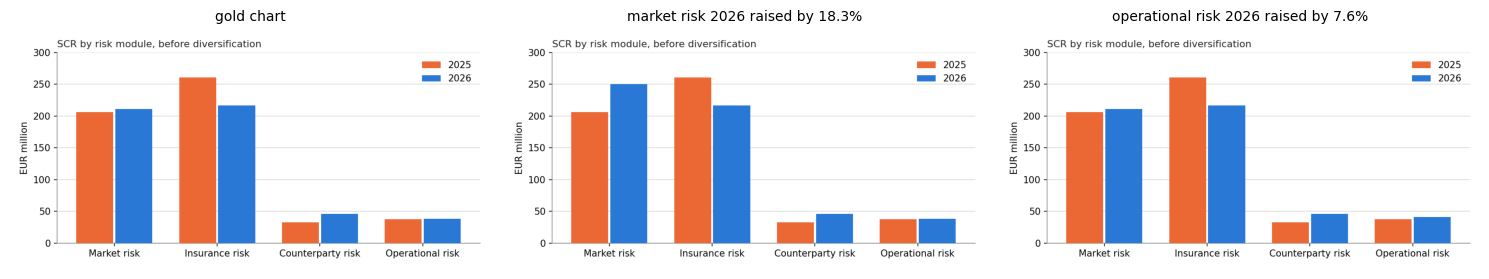

In [32]:
CALIBRATION = RECORDINGS["chart"]["calibration"]
VARIANTS = RECORDINGS["gate"]["chart_variants"]
print(f"Calibration on the gold chart: {len(CALIBRATION['reads'])} reads, largest relative error "
      f"{CALIBRATION['max_abs_relative_error']:.2%}; threshold {CALIBRATION['threshold']:.2%} ({CALIBRATION['rule']}).")
print(f"Distinct answers among the three reads at 150 dpi: {CALIBRATION['distinct_answers_at_150dpi']}")
rows = []
for label, variant in VARIANTS.items():
    bar, value = next(iter(variant["change"].items()))
    true = FACT[bar]["value"]
    rows.append({"changed chart": label.replace("_", " "), "bar": bar, "facts": true, "drawn": value,
                 "change": f"{value / true - 1:+.1%}",
                 "read by the model": ", ".join(str(r["compare"]["bars"][bar]) for r in variant["reads"]),
                 "flagged by L-CHART": f"{sum(bar in r['flagged_bars'] for r in variant['reads'])} of {len(variant['reads'])}",
                 "ranking changed": f"{sum(bool(r['rank_changed']) for r in variant['reads'])} of {len(variant['reads'])}",
                 "D-CHART (provenance)": "error" if variant["d_chart"] else "pass"})
display(pd.DataFrame(rows).set_index("changed chart"))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.3))
for ax, (title, file) in zip(axes, [("gold chart", "chart_scr_modules.png"),
                                    ("market risk 2026 raised by 18.3%", VARIANTS["well_above"]["file"]),
                                    ("operational risk 2026 raised by 7.6%", VARIANTS["near_threshold"]["file"])]):
    ax.imshow(plt.imread(BUILD_DIR / file))
    ax.set_title(title, fontsize=10)
    ax.axis("off")
fig.tight_layout()
plt.show()

if RUN_VISION_LIVE and can_call(LUNA):
    llm.configure(purpose="blind chart read (section 6.4)")
    for label, variant in VARIANTS.items():
        read = lc.read_chart(BUILD_DIR / variant["file"], model=LUNA, run_id=f"notebook_chart_{label}")
        if read["status"] == "ok":
            compared = lc.compare_chart(read["parsed"], FACTS)
            flagged = sorted(k for k, v in compared["deviation"].items() if abs(v) > THRESHOLD)
            print(f"Live read of the {label.replace('_', ' ')} chart: flagged {flagged or 'nothing'}, "
                  f"USD {read['call']['usd']:.6f}")
        else:
            print(f"[ATTENTION] The live read of the {label.replace('_', ' ')} chart failed "
                  f"({read['status']}: {str(read['call']['error'])[:120]}); the recorded reads above stand.")

**The model reads a large change and misses a small one; code catches both for free.** The bar raised by 18.3% was read at 250 in all three reads and flagged each time, with the change of ranking. The bar raised by 7.6% — a little above the threshold of 6.64% — was read as 40 instead of 41.3 and flagged in none of the three reads: the reading error ate the change. The provenance check `D-CHART`, which compares the chart with the reference render of `facts.json`, flagged both changed charts, at no cost. A blind read earns its place only for a chart whose data are not at hand — a chart pasted in from elsewhere, or last year's report. When code draws the chart, code can check it.

---

## 7 Planted errors, hold-out errors and the clean control

### Why it matters for actuaries

A checker is a model, and a model is validated before it is used. The validation needs errors whose location is known (planted errors), a document that is known to be right (the clean control), and — the part most easily skipped — errors that the author of the checks did not write. Checks and planted errors written by the same hand agree by construction: the author plants the kind of error the checks look for, in the words they look for. So the errors come in two batches, and the recall of each is reported separately. The hold-out batch is independent in its sentences and wording, not in its categories, which the author of the checks wrote. A gap between the batches therefore mixes fitting with a different mix of categories, and section 7.3 separates the two.

### 7.1 Sixteen planted errors in two batches

The **development batch** (E01–E10) was planted by the author of the case study while writing the checks, and was allowed to shape them. The checks were then frozen. The **hold-out batch** (H01–H06) was planted after the freeze by GPT-6 Sol, which saw the rendered gold document, the facts, the bullets and a list of error categories written by the author of the checks, never the checks or their prompts. Its second call also listed as off limits the gold text of the sentences already used by the development batch and by its own first call. Each batch contains one error that no check targets by design (E10, H06): an honest gate has blind spots, and the measurement should show them.

In [33]:
import difflib

ERRORS = json.loads((BUILD_DIR / "error_log.json").read_text(encoding="utf-8"))["errors"]


def edit_summary(old: str, new: str, width: int = 60) -> str:
    """The words an edit changed, as 'old -> new'."""
    a, b = old.split(), new.split()
    parts = []
    for tag, i1, i2, j1, j2 in difflib.SequenceMatcher(None, a, b).get_opcodes():
        if tag != "equal":
            parts.append(f"'{' '.join(a[i1:i2]) or '(nothing)'}' -> '{' '.join(b[j1:j2]) or '(nothing)'}'")
    return "; ".join(parts)[:width] if parts else "(whole passage)"


with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame([{
        "error": e["id"], "batch": "development" if e["batch"] == "dev" else "hold-out",
        "category": re.split(r"[;:(,]", e["category"])[0].strip(),
        "the error": e["wrong"] if e["batch"] == "dev" else edit_summary(e["old"], e["new"], 70),
        "targeted by a check": "no, by design" if e.get("unguarded") else "yes"} for e in ERRORS]).set_index("error"))

,batch,category,the error,targeted by a check
error,,,,
E01,development,ratio recomputed wrong,212%,yes
E02,development,prior-year value in a current-year slot,EUR 373.1 million (the 2026 value) for 2025,yes
E03,development,direction word contradicts the sign,increased,yes
E04,development,'%' where 'percentage points',16%,yes
E05,development,prescribed text paraphrased,shall,yes
E06,development,language notice missing,(no notice),yes
E07,development,required element missing,no compliance statement,yes
E08,development,causal claim with no supporting bullet,cause stated (new claims-handling system),yes
E09,development,chart bar changed,market risk 2026 bar drawn at EUR 250.0 million (+18%; changes the module ranking),yes


### 7.2 The protocol: freeze first, then plant

The order is what makes the hold-out batch a hold-out. The cell prints the timestamps and the category list Sol was given. Two of Sol's first six proposals edited sentences that the development batch had already used; a rule fixed in code before the call rejected them, and a second call, with those sentences listed as off limits, replaced them.

In [34]:
HOLDOUT = RECORDINGS["holdout_planter"]
print(f"Checks frozen            : {FREEZE['frozen_utc']} (sha256 of cs5_checks.py {FREEZE['cs5_checks.py'][:12]}..., "
      f"of the prompts {FREEZE['llm_prompts_schemas_settings'][:12]}...)")
print(f"Hold-out planter called  : {HOLDOUT['called_utc']}, {HOLDOUT['model']} at effort '{HOLDOUT['effort']}', "
      f"USD {HOLDOUT['usd'] + HOLDOUT['round2']['usd']:.4f} for two calls")
print("What the planter saw     : the rendered gold document, facts.json, drivers.md and these categories, written by")
print("                           the author of the checks:")
for category_id, text in HOLDOUT["categories"]:
    print(f"  {category_id}: {text}")
print(f"Off limits in the second call: {HOLDOUT['round2']['off_limits_count']} sentences already used "
      "(their gold text only)")
print(f"Accepted from round 1    : {sum(e['planted_by'].endswith('round 1') for e in ERRORS)}; from round 2: "
      f"{sum(e['planted_by'].endswith('round 2') for e in ERRORS)}")

Checks frozen            : 2026-09-23T10:09:00Z (sha256 of cs5_checks.py 96c9ecb36a10..., of the prompts 0d688651e3cd...)
Hold-out planter called  : 2026-09-23T10:09:30Z, gpt-6-sol at effort 'low', USD 0.0342 for two calls
What the planter saw     : the rendered gold document, facts.json, drivers.md and these categories, written by
                           the author of the checks:
  H1: a direction word that contradicts the figures; use a different verb or phrasing than 'increased' or 'decreased' (for example 'declined', 'was lower', 'dropped', 'edged up')
  H2: a figure changed subtly in the prose (for example the last digit), so that it no longer matches the facts
  H3: a causal claim that the driver bullets do not support; use a causal phrase other than 'because' or 'driven by'
  H4: a technical insurance or regulatory term or abbreviation that a policyholder would not know, inserted without explanation
  H5: a real spelling mistake (not a British/American variant)
  H6: an error

### 7.3 Scoring the gate, in one cell

A planted error counts as caught if **any** check reports a finding at its location — its sentence, its element, or the document-level check for a deletion or the chart — that quotes the changed words or that the gold document does not also get. Findings on the planted document that match no planted error are false alarms. The cell scores every recorded run of all checks on the planted document from the stored findings: five runs with GPT-6 Luna, one with GPT-6 Sol, and the live run of section 6 if there was one. The labels come from `error_log.json`, loaded in 7.1, so if a label changes, running the cell of 7.1 and this one again rescores every run with no paid call. A changed gold version is different: the planted document would change with it, and the recorded runs on both documents would have to be made again, at a cost. Recall is given at three levels: all checks, the deterministic and LLM text checks without the chart read, and the deterministic checks alone.

In [35]:
PLANTED_RUNS = [r for r in RECORDINGS["gate"]["runs"] if r["doc"] == "planted.md"]
GOLD_RUNS = [r for r in RECORDINGS["gate"]["runs"] if r["doc"] == "gold.md"]
DET_GOLD_KEYS = {sc.fkey(f) for f in RECORDINGS["gate"]["deterministic_only"]["gold.md"]["findings"]}

if RUN_REPEATS_LIVE and can_call(LUNA):
    llm.configure(purpose="repeated runs (section 7)")
    added = 0
    for i in range(1, N_REPEATS + 1):
        with ThreadPoolExecutor(max_workers=2) as pool:
            futures = {name: pool.submit(lc.run_gate, DOCS[name], model=LUNA, run_id=f"repeat_{name}_{i}", vision=True,
                                         chart_threshold=THRESHOLD) for name in ("gold", "planted")}
            runs = {name: future.result() for name, future in futures.items()}
        for name, target in (("gold", GOLD_RUNS), ("planted", PLANTED_RUNS)):
            if failed_calls(runs[name]):  # a failed call is no result of the checks: the run is not scored
                print(f"[ATTENTION] Repeat {i} on {name}: {failed_calls(runs[name])[0][:120]} - not added.")
            else:
                target.append(runs[name])
                added += 1
    print(f"{added} live run(s) of all checks added ({N_REPEATS} repeat(s) on gold and planted requested).")


def gold_keys(model: str) -> set:
    """Findings the gold document gets from this model's runs: on the planted document they are not catches."""
    runs = GOLD_RUNS + ([GATE["gold"]] if GATE_SOURCE.get("gold") == "live" and model == LUNA else [])
    return {sc.fkey(f) for r in runs if r["model"] == model for f in r["findings"]}


def only(result: dict, kinds: set) -> dict:
    return {**result, "findings": [f for f in result["findings"] if f["kind"] in kinds]}


def score_levels(result: dict) -> dict:
    keys = gold_keys(result["model"])
    return {"all": sc.score_run(result, ERRORS, keys),
            "text": sc.score_run(only(result, {"deterministic", "llm"}), ERRORS, keys),
            "deterministic": sc.score_run(only(result, {"deterministic"}), ERRORS, DET_GOLD_KEYS)}


SCORED = {r["run_id"]: score_levels(r) for r in PLANTED_RUNS}
RUN_INFO = {r["run_id"]: r for r in PLANTED_RUNS}
if GATE_SOURCE.get("planted") == "live":
    SCORED["this session"] = score_levels(GATE["planted"])
    RUN_INFO["this session"] = GATE["planted"]


def k_of(per_error: dict, **kwargs) -> str:
    k, n = sc.recall(per_error, **kwargs)
    return f"{k}/{n}"


RECALL = pd.DataFrame([{
    "run": run_id, "model": RUN_INFO[run_id]["model"],
    "development": k_of(s["all"]["per_error"], batch="dev"),
    "hold-out": k_of(s["all"]["per_error"], batch="holdout"),
    "all 16 [95% interval]": "{} [{:.2f}, {:.2f}]".format(k_of(s["all"]["per_error"]),
                                                          *sc.wilson(*sc.recall(s["all"]["per_error"]))),
    "targeted only (dev, hold-out)": f"{k_of(s['all']['per_error'], batch='dev', guarded_only=True)}, "
                                     f"{k_of(s['all']['per_error'], batch='holdout', guarded_only=True)}",
    "without the chart read": k_of(s["text"]["per_error"]),
    "deterministic only (dev, hold-out)": f"{k_of(s['deterministic']['per_error'], batch='dev')}, "
                                          f"{k_of(s['deterministic']['per_error'], batch='holdout')}",
    "caught as an error": k_of(s["all"]["per_error"], key="caught_as_error"),
    "false alarms (errors, warnings)": f"{s['all']['n_false_alarm_errors']}, {s['all']['n_false_alarm_warnings']}"}
    for run_id, s in SCORED.items()]).set_index("run")
display(RECALL)

,model,development,hold-out,all 16 [95% interval],"targeted only (dev, hold-out)",without the chart read,"deterministic only (dev, hold-out)",caught as an error,"false alarms (errors, warnings)"
run,,,,,,,,,
planted_luna_1,gpt-6-luna,9/10,5/6,"14/16 [0.64, 0.96]","9/9, 5/5",14/16,"8/10, 2/6",10/16,"0, 5"
planted_luna_2,gpt-6-luna,9/10,5/6,"14/16 [0.64, 0.96]","9/9, 5/5",14/16,"8/10, 2/6",10/16,"0, 4"
planted_luna_3,gpt-6-luna,9/10,5/6,"14/16 [0.64, 0.96]","9/9, 5/5",14/16,"8/10, 2/6",10/16,"0, 8"
planted_luna_4,gpt-6-luna,9/10,5/6,"14/16 [0.64, 0.96]","9/9, 5/5",14/16,"8/10, 2/6",10/16,"0, 7"
planted_luna_5,gpt-6-luna,9/10,5/6,"14/16 [0.64, 0.96]","9/9, 5/5",14/16,"8/10, 2/6",10/16,"0, 8"
planted_sol_1,gpt-6-sol,9/10,5/6,"14/16 [0.64, 0.96]","9/9, 5/5",14/16,"8/10, 2/6",10/16,"0, 6"
this session,gpt-6-luna,9/10,5/6,"14/16 [0.64, 0.96]","9/9, 5/5",14/16,"8/10, 2/6",10/16,"0, 7"


**Every run finds 14 of the 16 planted errors: 9 of 10 of the development batch and 5 of 6 of the hold-out batch.** That holds for all five Luna runs and for the Sol run, and excluding the two errors no check targets, it is every targeted error of both batches. These are the headline figures of the case study, and they are those of the frozen checks. Read them with their interval: 14 of 16 is compatible with a true recall anywhere from about 0.64 to 0.96 — sixteen errors are few. In the saved run, the live checks of section 6 on the planted document found 14 of 16 (9 of 10 and 5 of 6), with 7 false alarms (0 of them errors); the chart read in that run is the recorded one.

Two columns tell more than the headline. **The deterministic checks alone** find 8 of 10 of the development batch but only 2 of 6 of the hold-out batch. Most of that gap comes from the mix of categories, not from rules fitted to their author's wording. No deterministic check looks at causes or spelling, and the hold-out categories, written like the development ones by the author of the checks, include one of each (H03, H05); the development batch has one such error (E08). Leave those out, together with the unguarded E10 and H06, and the rules found all 8 remaining development errors (E04 through `D-TIE`, for the wrong reason: see 7.5) and 2 of the 3 in the hold-out batch. Where Sol was told to vary the wording, the rules either caught the error or had no rule for it: its "fell" (H01) was caught by `D-DIR`, and its "as a result of" (H03) states a cause, which only `L-SUPPORT` reads, as with "driven by" in E08. The one error that got past a rule written for its category is a jargon term that is not on the list (H04). The LLM layer catches H03, H04 and H05. **Caught as an error** is 10 of 16: four catches — an unsupported cause twice, a jargon term, a misspelling — exist only as LLM warnings, which a reviewer has to read to benefit from.

### 7.4 The runs, one by one

The five recorded Luna runs and the one Sol run, with their cost and time; then the same checks on the gold document, where every finding is a false alarm or something the reviewer accepts.

In [36]:
def run_row(r: dict) -> dict:
    findings = r["findings"]
    return {"run": r["run_id"], "model": r["model"], "USD": round(r["usd"], 6), "seconds": r["seconds"],
            "findings": len(findings), "errors": sum(f["severity"] == "error" for f in findings),
            "warnings": sum(f["severity"] == "warning" for f in findings)}


planted_table = pd.DataFrame([{**run_row(r), "recall (dev, hold-out)": f"{RECALL.loc[r['run_id'], 'development']}, "
                                                                        f"{RECALL.loc[r['run_id'], 'hold-out']}",
                               "false alarms (warnings)": SCORED[r["run_id"]]["all"]["n_false_alarm_warnings"]}
                              for r in PLANTED_RUNS]).set_index("run")
gold_table = pd.DataFrame([{**run_row(r), "by check": ", ".join(f"{c} {n}" for c, n in Counter(
    f["check_id"] for f in r["findings"]).most_common())} for r in GOLD_RUNS]).set_index("run")
print("Planted document")
display(planted_table)
print("Gold document (the clean control)")
with pd.option_context("display.max_colwidth", None):
    display(gold_table)
luna_gold = [r for r in GOLD_RUNS if r["model"] == LUNA]
luna_planted = [r for r in PLANTED_RUNS if r["model"] == LUNA]
print(f"Mean per Luna run of all checks: USD {np.mean([r['usd'] for r in luna_gold + luna_planted]):.4f}, "
      f"{np.mean([r['seconds'] for r in luna_gold + luna_planted]):.1f} seconds; Sol: USD "
      f"{np.mean([r['usd'] for r in PLANTED_RUNS + GOLD_RUNS if r['model'] == SOL]):.4f}, "
      f"{np.mean([r['seconds'] for r in PLANTED_RUNS + GOLD_RUNS if r['model'] == SOL]):.1f} seconds")

Planted document


,model,USD,seconds,findings,errors,warnings,"recall (dev, hold-out)",false alarms (warnings)
run,,,,,,,,
planted_luna_1,gpt-6-luna,0.003081,29.80,36,19,17,"9/10, 5/6",5
planted_luna_2,gpt-6-luna,0.002048,37.05,35,19,16,"9/10, 5/6",4
planted_luna_3,gpt-6-luna,0.002036,28.79,35,19,16,"9/10, 5/6",8
planted_luna_4,gpt-6-luna,0.001993,31.97,32,19,13,"9/10, 5/6",7
planted_luna_5,gpt-6-luna,0.002066,39.48,36,19,17,"9/10, 5/6",8
planted_sol_1,gpt-6-sol,0.065705,48.37,33,19,14,"9/10, 5/6",6


Gold document (the clean control)


,model,USD,seconds,findings,errors,warnings,by check
run,,,,,,,
gold_luna_1,gpt-6-luna,0.002680,34.20,9,0,9,"L-AUDIENCE 8, L-COVER 1"
gold_luna_2,gpt-6-luna,0.001880,30.49,11,0,11,"L-AUDIENCE 8, L-SUPPORT 2, L-COVER 1"
gold_luna_3,gpt-6-luna,0.001884,31.32,10,0,10,"L-AUDIENCE 8, L-SUPPORT 1, L-COVER 1"
gold_luna_4,gpt-6-luna,0.001874,28.74,9,0,9,"L-AUDIENCE 8, L-SUPPORT 1"
gold_luna_5,gpt-6-luna,0.001874,29.46,10,0,10,"L-AUDIENCE 8, L-SUPPORT 2"
gold_sol_1,gpt-6-sol,0.063611,42.18,10,0,10,"L-AUDIENCE 8, L-SUPPORT 2"


Mean per Luna run of all checks: USD 0.0021, 32.1 seconds; Sol: USD 0.0647, 45.3 seconds


**Five runs at temperature 0 agree on the errors and disagree on the noise.** Recall is the same in every run; what varies is the number of warnings — 4 to 8 false alarms per Luna run on the planted document, and 9 to 11 warnings per run on the gold document, none of them an error. On gold, `L-AUDIENCE` returns 8 warnings in every run, the most its prompt allows; `L-SUPPORT` flags between 0 and 2 sentences per run, always from the same two, the gold document's two borderline inferences: G5, added in 4.6 by the author of the case study, and the fresh draft's own sentence on counterparty risk, which 4.6 left unchanged (J25 and J26 of section 8); and `L-COVER` calls one element partly covered in three of the five Luna runs and not in the Sol run. A run of all checks on one document costs about USD 0.0021 with Luna and takes about 32 seconds; the Sol run on the planted document cost USD 0.0657 — about 30 times as much — for the same recall and 6 false alarms on the planted document. At this sample size a stronger model buys nothing measurable; section 8 makes the same point for the judge alone.

### 7.5 What the gate misses, and a catch for the wrong reason

The table shows, error by error, how many of the five Luna runs caught it, whether Sol and the deterministic checks alone did, and which checks fired.

In [37]:
luna_ids = [r["run_id"] for r in PLANTED_RUNS if r["model"] == LUNA]
sol_id = next(r["run_id"] for r in PLANTED_RUNS if r["model"] == SOL)
PER_ERROR = pd.DataFrame([{
    "error": e["id"], "batch": e["batch"],
    "Luna runs": f"{sum(SCORED[r]['all']['per_error'][e['id']]['caught'] for r in luna_ids)}/{len(luna_ids)}",
    "Sol": "yes" if SCORED[sol_id]["all"]["per_error"][e["id"]]["caught"] else "no",
    "deterministic only": "yes" if SCORED[luna_ids[0]]["deterministic"]["per_error"][e["id"]]["caught"] else "no",
    "as an error": "yes" if SCORED[luna_ids[0]]["all"]["per_error"][e["id"]]["caught_as_error"] else "no",
    "checks that caught it (all runs)": ", ".join(sorted({c for r in luna_ids + [sol_id]
                                                          for c in SCORED[r]["all"]["per_error"][e["id"]]["checks"]})) or "none"}
    for e in ERRORS]).set_index("error")
display(PER_ERROR)
e04 = next(e for e in ERRORS if e["id"] == "E04")
e04_findings = [f for f in DET["planted"]["findings"] if f["sid"] in e04["sids"]]
for f in e04_findings:
    print(f"E04 '{e04['find']}': {f['check_id']} says '{f['message']}', expected '{f['expected']}', actual '{f['actual']}'")

,batch,Luna runs,Sol,deterministic only,as an error,checks that caught it (all runs)
error,,,,,,
E01,dev,5/5,yes,yes,yes,"D-ID, D-PER, D-TIE, L-SPELL"
E02,dev,5/5,yes,yes,yes,"D-ID, D-PER, L-EXTRACT"
E03,dev,5/5,yes,yes,yes,"D-DIR, L-AUDIENCE, L-SPELL"
E04,dev,5/5,yes,yes,yes,"D-TIE, L-AUDIENCE, L-SPELL"
E05,dev,5/5,yes,yes,yes,D-TEXT
E06,dev,5/5,yes,yes,yes,D-NOTICE
E07,dev,5/5,yes,yes,yes,"D-SPEC, L-COVER"
E08,dev,5/5,yes,no,no,L-SUPPORT
E09,dev,5/5,yes,yes,yes,"D-CHART, L-CHART"


E04 'increased by 16%': D-TIE says 'number does not trace to facts.json at its printed precision', expected 'nearest fact eof_scr_change_pct = 5.4%', actual '16%'


Three things stand out.

- **Two errors are caught by nothing, as designed.** E10 changes the supervisor's e-mail address to another `.example` address; no check compares text facts with a register of addresses. H06, planted by Sol, says "Table 1 shows the SCR by risk module" where Figure 1 does: `D-XREF` checks that a table or figure exists, not that it shows what the sentence says. A clean gate is not proof of a clean document.
- **E04 is caught for the wrong reason.** "The SCR coverage ratio increased by 16%" should say 16 percentage points. The default gate has no "%" versus "percentage points" check — exercise (b) writes it — so the error is caught by `D-TIE` as an untraceable number, whose nearest fact is the 5.4% rise in own funds. The sentence is flagged; the diagnosis would send the reviewer looking for the wrong fix. Exercise (b) exists because a catch is only as useful as its message.
- **The hold-out gap is in the deterministic layer, and mostly in the mix of categories.** With the LLM checks, both batches are found except the unguarded errors. Without them, the development batch drops to 8 of 10 and the hold-out batch to 2 of 6. No rule judges a cause, so the rules miss the unsupported cause in both batches, E08 as well as H03 ("as a result of the updated investment policy"); the marker scan picks up both sentences, but only the judge can tell that no bullet supports them. The misspelling (H05) is a kind of error the development batch did not contain, and no rule looks for it. Only "excess-of-loss (XL)" (H04) got past a rule written for its kind of error: it is not on the jargon list. Each of the three hold-out errors needed a reader.

The working-group prototype mentioned at the top reported 13 of 13 seeded errors in one run, 9 of them without an LLM — with the checks and the errors written by the same team, which makes such a figure an upper bound. The hold-out batch is this notebook's partial answer to that problem: Sol chose the sentences and the wording but not the categories. The deterministic column above shows how much a recall figure depends on which categories are planted.

### 7.6 LLM "corrections" can be wrong

`L-SPELL` is asked to proofread, not to recompute. On E04 it did both.

In [38]:
e04_spell = [(r["run_id"], f["expected"]) for r in PLANTED_RUNS for f in r["findings"]
             if f["check_id"] == "L-SPELL" and f["sid"] in e04["sids"]]
for run_id, correction in e04_spell:
    print(f"{run_id:<16} L-SPELL proposes: {correction!r}")
wrong = sum("8 percentage points" in c for _, c in e04_spell)
print(f"'8 percentage points' proposed in {wrong} of {len(luna_ids)} Luna runs; the right figure is "
      f"{FACT['cov_scr_change_pp']['display_en']} ({FACT['cov_scr_prev']['display_en']} to {FACT['cov_scr_cur']['display_en']}).")

planted_luna_1   L-SPELL proposes: 'increased by 8 percentage points'
planted_luna_2   L-SPELL proposes: 'increased by 8 percentage points'
planted_luna_3   L-SPELL proposes: 'The SCR coverage ratio increased by 8 percentage points'
planted_luna_5   L-SPELL proposes: 'increased by 8 percentage points'
'8 percentage points' proposed in 4 of 5 Luna runs; the right figure is 16 percentage points (204% to 220%).


In 4 of the 5 Luna runs the proofreader "corrected" 16% to 8 percentage points: it computed the relative change of the ratio, 8%, and put the wrong unit on the wrong number. A reviewer who accepted the suggestion would have replaced one error with another. This is why an LLM finding carries its evidence and stays a warning — and why a suggested correction is not a correction until code or a person has checked it.

---

## 8 The judge needs its own test set

### Why it matters for actuaries

`L-SUPPORT` is an LLM acting as a judge: it decides whether a stated cause is supported by the bullets. Section 7 measured it on two planted errors, E08 and H03, which is not a validation. A judge is validated like any classifier — on labelled items, with its hits and its false alarms counted separately and reported with intervals — and the items must be judged with the same prompt, schema and settings as the gate; otherwise the test validates a different judge. Where the labels themselves are a matter of judgement, the answer does not come from the model either: how strict a judge should be is a written policy.

### 8.1 Thirty labelled sentences

The test set has 30 sentences about Brisendale Mutual's year, each labelled against the six bullets, with the bullet it rests on and a one-line rationale. The labels are drafts that no actuary has confirmed yet — read them as critically as the judge's verdicts. The set holds:

- 12 **supported** sentences: a bullet gives the same cause for the same effect, 5 of them in other words;
- 12 **unsupported** sentences: a cause no bullet gives, a contradiction of a bullet, a bullet stretched to other lines of business, a reason presented as known where a bullet says it is not, a wrong cause;
- 6 **borderline** sentences, a category of their own: reasonable actuarial inferences that combine bullets or carry them one step further ("net claims incurred rose because motor repair costs went up and the October windstorm caused many claims"), and one sentence that states no cause. They are reported separately and kept out of the hit and false-alarm rates.

**Hit** means an unsupported sentence flagged; **false alarm** means a supported sentence flagged; a verdict of "cannot tell", or a quote that code cannot ground, counts as a flag. The set is split for exercise (c): 20 sentences for tuning, whose labels are shown below, and 10 held out, whose labels the notebook does not show until you have tested your own policy on them — except the borderline category, which stays visible in both parts. All 30 labels are in the bundle's `judge_testset.json`, readable by anyone: the held-out split works on trust, so do not open that file before your policy is final. The cell prints the checksum of the held-out labels so that you can see they have not changed, and exercise (c) asks you to score them once, at the end.

In [39]:
JUDGE_SET = json.loads((BUILD_DIR / "judge_testset.json").read_text(encoding="utf-8"))
JUDGE_ITEMS = {x["id"]: x for x in JUDGE_SET["items"]}
tuning = [i for i in JUDGE_SET["presentation_order"] if JUDGE_ITEMS[i]["split"] == "dev"]
held_out = [i for i in JUDGE_SET["presentation_order"] if JUDGE_ITEMS[i]["split"] == "test"]
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame([{"id": i, "label": JUDGE_ITEMS[i]["label"], "type": JUDGE_ITEMS[i]["type"],
                           "bullet": JUDGE_ITEMS[i]["bullet_id"], "sentence": JUDGE_ITEMS[i]["sentence"]}
                          for i in sorted(tuning)]).set_index("id"))
    print("The 10 held-out sentences (labels not shown, except the borderline category):")
    for i in sorted(held_out):
        print(f"  [{i}] {JUDGE_ITEMS[i]['sentence']}{'  (borderline)' if JUDGE_ITEMS[i]['label'] == 'borderline' else ''}")
test_blob = json.dumps(sorted([[x["id"], x["label"]] for x in JUDGE_SET["items"] if x["split"] == "test"]))
same = hashlib.sha256(test_blob.encode("utf-8")).hexdigest() == JUDGE_SET["test_labels_sha256"]
print(f"{'[PASS]' if same else '[ATTENTION]'} held-out labels: sha256 {JUDGE_SET['test_labels_sha256'][:12]}... "
      f"{'as written on' if same else 'differ from the version of'} {JUDGE_SET['written_utc'][:10]}")
print("Composition:", {split: dict(Counter(JUDGE_ITEMS[i]["label"] for i in ids)) for split, ids in
                       (("tuning", tuning), ("held out", held_out))})

,label,type,bullet,sentence
id,,,,
J01,supported,direct,DR1,The average cost of a motor claim went up because spare parts and labour became more expensive.
J02,supported,direct,DR4,"The October windstorm caused a large number of home insurance claims, mainly for roof and fence damage."
J04,supported,direct,DR3,The market value of our bonds increased because euro interest rates fell in the second half of the year.
J05,supported,direct,DR2,Amounts owed by reinsurers increased because of the new quota-share contract for motor insurance.
J06,supported,direct,DR4,Home insurance claims rose after a windstorm in October.
J07,supported,direct,DR1,Higher prices for spare parts and labour increased the average cost of motor claims.
J08,supported,paraphrase,DR1,"Because repairs cost more, each motor claim was more expensive on average."
J10,supported,paraphrase,DR2,Passing part of every motor policy to reinsurers lowered the motor insurance risk we retain.
J13,unsupported,missing_cause,none,Motor premiums grew because we raised our prices.


The 10 held-out sentences (labels not shown, except the borderline category):
  [J03] The new quota-share reinsurance contract reduces the insurance risk that Brisendale Mutual keeps.
  [J09] Falling euro interest rates pushed up the value of the bonds we hold.
  [J11] Roof and fence damage from the October storm led to many home claims.
  [J12] The quota share passes a fixed share of motor claims to reinsurers, so we keep less of the motor insurance risk.
  [J14] Home premiums increased because more customers in Lithuania bought our policies.
  [J18] The new reinsurance contract increased the insurance risk that we keep.
  [J19] Repair costs rose across all our lines of business, raising the average cost of every claim.
  [J24] Claims costs rose because euro interest rates fell.
  [J28] The reasons for the higher operating expenses have not yet been analysed.  (borderline)
  [J30] The combined ratio deteriorated as a result of higher motor repair costs and the windstorm.  (borderline)

### 8.2 The same judge as the gate

The judge test calls `support_judge()` — the function `L-SUPPORT` uses in the gate — with its prompt, schema and settings, in batches of 10 sentences in a fixed shuffled order. The cell compares the fingerprints: of the judge as the code defines it now, of the `L-SUPPORT` calls in the recorded gate runs, and of the recorded judge runs.

In [40]:
JUDGE_RUNS = list(RECORDINGS["judge"]["runs"])
gate_fingerprints = {r["model"]: r["llm_stats"]["L-SUPPORT"]["call"]["fingerprint"] for r in RECORDINGS["gate"]["runs"]}
for model in (LUNA, SOL):
    now = llm.fingerprint(model, lc.SUPPORT_PROMPT, lc.SUPPORT_SCHEMA)
    judge_fps = {r["fingerprint"] for r in JUDGE_RUNS if r["model"] == model}
    ok = judge_fps == {now} and gate_fingerprints[model] == now
    print(f"{'[PASS]' if ok else '[ATTENTION]'} {model}: judge test and gate use fingerprint {now[:12]}"
          + ("" if ok else f" - recorded judge {sorted(judge_fps)}, gate {gate_fingerprints[model][:12]}"))

if RUN_JUDGE_LIVE and can_call(LUNA):
    llm.configure(purpose="judge test (section 8)")
    verdicts, calls, started = {}, [], time.perf_counter()
    order = JUDGE_SET["presentation_order"]
    for k in range(0, len(order), JUDGE_SET["batch_size"]):
        batch = [(i, JUDGE_ITEMS[i]["sentence"]) for i in order[k:k + JUDGE_SET["batch_size"]]]
        result = lc.support_judge(batch, DRIVERS, model=LUNA, run_id="judge_live", step="judge")
        calls.append(result["call"])
        verdicts.update(result["judgements"])
        if result["call"]["status"] != "ok":
            break  # the next batch would be paid for nothing
    failed = [f"{c['status']} ({c['error']})" for c in calls if c["status"] != "ok"]
    if failed:  # a failed call is no verdict of the judge: the run is not added
        print(f"[ATTENTION] A judge call failed ({failed[0][:120]}); the table shows the recorded runs only.")
    else:
        JUDGE_RUNS.append({"run_id": "judge_live (this session)", "model": LUNA, "verdicts": verdicts, "calls": calls,
                           "usd": sum(c["usd"] for c in calls), "seconds": round(time.perf_counter() - started, 2),
                           "fingerprint": llm.fingerprint(LUNA, lc.SUPPORT_PROMPT, lc.SUPPORT_SCHEMA)})
        print(f"Live judge run: {len(calls)} calls, USD {JUDGE_RUNS[-1]['usd']:.6f}")

[PASS] gpt-6-luna: judge test and gate use fingerprint 89c5a762a780
[PASS] gpt-6-sol: judge test and gate use fingerprint 4c8ad7afdac1


### 8.3 Hits, false alarms and the borderline category

Four recorded runs of 23 September 2026 — three with GPT-6 Luna, one with GPT-6 Sol — each over all 30 sentences. The clear sentences give the rates, each with a 95% Wilson interval; the borderline sentences are counted on their own.

In [41]:
FLAG = {"unsupported", "cannot_tell", "not_verifiable"}


def judge_scores(run: dict, split: str | None = None) -> dict:
    verdicts = run["verdicts"]
    pick = lambda label: [i for i, x in JUDGE_ITEMS.items() if x["label"] == label and (split is None or x["split"] == split)]  # noqa: E731
    unsupported, supported, borderline = pick("unsupported"), pick("supported"), pick("borderline")
    hits = sum(verdicts[i]["status"] in FLAG for i in unsupported)
    alarms = sum(verdicts[i]["status"] in FLAG for i in supported)
    return {"hits": f"{hits}/{len(unsupported)}", "hit interval": "[{:.2f}, {:.2f}]".format(*sc.wilson(hits, len(unsupported))),
            "false alarms": f"{alarms}/{len(supported)}",
            "false-alarm interval": "[{:.2f}, {:.2f}]".format(*sc.wilson(alarms, len(supported))),
            "borderline flagged": f"{sum(verdicts[i]['status'] in FLAG for i in borderline)}/{len(borderline)}",
            "cannot tell": sum(verdicts[i]["status"] == "cannot_tell" for i in unsupported + supported + borderline),
            "quote not grounded": sum(verdicts[i]["status"] == "not_verifiable" for i in unsupported + supported + borderline)}


display(pd.DataFrame([{"run": r["run_id"], "model": r["model"], **judge_scores(r), "USD": round(r["usd"], 6),
                       "seconds": r["seconds"]} for r in JUDGE_RUNS]).set_index("run"))

luna_judge = [r for r in JUDGE_RUNS if r["model"] == LUNA][:3]
flipped = [i for i in JUDGE_ITEMS if len({r["verdicts"][i]["status"] for r in luna_judge}) > 1]
clear = [i for i, x in JUDGE_ITEMS.items() if x["label"] in ("supported", "unsupported")]
sol_run = next(r for r in JUDGE_RUNS if r["model"] == SOL)


def right(run: dict, item: str) -> bool:
    return (run["verdicts"][item]["status"] in FLAG) == (JUDGE_ITEMS[item]["label"] == "unsupported")


only_luna = sum(right(luna_judge[0], i) and not right(sol_run, i) for i in clear)
only_sol = sum(right(sol_run, i) and not right(luna_judge[0], i) for i in clear)
flipped_text = ", ".join(f"{i} ({JUDGE_ITEMS[i]['label']})" for i in flipped) or "none"
print(f"Verdicts that changed between the three Luna runs: {len(flipped)} of 30 ({flipped_text})")
print(f"Sol against Luna run 1 on the 24 clear sentences: {only_luna} right only for Luna, {only_sol} right only for Sol; "
      f"exact McNemar p = {sc.exact_mcnemar(only_luna, only_sol)}")

,model,hits,hit interval,false alarms,false-alarm interval,borderline flagged,cannot tell,quote not grounded,USD,seconds
run,,,,,,,,,,
judge_luna_1,gpt-6-luna,12/12,"[0.76, 1.00]",0/12,"[0.00, 0.24]",6/6,1,0,0.001206,17.25
judge_luna_2,gpt-6-luna,12/12,"[0.76, 1.00]",0/12,"[0.00, 0.24]",4/6,0,0,0.001232,17.59
judge_luna_3,gpt-6-luna,12/12,"[0.76, 1.00]",0/12,"[0.00, 0.24]",5/6,1,0,0.001213,17.52
judge_sol_1,gpt-6-sol,12/12,"[0.76, 1.00]",0/12,"[0.00, 0.24]",6/6,1,0,0.026398,38.59


Verdicts that changed between the three Luna runs: 2 of 30 (J25 (borderline), J28 (borderline))
Sol against Luna run 1 on the 24 clear sentences: 0 right only for Luna, 0 right only for Sol; exact McNemar p = 1.0


**On the clear sentences the judge is right every time; on the borderline inferences it is strict, and not consistently so.** Each run flags all 12 unsupported sentences and none of the 12 supported ones. That sounds perfect, and the intervals say what it is worth: 12 hits in 12 are compatible with a hit rate as low as 0.76, and 0 false alarms in 12 with a false-alarm rate as high as 0.24. Twelve items per class cannot show more. The borderline sentences tell the more useful story. Of the five inferences, the Luna runs flagged 5, 4 and 4, and Sol 5. The sixth, J28, states no cause, so its verdict says nothing about strictness: "cannot tell", the prompt's own answer for that case, came back in Luna runs 1 and 3 and from Sol, and "supported" in run 2. The table's "borderline flagged" column counts J28 too, so it reads 6, 4 and 5 for Luna and 6 for Sol. The 2 verdicts that changed between the three Luna runs at temperature 0 are J25 and J28.

**Sol against Luna:** 0 discordant clear sentences, so the exact McNemar test gives p = 1.0: **no difference is detectable at this sample size**. With paired data, at least six discordant sentences, all in the same direction, would be needed for p < 0.05. And the comparison changes two things at once — the model, and effort `none` against `low` — so even a difference would not say which of them caused it. The Sol run cost USD 0.0264, Luna about USD 0.0012 per run.

### 8.4 The borderline six: how strict should the judge be?

The table shows, for each borderline sentence, what each run decided.

In [42]:
borderline = [i for i, x in JUDGE_ITEMS.items() if x["label"] == "borderline"]
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame([{"id": i, "sentence": JUDGE_ITEMS[i]["sentence"], "why borderline": JUDGE_ITEMS[i]["rationale"],
                           **{r["run_id"]: r["verdicts"][i]["status"] for r in JUDGE_RUNS}} for i in borderline]).set_index("id"))

,sentence,why borderline,judge_luna_1,judge_luna_2,judge_luna_3,judge_sol_1
id,,,,,,
J25,Net claims incurred rose because motor repair costs went up and the October windstorm caused many home insurance claims.,The causes are in DR1 and DR4; the effect on net claims incurred is an inference.,unsupported,supported,supported,unsupported
J26,Counterparty risk rose because more is now owed by reinsurers under the quota share.,DR2 says more is owed by reinsurers; 'counterparty risk rose' is an inference.,unsupported,unsupported,unsupported,unsupported
J27,The SCR fell mainly because the new motor reinsurance contract reduced the insurance risk we keep.,DR2 supports the lower insurance risk; the link to the SCR total and 'mainly' are inferences.,unsupported,unsupported,unsupported,unsupported
J28,The reasons for the higher operating expenses have not yet been analysed.,Consistent with DR6 but states no causal link.,cannot_tell,supported,cannot_tell,cannot_tell
J29,The investment return rose as euro interest rates fell and bond values increased.,DR3 supports higher bond values; the effect on the return is an inference.,unsupported,unsupported,unsupported,unsupported
J30,The combined ratio deteriorated as a result of higher motor repair costs and the windstorm.,Causes in DR1 and DR4; the effect on the combined ratio is an inference.,unsupported,unsupported,unsupported,unsupported


J25 is the gold document's own sentence G5, and J26 its sentence on counterparty risk. The judge flagged J26 in every run and J25 in some, as it flagged most of the other inferences — which is why `L-SUPPORT` produces warnings on the clean control in some runs (section 7.4). Is that a false alarm or a correct flag? Neither the model nor this notebook can decide it. It is a matter of policy — whether a report may draw a conclusion that combines two bullets, or carries one a step further — and a policy is written down, approved and given to the judge, not left to the model's own sense of strictness, which moves from run to run. Exercise (c) writes such a policy into the prompt and measures what it changes, on the tuning sentences and then once on the held-out ones.

---

## 9 Lithuanian translation

### Why it matters for actuaries

Brisendale Mutual sells in Lithuania under the freedom to provide services, so a policyholder there may ask for the policyholder part in Lithuanian (Art. 298a(1)), and the part must say at its start that this right exists (Art. 292(1)). Recital 45 of Delegated Regulation (EU) 2026/269 spares undertakings certified translations, and machine translation is the obvious way to meet such requests. Art. 298a(1) attaches one duty to it: to disclose that the part has been machine translated. Paragraph 1, the disclosure included, does not apply where the translation in the requested language is available online (Art. 298a(2)). The translation raises the same questions as the draft: are the numbers still the numbers, is the prescribed text still the official one, and would a reader notice if not?

**The Lithuanian texts of this notebook have been checked by machine only.** That covers GPT-6 Luna's translation and the case study's own Lithuanian house texts — the title, the disclosure, the table labels, the captions and the invariant abbreviations such as "proc. punkt." for percentage points. Nobody who built the case study reads Lithuanian; the checks below test numbers, placeholders, the official wording and the disclosure, not fluency. In the room, a Lithuanian participant will be asked to read a paragraph and judge it.

### 9.1 The rules

- **Translate the template, not the text.** The model gets the English paragraphs with their placeholders still in them, keeps each placeholder exactly once, and code renders every number in Lithuanian format: `{{scr_cur}}` becomes "373,1 mln. EUR", `{{cov_scr_cur}}` "220 proc.". "Code owns every number" carries over into the translation.
- **Never machine-translate what has an official text.** The prescribed definition and the section headings of Annex XX are inserted from the official Lithuanian wording in `spec.json`.
- **The disclosure is a fixed text.** It stands at the end of section A: the notice must come first, and Art. 298a says "disclose to that policyholder" without saying where — the place is this notebook's choice.
- **Check fidelity paragraph by paragraph.** An LLM compares each English paragraph with its Lithuanian counterpart and quotes both sides; code grounds both quotes. A back-translation by the same model family would compare the model with itself.

In [43]:
print(tr.TRANSLATE_PROMPT)
LT_HOUSE = core.house_texts(FACTS, "lt")
print(f"\nThe disclosure (a house text, inserted by code):\n  {LT_HOUSE['disclosure']}")
GOLD_TEMPLATE = (BUILD_DIR / "gold_template.md").read_text(encoding="utf-8")
BLOCKS = tr.split_template(GOLD_TEMPLATE)
print(f"\nThe gold template has {len(BLOCKS)} blocks: " + ", ".join(f"{k} {n}" for k, n in Counter(b["kind"] for b in BLOCKS).items()))
print(f"Only the {sum(b['kind'] == 'translate' for b in BLOCKS)} 'translate' blocks go to the model; the rest is inserted by code.")

Translate paragraphs of a report for insurance policy holders from English into Lithuanian.
Rules:
1. Keep every placeholder {{...}} exactly as written, once each. Code replaces it by the value formatted in Lithuanian,
   WITH its unit: {{scr_cur}} becomes "373,1 mln. EUR", {{cov_scr_cur}} becomes "220 proc.", {{cov_scr_change_pp}}
   becomes "16 proc. punkt.", {{year_cur}} becomes "2026", {{date_cur}} becomes "2026 m. gruodžio 31 d.". Do not add a
   unit, a currency or "proc." next to a placeholder, and build each sentence so that the placeholder can stand as it is
   (for example "sudarė {{scr_cur}}"). After a year placeholder write "m." as Lithuanian usage requires
   ("{{year_cur}} m.").
2. Do not write any digits yourself, except the 1 of Table 1 and Figure 1: write "1 lentelė" (any case ending) and
   "1 pav.".
3. Keep e-mail addresses, links and the name Brisendale Mutual unchanged.
4. Terms: Solvency Capital Requirement / SCR = mokumo kapitalo reikalavimas; Minimum Capital Req

### 9.2 The translation

One call to GPT-6 Luna translates the 16 paragraphs; it was recorded on 23 September 2026 and is replayed here unless `RUN_TRANSLATION_LIVE` is on. Code assembles the Lithuanian document around it and renders the numbers. The cell shows the beginning of the result.

In [44]:
TRANSLATION = RECORDINGS["translation"]
assert [b["en"] for b in BLOCKS] == [b["en"] for b in TRANSLATION["blocks"]], "the gold template differs from the recording"
LT_SOURCE = "recorded, 23 September 2026"
LT = TRANSLATION["lt"]
if RUN_TRANSLATION_LIVE and can_call(LUNA):
    llm.configure(purpose="translation (section 9)")
    live_translation = tr.translate(BLOCKS, run_id="notebook_translation")
    if live_translation["call"]["status"] == "ok":
        LT, LT_SOURCE = live_translation["lt"], f"live, USD {live_translation['call']['usd']:.6f}"
    else:
        print(f"[ATTENTION] The live translation failed ({live_translation['call']['status']}: "
              f"{str(live_translation['call']['error'])[:120]}); the recorded translation is used.")
LT_TEMPLATE = tr.assemble_lt(BLOCKS, LT, FACTS, SPEC)
LT_MD = core.render_document(LT_TEMPLATE, FACTS, "lt")
call = TRANSLATION["call"]
print(f"Translation ({LT_SOURCE}); the recorded call: USD {call['usd']:.6f}, {call['seconds']:.1f} seconds, "
      f"{TRANSLATION['n_paragraphs']} paragraphs")
show_document(LT_MD[:LT_MD.index("## C.")])

Translation (recorded, 23 September 2026); the recorded call: USD 0.001403, 18.7 seconds, 16 paragraphs


# Brisendale Mutual: 2026 m. mokumo ir finansinės padėties ataskaita

## Draudėjams ir naudos gavėjams skirta dalis (naujo formato bandomoji versija)

## A. Kalbos, kuriomis ši dalis pateikiama

Turite teisę paprašyti šios dalies versijos oficialiąja tos ES valstybės narės, kurioje gyvenate, kalba, jei toje valstybėje narėje veikiame naudodamiesi įsisteigimo teise arba laisve teikti paslaugas. Lietuvoje taip ir darome. Norėdami paprašyti versijos, rašykite adresu sfcr-requests@brisendale-mutual.example.

Ši dalis anglų kalba pateikiama internete: https://www.brisendale-mutual.example/sfcr/policyholders/en

*Ši mokumo ir finansinės padėties ataskaitos dalis buvo išversta mašininiu būdu iš anglų kalbos, naudojant mašininio vertimo priemonę. Mokumo kapitalo reikalavimo ir minimalaus kapitalo reikalavimo apibrėžimas pateiktas oficialia teisės akto kalbos versija.*

## B. Veikla ir rezultatai

Brisendale Mutual yra savidraudos draudimo įmonė, priklausanti draudėjams nariams; ji neturi akcininkų. Esame įsikūrę Airijoje ir teikiame transporto priemonių bei būsto draudimo paslaugas. Taip pat parduodame būsto draudimą Lietuvoje gyvenantiems žmonėms, naudodamiesi laisve teikti paslaugas, bet neturėdami ten filialo.

Mūsų priežiūros institucija yra Home Supervisory Authority. Su ja galima susisiekti adresu enquiries@home-authority.example arba https://www.home-authority.example. Kadangi Brisendale Mutual yra savidraudos draudimo įmonė, ji neturi akcininkų, todėl niekas joje neturi reikalavimus atitinkančios akcijų ar balsavimo teisių dalies (didelės akcijų ar balsavimo teisių dalies). Brisendale Mutual nepriklauso jokiai grupei.

Nuo 2026 m. pradžios pagal naują transporto priemonių draudimo perdraudimo sutartį (kvotos dalies sutartį) perdraudikams perduodama nustatyta kiekvieno transporto priemonių draudimo poliso įmokų ir žalų dalis. Dėl to sumažėja mūsų prisiimama transporto priemonių draudimo rizika ir padidėja sumos, kurias mums skolingi perdraudikai. 2026 m. spalį kilusi audra sukėlė daug būsto draudimo žalų, daugiausia dėl stogų ir tvorų apgadinimo.

2025 m. pradėjome parduoti būsto draudimą Lietuvoje, naudodamiesi laisve teikti paslaugas. 2026 m. tai nebuvo naujovė.

Pasirašytosios įmokos – tai mūsų parduotų draudimo polisų įmokos prieš perduodant bet kokią jų dalį perdraudikams. 2026 m. pasirašytosios įmokos padidėjo 4,5 proc., nuo 1 108,9 mln. EUR 2025 m. iki 1 158,7 mln. EUR 2026 m. Transporto priemonių draudimo įmokos 2026 m. sudarė 676,6 mln. EUR (2025 m. – 641,4 mln. EUR), o būsto draudimo įmokos – 482,1 mln. EUR (2025 m. – 467,5 mln. EUR).

Grynosios uždirbtos įmokos – tai įmokos už draudimo apsaugą, kurią teikėme per metus, atėmus perdraudikams perduotą dalį; grynosios patirtos žalos – tai žalų išlaidos, atėmus perdraudikų sumokėtą dalį. 2026 m. grynosios uždirbtos įmokos sudarė 976,5 mln. EUR, palyginti su 1 012,2 mln. EUR 2025 m. Grynosios patirtos žalos padidėjo 4,1 proc., nuo 655,9 mln. EUR 2025 m. iki 683,0 mln. EUR 2026 m. Grynosios patirtos žalos išaugo dėl padidėjusių transporto priemonių remonto išlaidų ir daugybės būsto draudimo žalų, kurias sukėlė spalio mėnesio audra. Veiklos išlaidos padidėjo 2,2 proc., nuo 265,5 mln. EUR 2025 m. iki 271,3 mln. EUR 2026 m.; šio padidėjimo priežastys dar neišanalizuotos.

Grynasis bendrasis rodiklis parodo, kokią grynųjų uždirbtų įmokų dalį sudaro žalos ir išlaidos; kuo jis mažesnis, tuo daugiau įmokų lieka atėmus žalas ir išlaidas. Draudimo veiklos rezultatas – tai grynosios uždirbtos įmokos, atėmus grynąsias patirtas žalas ir veiklos išlaidas. Grynasis bendrasis rodiklis padidėjo 6,7 proc. punkt., nuo 91,0 proc. 2025 m. iki 97,7 proc. 2026 m. 2026 m. mūsų draudimo veiklos rezultatas sudarė 22,2 mln. EUR, palyginti su 90,8 mln. EUR 2025 m. Investicijų pajamos 2026 m. sudarė 86,0 mln. EUR (2025 m. – 54,7 mln. EUR). Investicijų grąža padidėjo 1,2 proc. punkt., nuo 2,3 proc. 2025 m. iki 3,5 proc. 2026 m.



### 9.3 The checks on the clean translation, before and after the post-hoc changes

The Lithuanian version goes through its own deterministic checks — placeholders kept (`D-PH-LT`), the same multiset of numbers as the English version (`D-NUM-LT`), the disclosure (`D-MT`), the official headings (`D-SPEC-LT`) — and through the checks of section 5 that apply to any language: the prescribed text, the notice, the numbers against the facts, the key-figures table, the links and the page estimate. The cell runs them twice, with the frozen checks and with the three post-hoc changes, and counts the double full stops that no check looks for.

In [45]:
def lt_run(post_hoc: bool) -> tuple[str, dict]:
    set_rules(post_hoc)
    md = core.render_document(LT_TEMPLATE, FACTS, "lt")
    return md, tr.run_lt_checks(GOLD_MD, md, BLOCKS, LT, FACTS, SPEC)


LT_FROZEN_MD, LT_FROZEN = lt_run(False)
LT_POST_MD, LT_POST = lt_run(True)
set_rules(USE_POST_HOC)
LT_MD = core.render_document(LT_TEMPLATE, FACTS, "lt")

rows = []
for label, md, result in (("frozen checks", LT_FROZEN_MD, LT_FROZEN), ("with the post-hoc changes", LT_POST_MD, LT_POST)):
    rows.append({"rules": label, "errors": sum(f["severity"] == "error" for f in result["findings"]),
                 "findings": "; ".join(f"{f['check_id']} ({f['sid'] or 'document'})" for f in result["findings"]),
                 "double full stops ('..')": len(re.findall(r"\w\.\.(?!\.)", md)),
                 "page estimate": result["page_estimate"]["pages"]})
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(rows).set_index("rules"))
if LT_SOURCE.startswith("recorded"):
    same = [(f["check_id"], f["sid"], f["message"]) for f in LT_FROZEN["findings"]] == \
           [(f["check_id"], f["sid"], f["message"]) for f in TRANSLATION["checks_clean"]["findings"]]
    print(f"{'[PASS]' if same else '[ATTENTION]'} The frozen checks give {'the same findings as' if same else 'other findings than'} "
          f"the recording of 23 September 2026.")
with pd.option_context("display.max_colwidth", None):
    display(findings_table(LT_FROZEN["findings"], width=80))
p07 = next(b for b in BLOCKS if b.get("id") == "P07")
print("P07, English template :", " ".join(core.PLACEHOLDER.findall(p07["en"])))
print("P07, Lithuanian       :", " ".join(core.PLACEHOLDER.findall(LT["P07"])))
print(f"L-TRANS on the clean translation (recorded): {len(TRANSLATION['fidelity_clean']['findings'])} findings, "
      f"USD {TRANSLATION['fidelity_clean']['call']['usd']:.6f}")

,errors,findings,double full stops ('..'),page estimate
rules,,,,
frozen checks,3,D-PH-LT (P07); D-NUM-LT (0.h1); D-NOTICE (A.p1.s1),4,3.31
with the post-hoc changes,2,D-PH-LT (P07); D-NUM-LT (0.h1),0,3.13


[PASS] The frozen checks give the same findings as the recording of 23 September 2026.


,check,severity,status,where,evidence,message
1,D-PH-LT,error,fail,P07,Pasirašytosios įmokos – tai mūsų parduotų draudimo polisų įmokos prieš perduodan,placeholders changed in translation
2,D-NUM-LT,error,fail,0.h1,Brisendale Mutual: 2026 m. mokumo ir finansinės padėties ataskaita,number in the Lithuanian version not in the English version
3,D-NOTICE,error,fail,A.p1.s1,"Turite teisę paprašyti šios dalies versijos oficialiąja tos ES valstybės narės,",the part does not start with the language notice (Art. 292(1))


P07, English template : gwp_total_change_pct year_cur gwp_total_prev year_prev gwp_total_cur gwp_motor_cur year_cur year_prev gwp_motor_prev gwp_home_cur year_prev gwp_home_prev
P07, Lithuanian       : year_cur gwp_total_change_pct gwp_total_prev year_prev gwp_total_cur year_cur year_cur gwp_motor_cur year_prev gwp_motor_prev gwp_home_cur year_prev gwp_home_prev
L-TRANS on the clean translation (recorded): 0 findings, USD 0.000486


**With the frozen checks, the clean translation got 3 errors, and none of them is a translation error.** `D-PH-LT` reports that the model added one `{{year_cur}}` in paragraph P07: it repeated the current year after the current total premium ("iki {{gwp_total_cur}} {{year_cur}} m."), where the English source has no year. That year is correct, so no number is wrong and the addition is harmless; whether Lithuanian wants the repetition is for a Lithuanian reader to judge. `D-NUM-LT` sees the same extra 2026 but attributes it to the title, where the first 2026 of the text stands — a multiset of numbers knows that a number is extra, not where. `D-NOTICE` was a false alarm: the frozen rule expected "oficialiąja" and "kalba" next to each other, and the translation separates them by six words. By inspection, a sentence ended in a double full stop ("proc..", "punkt..") 4 times, which no check flagged. The post-hoc changes PH1 and PH2 remove the false alarm and the double full stops; the two benign findings remain, as they should, for a reviewer to accept. The fidelity check found nothing.

### 9.4 A planted defect and four broken variants

One number is changed in the rendered Lithuanian text — 373,1 becomes 371,3, the last two digits swapped — as a translator or a later edit might do. Four more variants each break one rule: the disclosure removed, an English number format left in the text, the prescribed text machine-translated instead of inserted, and a placeholder dropped by the translator. All of it runs live and needs no key, except the fidelity check of the planted defect and the machine translation of the prescribed text, which are recorded. The table shows the findings each variant gets on top of those of the clean translation under the same rules: the two benign ones, plus the `D-NOTICE` false alarm when the frozen checks are in force.

In [46]:
scr_lt = FACT["scr_cur"]["display_lt"].split(" ")[0]           # 373,1
digits = scr_lt.replace(",", "")
swapped = digits[:-2] + digits[-1] + digits[-2]
scr_wrong = swapped[:-1] + "," + swapped[-1]                   # 371,3
p10 = next(b for b in BLOCKS if b["kind"] == "translate" and "{{scr_cur}}" in b["en"])
p10_text = core.render_placeholders(LT[p10["id"]], FACTS, "lt")
PLANTED_LT_MD = ch.replace_once(LT_MD, p10_text, p10_text.replace(scr_lt, scr_wrong, 1), what="Lithuanian defect")

big = FACT["gwp_total_cur"]
MT_PRESCRIBED = TRANSLATION["prescribed_mt_vs_official"]["mt"]
dropped = dict(LT)
victim = next(b for b in BLOCKS if b["kind"] == "translate" and core.PLACEHOLDER.search(b["en"]))
dropped[victim["id"]] = core.PLACEHOLDER.sub("", dropped[victim["id"]], count=1)
VARIANTS_LT = {
    f"a number changed ({scr_lt} -> {scr_wrong})": tr.run_lt_checks(GOLD_MD, PLANTED_LT_MD, [], {}, FACTS, SPEC)["findings"],
    "the disclosure removed": tr.run_lt_checks(GOLD_MD, LT_MD.replace(LT_HOUSE["disclosure"],
                                                                      "Ši ataskaitos dalis pateikiama lietuvių kalba."),
                                               [], {}, FACTS, SPEC)["findings"],
    "an English number format left in": tr.run_lt_checks(GOLD_MD, LT_MD.replace(
        big["display_lt"], big["display_en"].replace("EUR ", "").replace(" million", " mln. EUR"), 1), [], {}, FACTS, SPEC)["findings"],
    "the prescribed text machine-translated": tr.run_lt_checks(GOLD_MD, LT_MD.replace(
        core.prescribed_block(SPEC, "lt"), "> „" + MT_PRESCRIBED.strip().strip("„“\"") + "“"), [], {}, FACTS, SPEC)["findings"],
    "a placeholder dropped by the translator": [f.to_dict() for f in tr.check_placeholders(BLOCKS, dropped)],
}
baseline = {(f["check_id"], f["sid"], f["message"])  # the clean translation's findings under the rules in force
            for f in (LT_POST if USE_POST_HOC else LT_FROZEN)["findings"]}
NEW_LT = {name: [f for f in fs if (f["check_id"], f["sid"], f["message"]) not in baseline] for name, fs in VARIANTS_LT.items()}
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame([{"variant": name, "caught by (new findings)": ", ".join(sorted({f["check_id"] for f in fs})) or "nothing",
                           "messages": "; ".join(dict.fromkeys(f["message"] for f in fs))}
                          for name, fs in NEW_LT.items()]).set_index("variant"))
fidelity = TRANSLATION["planted_defect"]["fidelity"]
print(f"L-TRANS on the planted defect (recorded): {len(fidelity['findings'])} finding(s): "
      + "; ".join(f["message"][:110] for f in fidelity["findings"]))

,caught by (new findings),messages
variant,,
"a number changed (373,1 -> 371,3)","D-NUM-LT, D-TIE",number in the Lithuanian version not in the English version; number of the English version missing in the Lithuanian version; number does not trace to facts.json at its printed precision
the disclosure removed,D-MT,"machine-translation disclosure missing (Art. 298a(1), second sentence)"
an English number format left in,"D-NUM-LT, D-TIE",English number format in the Lithuanian text; number without a unit that does not trace to facts.json
the prescribed text machine-translated,D-TEXT,prescribed text not found
a placeholder dropped by the translator,D-PH-LT,placeholders changed in translation


L-TRANS on the planted defect (recorded): 1 finding(s): number_or_unit: The SCR amount is mistranslated: the English gives EUR 373.1 million, while the Lithuanian giv


**Every variant is caught by a deterministic check, and each for its own reason.** The changed number fails the multiset (`D-NUM-LT`) and does not trace to the facts (`D-TIE`); the fidelity check, recorded, noticed it too. The removed disclosure is caught by `D-MT`. `D-NUM-LT` reports the English number format as a format error, not as a changed number, because it re-reads the numbers found only in the Lithuanian version under English rules before it decides. `D-TIE` reads the text under Lithuanian rules and sees only "1,158", a number without a unit, so it adds that this number does not trace to the facts. The machine-translated prescribed text is not recognised as the prescribed text (`D-TEXT`), and the dropped placeholder fails `D-PH-LT` before any number is rendered.

### 9.5 Why the official text is inserted, not translated

The build also asked GPT-6 Luna to translate the English prescribed text into Lithuanian, as any machine translation of the whole document would.

In [47]:
comparison = TRANSLATION["prescribed_mt_vs_official"]
official = " ".join(SPEC["prescribed_text"]["lt"]["paragraphs"])
print(f"Official (first 200 characters)   : {official[:200]}")
print(f"Machine (first 200 characters)    : {MT_PRESCRIBED[:200]}")
print(f"Similarity to the official text    : {comparison['similarity_to_official']} (difflib, 1 = identical)")
print(f"Contains the abbreviations SCR/MCR : {comparison['contains_SCR_or_MCR']} - the official Lithuanian text uses none")

Official (first 200 characters)   : Siekiant įvertinti įmonės finansinį patikimumą, taikomi du kapitalo reikalavimai: mokumo kapitalo reikalavimas ir minimalaus kapitalo reikalavimas. Mokumo kapitalo reikalavimas turėtų užtikrinti tokį 
Machine (first 200 characters)    : Įmonės finansiniam patikimumui įvertinti taikomi du kapitalo reikalavimai: mokumo kapitalo reikalavimas (SCR) ir minimalus kapitalo reikalavimas (MCR). SCR turėtų užtikrinti tokį kapitalo lygį, kuris 
Similarity to the official text    : 0.231 (difflib, 1 = identical)
Contains the abbreviations SCR/MCR : True - the official Lithuanian text uses none


However well the machine translation reads, which a Lithuanian reader has to judge, it is not the law: its similarity to the official wording is 0.231, and it keeps "SCR" and "MCR", which the official Lithuanian text never uses. A translated SFCR that machine-translates its prescribed definition fails Art. 292(3) in every language but the original. The same holds for any text with an official version: insert it, then check that it is there.

The page estimate of the Lithuanian version is 3.31 pages with the frozen rule and 3.13 with 53 lines per page; the browser printed it on 4, which both estimates allow. The rule was calibrated on English text only, so a Lithuanian version near the cap must be typeset before it is sent.

---

## 10 Sign-off

### Why it matters for actuaries

A gate that ends in "passed" invites nobody to read its warnings. The checks of this notebook end in a findings table, and the table ends with a person: an actuary who decides, finding by finding, and signs. Three rules make that decision worth something. An error blocks until the document is fixed and checked again, or until the reviewer rejects it as a false alarm and says why. Every warning and every "not verifiable" item needs a named decision with a comment. And nothing is decided by default: a notebook that is run from top to bottom must not sign on anyone's behalf. The log entry then ties the decision to what was decided on — the document, the findings, the facts, the legal specification, the check code, the prompts and the models with their settings — so that the question "what did you sign, and on what evidence?" has an answer a year later.

### 10.1 The Run-all default decides nothing

The cell takes the findings of the gold document from section 6 and writes the first entry of a fresh sign-off log in `_local/`. `DISPOSITIONS` is empty, as it is when the notebook is run from top to bottom, and the cell prints what that means.

In [48]:
SIGNOFF_LOG = LOCAL_DIR / "signoff_log.json"
SIGNOFF_LOG.unlink(missing_ok=True)  # a fresh log for this session
HASHES = {
    "facts_sha256": sha256_of(BUILD_DIR / "facts.json"),
    "spec_sha256": sha256_of(BUNDLE_DIR / "legal" / "spec.json"),
    "drivers_sha256": sha256_of(BUILD_DIR / "drivers.md"),
    "check_code_sha256": {name: sha256_of(BUILD_DIR / name) for name in ("cs5_checks.py", "cs5_llm_checks.py", "cs5_core.py")},
    "rules": RULES,
    "prompts_schemas_settings_sha256": hashlib.sha256(json.dumps(lc.frozen_assets(), sort_keys=True,
                                                                 ensure_ascii=False).encode("utf-8")).hexdigest(),
    "models": {LUNA: sampling_options(EFFORT[LUNA]), SOL: sampling_options(EFFORT[SOL])},
}
GOLD_GATE = GATE["gold"]
table = pd.DataFrame(so.findings_table(GOLD_GATE["findings"])).set_index("no")
with pd.option_context("display.max_colwidth", 60):
    display(table[["check", "severity", "status", "confirmed_by_code", "where", "evidence", "needs_decision"]])

DISPOSITIONS = {}  # finding number -> {"decision": ..., "reviewer": ..., "comment": ...}; nothing is decided by default
entry_default = so.append_log(SIGNOFF_LOG, doc_name="gold.md", doc_text=GOLD_MD, gate=GOLD_GATE, dispositions=DISPOSITIONS,
                              reviewer="(Run-all default: nobody)", hashes=HASHES,
                              note="Run-all default: the notebook decides nothing on the reviewer's behalf")
print(f"Findings on the gold document ({GATE_SOURCE['gold']}): {len(GOLD_GATE['findings'])}; "
      f"{entry_default['n_need_decision']} need a decision.")
print(f"Decisions taken by this cell: {len(DISPOSITIONS)} - the Run-all default accepts no warning and rejects no error.")
print(f"Result: {entry_default['status']}")
for reason in entry_default["reasons"]:
    print(f"  {reason}")

,check,severity,status,confirmed_by_code,where,evidence,needs_decision
no,,,,,,,
1,L-SUPPORT,warning,not_verifiable,False,C.p6.s3,Counterparty risk rose because more is now owed by reins...,True
2,L-COVER,warning,fail,False,D.p2.s1,Brisendale Mutual discloses the plans referred to in Art...,True
3,L-AUDIENCE,warning,fail,False,B.p3.s1,quota share,True
4,L-AUDIENCE,warning,fail,False,B.p6.s1,Net earned premiums,True
5,L-AUDIENCE,warning,fail,False,B.p6.s1,net claims incurred,True
6,L-AUDIENCE,warning,fail,False,B.p7.s1,net combined ratio,True
7,L-AUDIENCE,warning,fail,False,B.p7.s2,underwriting result,True
8,L-AUDIENCE,warning,fail,False,C.p5.s1,credit spreads,True
9,L-AUDIENCE,warning,fail,False,C.p6.s1,transition risks,True


Findings on the gold document (live): 10; 10 need a decision.
Decisions taken by this cell: 0 - the Run-all default accepts no warning and rejects no error.
Result: NOT SIGNED: 10 items need a decision
  #1 L-SUPPORT: no decision
  #2 L-COVER: no decision
  #3 L-AUDIENCE: no decision
  #4 L-AUDIENCE: no decision
  #5 L-AUDIENCE: no decision
  #6 L-AUDIENCE: no decision
  #7 L-AUDIENCE: no decision
  #8 L-AUDIENCE: no decision
  #9 L-AUDIENCE: no decision
  #10 L-AUDIENCE: no decision


**NOT SIGNED is the right answer of a notebook run from top to bottom.** In the saved run, 10 findings on the gold document need a decision, and the cell took none. A default that marked every warning as "acknowledged" would let an unsupported cause or an unexplained term through sign-off without anyone having read it; the LLM findings of this notebook are warnings by design, so such a default would sign off the findings that most need a reader.

### 10.2 Example decisions, and what they would give

Here is the path with decisions. They are examples, written for this notebook per kind of check, not per finding, and nobody has taken them; a reviewer writes their own for each finding. The cell shows the result they would give, and writes them into the log only if `SIGN_WITH_EXAMPLES = True` in the setup cell. The allowed decisions are `fixed`, `false_alarm`, `accepted_risk` and `escalated`, each with a named reviewer and a comment.

In [49]:
REVIEWER = "EXAMPLE - no reviewer has taken these decisions"
EXAMPLE_DECISIONS = {  # by kind of check: (decision, comment) - examples only; no comment says that a check was made
    "L-AUDIENCE": ("accepted_risk", "EXAMPLE - keep the term only if this or the previous sentence explains it; "
                                    "otherwise fix the text."),
    "L-COVER": ("false_alarm", "EXAMPLE - reject only after finding the element in the cited section."),
    "L-SUPPORT": ("accepted_risk", "EXAMPLE - accept only after reading the inference against the named bullets "
                                   "under a written policy (section 8); name who checked it."),
    "L-SPELL": ("false_alarm", "EXAMPLE - reject only after reading the quoted words."),
    "L-EXTRACT": ("false_alarm", "EXAMPLE - reject only after comparing the figure with facts.json."),
    "L-CHART": ("false_alarm", "EXAMPLE - reject only if D-CHART passed and the difference is within reading noise."),
}


def example_dispositions(findings: list[dict]) -> dict:
    """Example decisions for warnings and 'not verifiable' items, by kind of check; errors are left open."""
    decisions = {}
    for number, finding in enumerate(findings, start=1):
        if so.needs_decision(finding) and finding["severity"] != "error" and finding["check_id"] in EXAMPLE_DECISIONS:
            decision, comment = EXAMPLE_DECISIONS[finding["check_id"]]
            decisions[number] = {"decision": decision, "reviewer": REVIEWER, "comment": comment}
    return decisions


REFERENCE_DECISIONS = example_dispositions(GOLD_GATE["findings"])
if SIGN_WITH_EXAMPLES:  # only on request: the log then records the examples as if a reviewer had taken them
    entry_reference = so.append_log(SIGNOFF_LOG, doc_name="gold.md", doc_text=GOLD_MD, gate=GOLD_GATE,
                                    dispositions=REFERENCE_DECISIONS, reviewer=REVIEWER, hashes=HASHES,
                                    note="example decisions, logged because SIGN_WITH_EXAMPLES is True")
    reference_status, reference_reasons = entry_reference["status"], entry_reference["reasons"]
else:
    reference_status, reference_reasons = so.status(GOLD_GATE["findings"], REFERENCE_DECISIONS)
if REFERENCE_DECISIONS:
    with pd.option_context("display.max_colwidth", 110):
        display(pd.DataFrame([{"no": n, "check": GOLD_GATE["findings"][n - 1]["check_id"], **d}
                              for n, d in REFERENCE_DECISIONS.items()]).set_index("no").drop(columns="reviewer"))
print(f"Example decisions: {len(REFERENCE_DECISIONS)}, by kind of check, not by finding; taken by nobody.")
print(f"Result the example decisions would give: {reference_status}"
      + (" - written to the log (SIGN_WITH_EXAMPLES is True)." if SIGN_WITH_EXAMPLES
         else " - not written to the log (SIGN_WITH_EXAMPLES is False)."))
for reason in reference_reasons:
    print(f"  {reason}")

,check,decision,comment
no,,,
1,L-SUPPORT,accepted_risk,EXAMPLE - accept only after reading the inference against the named bullets under a written policy (sectio...
2,L-COVER,false_alarm,EXAMPLE - reject only after finding the element in the cited section.
3,L-AUDIENCE,accepted_risk,EXAMPLE - keep the term only if this or the previous sentence explains it; otherwise fix the text.
4,L-AUDIENCE,accepted_risk,EXAMPLE - keep the term only if this or the previous sentence explains it; otherwise fix the text.
5,L-AUDIENCE,accepted_risk,EXAMPLE - keep the term only if this or the previous sentence explains it; otherwise fix the text.
6,L-AUDIENCE,accepted_risk,EXAMPLE - keep the term only if this or the previous sentence explains it; otherwise fix the text.
7,L-AUDIENCE,accepted_risk,EXAMPLE - keep the term only if this or the previous sentence explains it; otherwise fix the text.
8,L-AUDIENCE,accepted_risk,EXAMPLE - keep the term only if this or the previous sentence explains it; otherwise fix the text.
9,L-AUDIENCE,accepted_risk,EXAMPLE - keep the term only if this or the previous sentence explains it; otherwise fix the text.


Example decisions: 10, by kind of check, not by finding; taken by nobody.
Result the example decisions would give: SIGNED - not written to the log (SIGN_WITH_EXAMPLES is False).


### 10.3 The planted document: fixed is not signed

On the planted document the example marks as fixed every error, and every warning on a sentence with a planted error — which is where the unsupported causes, the jargon term and the misspelling are caught only as warnings. Copied by kind of check, the example decisions of 10.2 would have let those warnings through. The rules do not let a fixed item sign the document: a fixed item means a changed document, and a changed document has to go through the gate again before anyone signs it. This entry signs nothing, so it is logged in any case.

In [50]:
PLANTED_GATE = GATE["planted"]
PLANTED_SIDS = {sid for e in ERRORS for sid in e["sids"]}  # the sentences that carry a planted error
planted_decisions = example_dispositions(PLANTED_GATE["findings"])
copied = [n for n, f in enumerate(PLANTED_GATE["findings"], start=1)  # warnings the copied examples would let through
          if n in planted_decisions and f["sid"] in PLANTED_SIDS]
for number, finding in enumerate(PLANTED_GATE["findings"], start=1):
    if finding["severity"] == "error" or finding["sid"] in PLANTED_SIDS:
        planted_decisions[number] = {
            "decision": "fixed", "reviewer": REVIEWER,
            "comment": "EXAMPLE - planted defect; to be corrected in the draft and checked again."}
entry_planted = so.append_log(SIGNOFF_LOG, doc_name="planted.md", doc_text=PLANTED_MD, gate=PLANTED_GATE,
                              dispositions=planted_decisions, reviewer=REVIEWER, hashes=HASHES,
                              note="errors fixed in the draft; signing needs a clean run of the gate")
blocking = [r for r in entry_planted["reasons"] if "fixed" in r or "blocks" in r or "escalated" in r]
print(f"Findings on the planted document ({GATE_SOURCE['planted']}): {len(PLANTED_GATE['findings'])}, of which "
      f"{sum(f['severity'] == 'error' for f in PLANTED_GATE['findings'])} errors; decisions taken: {len(planted_decisions)}")
copied_checks = Counter(PLANTED_GATE["findings"][n - 1]["check_id"] for n in copied)
print(f"Warnings on a sentence with a planted error: {len(copied)} ("
      + ", ".join(f"{c} {k}" for c, k in copied_checks.most_common())
      + "); the example decisions of 10.2, copied by kind of check, would have let them through.")
print(f"Result: {entry_planted['status']} ({len(blocking)} blocking reasons), for example:")
for reason in blocking[:4]:
    print(f"  {reason}")

Findings on the planted document (live): 35, of which 19 errors; decisions taken: 35
Warnings on a sentence with a planted error: 9 (L-SPELL 4, L-AUDIENCE 3, L-SUPPORT 2); the example decisions of 10.2, copied by kind of check, would have let them through.
Result: BLOCKED (28 blocking reasons), for example:
  #1 D-NOTICE: marked fixed; re-run the gate on the corrected document before signing
  #2 D-TEXT: marked fixed; re-run the gate on the corrected document before signing
  #3 D-TIE: marked fixed; re-run the gate on the corrected document before signing
  #4 D-TIE: marked fixed; re-run the gate on the corrected document before signing


### 10.4 The log

Each entry hashes what it decided on, and the hash of the whole log before it: change an earlier entry, and every later `previous_log_hash` stops matching. The cell prints the entries of this session — two by default, three with `SIGN_WITH_EXAMPLES = True` — and checks the chain.

In [51]:
LOG = json.loads(SIGNOFF_LOG.read_text(encoding="utf-8"))
for entry in LOG:
    print(f"{entry['entry_id']}  {entry['document']:<11} {entry['status']:<38} document {entry['document_sha256'][:12]}  "
          f"findings {entry['findings_sha256'][:12]}  previous {entry['previous_log_hash'][:12]}")
chain_ok = all(LOG[i]["previous_log_hash"] == hashlib.sha256(json.dumps(LOG[:i], sort_keys=True).encode("utf-8")).hexdigest()
               for i in range(1, len(LOG)))
print(f"{'[PASS]' if chain_ok else '[ATTENTION]'} hash chain {'intact' if chain_ok else 'broken'}; every entry also records: "
      + ", ".join(k for k in HASHES))

SIGN-001  gold.md     NOT SIGNED: 10 items need a decision   document 865233589885  findings f64200d41fbc  previous 000000000000


SIGN-002  planted.md  BLOCKED                                document e320873e0676  findings 17664b549839  previous c50305a3bc24
[PASS] hash chain intact; every entry also records: facts_sha256, spec_sha256, drivers_sha256, check_code_sha256, rules, prompts_schemas_settings_sha256, models


**The example decisions would sign; the planted path is blocked.** With a decision and a comment on each of the 10 items, the rules would let the gold document be SIGNED — which is why the notebook does not log them unless you switch them on: they were written per kind of check before anyone read these findings. On the planted document, the same examples would have let 9 warnings on sentences with a planted error through; marked as fixed instead, together with every error, they leave the document BLOCKED until the corrected version has been checked again. In a real process the reviewer writes a decision for each finding, and the log keeps it next to the evidence it was taken on.

---

## 11 What to take away

- **Let code own every number, and every fixed text.** The model wrote the sentences; every figure, year and date was a placeholder, and the notice, the prescribed definition, the table and the chart were inserted by code. The recorded fresh draft had no error of fact, number, period or direction. What remains possible is a correct figure in the wrong sentence — which is why `D-PER` binds figures to periods and `L-EXTRACT` lets the model extract and code compare — and a quantity in words such as "doubled", which the checks flag at best as not verifiable.
- **Deterministic checks first, and they are cheap.** Twelve checks run in about 0.12 seconds per document without a key, identically every time, and a sweep of 220 one-error documents found 214. But alone they found 8 of 10 of the development errors and only 2 of 6 of the hold-out errors: no rule looks at spelling or at causes, the term list did not contain "excess-of-loss (XL)", and one error in each batch is unguarded by design.
- **The LLM extracts or judges; Python decides; judgements stay warnings.** With the LLM checks every run found 14 of the 16 planted errors, in both batches all targeted errors — at about USD 0.0021 per document with GPT-6 Luna. Four of those catches exist only as warnings, and warnings come with noise: 4 to 8 false alarms per run on the planted document, 9 to 11 warnings per run on the clean control.
- **Measure the checker with a hold-out, and read small counts with intervals.** Freeze the checks, then let someone else plant errors. 14 of 16 is compatible with a recall from about 0.64 to 0.96; GPT-6 Sol matched Luna's recall at about 30 times the price, and no difference between them is detectable at this sample size.
- **A judge needs its own test set — and a written policy.** On 24 clear sentences the judge was right every time; on the 5 borderline inferences it flagged 5, 4 and 4 in three runs at temperature 0, and a sixth borderline sentence, which states no cause, got the "cannot tell" its prompt prescribes in only 2 of the 3 runs. How strict to be is a policy decision, to be written down and measured on sentences held out from the tuning (exercise (c)).
- **An error from the gate is a claim, not a verdict.** The live draft of an earlier run of this notebook got 6 errors, and all of them were false alarms of the checks, set off by 'during 2026' and by changes read as levels. In the saved run your draft got none. A fresh draft finds the checks' false alarms the way a hold-out batch finds their misses, and the reader who signs has to look at both.
- **A clean gate is not proof.** Two planted errors passed every check by design, and a third was caught for the wrong reason: "16%" for 16 percentage points was flagged as an untraceable number, and a proofreading model "corrected" it to 8 percentage points in 4 of the 5 Luna runs.
- **Translate the template, insert the official texts, disclose, and have a native speaker read it.** The machine translation of the prescribed text had a similarity of 0.231 with the official one; every broken variant of the Lithuanian version was caught by code; and the Lithuanian here has still been checked by machine only.
- **Nobody signs by default.** Run from top to bottom, the notebook's own decision is NOT SIGNED, with 10 items waiting for a named decision; the example decisions of 10.2 are written per kind of check, not per finding, and sign only when you switch them on — in a log that hashes the document, the findings, the checks and the models.

---

## 12 Exercises

> **Three exercises.** Each follows the same pattern: a cell marked TODO, where `student_... = None` leaves the reference solution in charge, so that everything below it runs and you can read its results first. Write your own code where the TODO shows you, below the line `student_... = None`, and run the cells again: once your code defines the name, it replaces the `None`. Exercise (a) is for the room and needs no key; exercise (b) needs no key; exercise (c) makes a few live calls, for less than a US cent, once you write a prompt of your own.

### 12.1 Exercise (a): plant your own error, and see which check catches it

#### Why it matters for actuaries

The errors of section 7 were planted by the author of the checks and by a model told which categories to use. Yours are planted by actuaries who have seen the checks and want to get past them — the most independent test this gate will get. An error that passes the gate is not a failure of the exercise; it is the finding. After the exercise, the room compares notes: who got past the gate, and how?

**Step 1: find a sentence.** Every sentence of the gold document has an id; `show_sentences()` lists them for a section (`"A"` to `"D"`), and `plant(sentence_id, old, new)` replaces `old` by `new` in that sentence only. It matches curly quotes, no-break spaces and dashes however you type them, and if `old` is not in the sentence it tells you the closest match, or the sentence where it did find `old`, instead of failing silently.

In [52]:
def plant(sentence_id: str, old: str, new: str, md: str | None = None) -> str:
    """Replace `old` by `new` inside one sentence of the gold document (or of `md`) and return the new document."""
    base = md or GOLD_MD
    planted = ex.plant(base, sentence_id, old, new)
    before = {u.sid: u.text for u in core.parse_document(base)}
    after = {u.sid: u.text for u in core.parse_document(planted)}
    if before.get(sentence_id) == after.get(sentence_id):  # nothing changed in the sentence you named
        elsewhere = [sid for sid in before if before[sid] != after.get(sid)]
        raise ValueError(f"plant() did not change {sentence_id}: "
                         + (f"{old!r} was found in {elsewhere} instead" if elsewhere
                            else "the new text equals the old one")
                         + " - check the sentence with show_sentences().")
    return planted


_ = ex.show_sentences(GOLD_MD, section="C")

[C.q1.s1] “Two capital requirements aim at measuring the financial soundness of the undertaking: the Solvency Capital Requirement (SCR) and the Minimum Capital Requirement (MCR).
[C.q1.s2] The SCR should deliver a level of capital that enables an undertaking to absorb significant unforeseen losses over a one-year time horizon and should give reasonable assurance to policy holders that payments will be made as they fall due.
[C.q1.s3] The MCR is intended to provide a minimum level of security to be held at all times by the undertaking and below which the amount of financial resources (own funds) should not fall.
[C.q2.s1] The capital requirements will need to be covered by capital (own funds) of sufficient quality to ensure that losses can be covered on a going-concern basis as well as in the event of winding-up”.
[C.p1.s1] At 31 December 2026, our SCR was EUR 373.1 million and our MCR was EUR 108.7 million.
[C.p1.s2] Eligible own funds to cover the SCR were EUR 820.6 million, and eligi

**Step 2: plant it.** Pick one sentence and one change a reviewer might miss — a figure, a year, a word, a cause, a name. While `student_plant` is `None`, the reference solution plants an error in a sentence whose only figure is the year: the October windstorm becomes a September windstorm.

In [53]:
# ----------------------------------------------------------------------------------------------------------
# TODO - your own error: one call of plant(sentence_id, old, new) on the gold document. Write it below the
# next line, or uncomment and complete the example; once it defines student_plant, it replaces the None.
# ----------------------------------------------------------------------------------------------------------
student_plant = None
#
# student_plant = plant("C.p1.s3", "...", "...")      # see show_sentences() above for the ids and the text
#
# Two plants in one document: student_plant = plant("B.p5.s2", "...", "...", md=plant("C.p2.s1", "...", "..."))
# ----------------------------------------------------------------------------------------------------------


def reference_plant() -> str:
    """Reference solution: the windstorm moved from October to September (the only figure there is the year)."""
    return plant("B.p3.s3", "In October", "In September")


MY_PLANTED_MD = student_plant or reference_plant()
if student_plant is None:
    print("[using reference solution — complete the TODO above]")
gold_sentences = {u.sid: u.text for u in core.parse_document(GOLD_MD)}
changed = [(u.sid, u.text) for u in core.parse_document(MY_PLANTED_MD) if gold_sentences.get(u.sid) != u.text]
print(f"Changed sentence(s): {len(changed)}")
for sid, text in changed:
    print(f"  [{sid}] {text}")

[using reference solution — complete the TODO above]
Changed sentence(s): 1
  [B.p3.s3] In September 2026, a windstorm caused many home insurance claims, mainly for roof and fence damage.


**Step 3: through the deterministic gate.** The gate runs on your document, instantly and without a key, and the cell shows what it reports that it does not report on the gold document.

In [54]:
MY_DOC = ch.Doc(MY_PLANTED_MD, FACTS, SPEC, DRIVERS, name="your planted document")
my_det = ch.run_deterministic(MY_DOC)
gold_det_keys = {(f["check_id"], f["message"]) for f in DET["gold"]["findings"]}
new_findings = [f for f in my_det["findings"] if (f["check_id"], f["message"]) not in gold_det_keys]
if new_findings:
    print(f"[PASS] The deterministic gate caught it: {len(new_findings)} new finding(s), from "
          f"{', '.join(sorted({f['check_id'] for f in new_findings}))}.")
    with pd.option_context("display.max_colwidth", None):
        display(findings_table(new_findings))
else:
    print("[ATTENTION] The deterministic gate reports nothing new: your error got past all twelve checks.")
    print("            Which check would have caught it - and what would that check need to know?")

[ATTENTION] The deterministic gate reports nothing new: your error got past all twelve checks.
            Which check would have caught it - and what would that check need to know?


**Step 4 (optional): through the LLM checks too.** With `RUN_EXERCISE_LLM = True` in the setup cell, the five LLM checks run on your document as well, for about USD 0.002.

In [55]:
if RUN_EXERCISE_LLM and can_call(LUNA):
    llm.configure(purpose="exercise (a)")
    my_gate = lc.run_gate(MY_DOC, model=LUNA, run_id="exercise_a", vision=False)
    failed = failed_calls(my_gate)
    did_not_run = {line.split(":")[0] for line in failed}
    if failed:
        print(f"[ATTENTION] {len(failed)} of the five LLM checks did not run ({failed[0][:120]}).")
        print("            Their 'no verdict returned' lines are left out: they are not findings.")
    gold_llm_keys = {(f["check_id"], f["sid"]) for f in GATE["gold"]["findings"] if f["kind"] == "llm"}
    new_llm = [f for f in my_gate["findings"] if f["kind"] == "llm" and f["check_id"] not in did_not_run
               and (f["check_id"], f["sid"]) not in gold_llm_keys]
    print(f"LLM checks: {len(new_llm)} finding(s) the gold document did not get, USD {my_gate['usd']:.6f}")
    with pd.option_context("display.max_colwidth", None):
        display(findings_table(new_llm))
else:
    print("Skipped: RUN_EXERCISE_LLM is False, or there is no key or no credit left. Nothing was sent, nothing was "
          "spent.")

Skipped: RUN_EXERCISE_LLM is False, or there is no key or no credit left. Nothing was sent, nothing was spent.


The reference plant passes the deterministic gate: no check compares the month of an event with the bullets or with the event texts in `facts.json`, and the only figure in the sentence is the year. Would an LLM check catch it? `L-SUPPORT` does see the sentence: it says the windstorm "caused" the claims, and "caused" is one of the causal markers that select the sentences for the judge, which reads them against the bullets, and DR4 puts the storm in October. But the judge is asked about the causal link, not the date. In all 13 recorded runs of the checks, its quote from this sentence begins at "a windstorm caused many home insurance claims", without the month, and its verdict is *supported*; step 4 (`RUN_EXERCISE_LLM = True`) shows whether it notices September this time. `L-COVER` asks whether events are covered, not whether they are right. And the planted document now contradicts itself: B.p6.s4 still speaks of "the October windstorm", and no check compares a date in one sentence with a date in another. Errors of this kind — a fact that looks right and is wrong — are where the deterministic gate ends. A reading model may or may not catch them; the reviewer, who knows the business and reads the whole document, has to.

### 12.2 Exercise (b): the "%" versus "percentage points" check

#### Why it matters for actuaries

A coverage ratio that rises from 204% to 220% rises by 16 percentage points, or by 8%. "Rose by 16%" is wrong. The default gate caught the planted instance, E04, only as an untraceable number, whose nearest fact is an unrelated 5.4% — a catch with a misleading diagnosis. Your check should say what is wrong.

**The rule.** For a figure bound to a ratio (`core.RATIO_METRICS`: the combined ratio, the investment return and the two coverage ratios) that states a change with "by X%": if X equals the change in percentage points, it is an error; if X equals the relative change, it is correct but easily misread, so a warning. And "percentage points" used for an amount (a premium, the SCR) is an error. The building blocks: `ch.bind_numbers(doc)` binds every figure in the prose to a metric and a period and says whether it is a change; `ch.fact_for(doc, metric, "cur")` and `"prev"` give the two levels as dictionaries (the level is `["value"]`, its printed decimals `["dp"]`); `ch.Finding(...)` makes a finding. The unit sentences below tell you when you are done.

In [56]:
# ----------------------------------------------------------------------------------------------------------
# TODO - your check: a function that takes a document (ch.Doc) and returns a list of ch.Finding. Uncomment and
# complete the skeleton below; once it defines student_pp_check, it replaces the None.
# ----------------------------------------------------------------------------------------------------------
student_pp_check = None
#
# def student_pp_check(doc):
#     findings = []
#     for b in ch.bind_numbers(doc):           # b.num (value, dp, unit 'pct'/'pp'/'eur_m'), b.metric, b.is_change, b.sid
#         text = doc.by_sid[b.sid].text
#         if b.metric in core.RATIO_METRICS and b.is_change and b.num.unit == "pct":
#             cur, prev = ch.fact_for(doc, b.metric, "cur"), ch.fact_for(doc, b.metric, "prev")
#                                               # two dictionaries: the level is cur["value"], its decimals cur["dp"]
#             pp = ...                          # the change in percentage points of the printed levels
#             relative = ...                    # the relative change in %
#             if ...:
#                 findings.append(ch.Finding("D-PP", "error", "fail", b.sid, text[:120],
#                                            "'%' used for a change of a ratio that equals the percentage-point change",
#                                            expected=f"{pp:g} percentage points", actual=b.num.text + "%"))
#         ...                                   # and 'percentage points' for an amount
#     return findings
# ----------------------------------------------------------------------------------------------------------

reference_pp_check = ch.d_pp  # the reference solution: D-PP in cs5_checks.py; print(inspect.getsource(ch.d_pp)) shows it


def _checked(fn):
    """Your check, with a clear message when it does not return ch.Finding objects with check_id 'D-PP'."""
    def wrapped(doc):
        found = fn(doc)
        if not (isinstance(found, (list, tuple)) or inspect.isgenerator(found)):
            raise TypeError(f"your check returned {type(found).__name__}, not a list of ch.Finding"
                            + (" - did you forget 'return findings'?" if found is None else ""))
        found = list(found)
        wrong = [f for f in found if not isinstance(f, ch.Finding)]
        if wrong:
            raise TypeError(f"your check returned a list of {type(wrong[0]).__name__}; "
                            "make every finding with ch.Finding(...)")
        if any(f.check_id != "D-PP" for f in found):
            raise ValueError("give every finding the check_id 'D-PP', so that the next cell can count it")
        return found
    return wrapped


pp_check = reference_pp_check if student_pp_check is None else _checked(student_pp_check)
if student_pp_check is None:
    print("[using reference solution — complete the TODO above]")

UNIT_SENTENCES = [  # (sentence, what the check should report)
    ("The SCR coverage ratio increased by 16 percentage points.", "nothing"),
    ("The SCR coverage ratio increased by 16%.", "error"),
    ("The SCR coverage ratio increased by 8%.", "warning"),
    ("The SCR coverage ratio was 220% at the end of 2026.", "nothing"),
    ("Gross written premiums increased by 4.5% in 2026.", "nothing"),
    ("Gross written premiums increased by 4.5 percentage points in 2026.", "error"),
]
unit_rows = []
for i, (sentence, expected) in enumerate(UNIT_SENTENCES, start=1):
    found = [f for f in as_dicts(pp_check(mini_doc(sentence)))]
    got = found[0]["severity"] if found else "nothing"
    unit_rows.append({"sentence": sentence, "expected": expected, "your check": got, "": "[PASS]" if got == expected else "[ATTENTION]"})
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(unit_rows))
print(f"{sum(r['expected'] == r['your check'] for r in unit_rows)} of {len(unit_rows)} unit sentences as expected.")

[using reference solution — complete the TODO above]


,sentence,expected,your check,
0,The SCR coverage ratio increased by 16 percentage points.,nothing,nothing,[PASS]
1,The SCR coverage ratio increased by 16%.,error,error,[PASS]
2,The SCR coverage ratio increased by 8%.,warning,warning,[PASS]
3,The SCR coverage ratio was 220% at the end of 2026.,nothing,nothing,[PASS]
4,Gross written premiums increased by 4.5% in 2026.,nothing,nothing,[PASS]
5,Gross written premiums increased by 4.5 percentage points in 2026.,error,error,[PASS]


6 of 6 unit sentences as expected.


**Now on the documents.** The check joins the gate for this cell: on the planted document it should catch E04 with the right message, on the gold document it should add nothing, and on the 20 mutants that write "%" for "percentage points" it should give the diagnosis that `D-TIE` could not.

In [57]:
default_checks = {cid for cid, c in ch.CHECKS.items() if c["kind"] == "deterministic" and c["default"]}
reference_fn = ch.CHECKS["D-PP"]["fn"]
ch.CHECKS["D-PP"]["fn"] = pp_check  # your check takes D-PP's place in the registry for this cell
try:
    with_pp = {name: ch.run_deterministic(DOCS[name], include=default_checks | {"D-PP"}) for name in ("gold", "planted")}
    pp_mutants = mu.sweep(GOLD_MD, FACTS, SPEC, DRIVERS, n=20, seed=7, include=default_checks | {"D-PP"},
                          operators={"pp_to_percent": mu.m_pp_to_percent})["pp_to_percent"]
finally:
    ch.CHECKS["D-PP"]["fn"] = reference_fn
pp_gold = [f for f in with_pp["gold"]["findings"] if f["check_id"] == "D-PP"]
pp_planted = [f for f in with_pp["planted"]["findings"] if f["check_id"] == "D-PP"]
print(f"Gold document    : {len(pp_gold)} D-PP finding(s) - new false alarms on the clean control")
print(f"Planted document : {len(pp_planted)} D-PP finding(s):")
for f in pp_planted:
    print(f"  {f['severity']} {f['sid']}: {f['message']} (expected '{f['expected']}', printed '{f['actual']}')")
print(f"E04 caught by    : {', '.join(sc.score_run(with_pp['planted'], ERRORS, DET_GOLD_KEYS)['per_error']['E04']['checks'])}")
print(f"Mutants 'pp_to_percent': {pp_mutants['by_check'].get('D-PP', 0)} of {pp_mutants['n']} now flagged by D-PP "
      f"(detected by any check: {pp_mutants['detected']} of {pp_mutants['n']})")

Gold document    : 0 D-PP finding(s) - new false alarms on the clean control
Planted document : 1 D-PP finding(s):
  error C.p2.s5: '%' used for a change of a ratio that equals the percentage-point change (expected '16 percentage points', printed '16%')
E04 caught by    : D-PP, D-TIE
Mutants 'pp_to_percent': 20 of 20 now flagged by D-PP (detected by any check: 20 of 20)


With the reference solution, E04 is caught by `D-PP` with the message a reviewer can act on — "'%' used for a change of a ratio that equals the percentage-point change", expected 16 percentage points — next to the untraceable number of `D-TIE`, and the clean control gets no new false alarm. One caution, and it is the point of section 7: you have written a check for an error you knew about. The hold-out batch exists because a check that catches its author's example proves little about the next writer's.

### 12.3 Exercise (c): write the judge's policy, tune it, and test it once

#### Why it matters for actuaries

Section 8 left the judge's strictness open: it flags an actuary's reasonable inferences as unsupported, and not consistently. The fix is not a better model but a written policy — what the reviewing actuary accepts as a supported inference and what not — added to the judge's prompt. A policy is tuned like any other model: on the 20 tuning sentences, as often as you like; then **once** on the 10 held-out sentences. The borderline category stays visible in both, since the policy is mostly about it.

**Step 1: your policy.** While `student_policy` is `None`, the reference policy below is used. It declares a direct consequence of a bullet to be supported, with examples taken from the tuning sentences only, and keeps added causes, weights ("mainly") and other lines of business unsupported. The reference was recorded on 23 September 2026; a policy of your own, or `RUN_EXERCISE_C_LIVE = True`, runs live.

In [58]:
# ----------------------------------------------------------------------------------------------------------
# TODO - your policy: text that is appended to the judge's prompt. Write it below the next line, or uncomment and
# complete the example; once it defines student_policy, it replaces the None.
# ----------------------------------------------------------------------------------------------------------
student_policy = None
#
# student_policy = """POLICY ON INFERENCES (written by the reviewing actuary):
# - supported also covers ...
# - unsupported if ...
# - cannot_tell if ..."""
# ----------------------------------------------------------------------------------------------------------

REFERENCE_POLICY = """POLICY ON INFERENCES (written by the reviewing actuary; follow it instead of your own view of how strict to be):
- supported also covers a direct consequence: every cause in the sentence is given by a bullet, and the effect follows
  from that cause without a further assumption. Examples: more claims or dearer claims -> higher claims incurred; more
  owed by reinsurers -> higher counterparty risk; higher bond values -> a higher investment return. Name the bullet
  that gives the cause, and quote it.
- unsupported, as before, if the sentence adds a cause, a weight ("mainly", "largely"), another line of business,
  another period or another figure that no bullet gives, or if a bullet says that the reason is not known.
- cannot_tell if the sentence states no causal link."""
policy = student_policy or REFERENCE_POLICY
if student_policy is None:
    print("[using reference solution — complete the TODO above]")
POLICY_PROMPT = lc.SUPPORT_PROMPT + "\n\n" + policy
policy_fingerprint = llm.fingerprint(LUNA, POLICY_PROMPT, lc.SUPPORT_SCHEMA)
print(f"Judge prompt with the policy: {len(POLICY_PROMPT):,} characters, fingerprint {policy_fingerprint[:12]} "
      f"(the gate's judge: {llm.fingerprint(LUNA, lc.SUPPORT_PROMPT, lc.SUPPORT_SCHEMA)[:12]})")


def judge_with(prompt: str, ids: list[str], run_id: str) -> dict | None:
    """Run the gate's judge with another prompt on the given sentences, in batches of 10. Returns the verdicts, or None
    if a call failed: a failed call says nothing about the policy, and the caller shows the recording instead."""
    saved, lc.SUPPORT_PROMPT = lc.SUPPORT_PROMPT, prompt  # support_judge() reads its prompt from the module
    try:
        verdicts, calls = {}, []
        for k in range(0, len(ids), JUDGE_SET["batch_size"]):
            batch = [(i, JUDGE_ITEMS[i]["sentence"]) for i in ids[k:k + JUDGE_SET["batch_size"]]]
            result = lc.support_judge(batch, DRIVERS, model=LUNA, run_id=run_id, step="judge")
            calls.append(result["call"])
            verdicts.update(result["judgements"])
            if result["call"]["status"] != "ok":
                break  # the next batch would be paid for nothing
    finally:
        lc.SUPPORT_PROMPT = saved
    failed = [c for c in calls if c["status"] != "ok"]
    if failed:
        print(f"[ATTENTION] A judge call failed ({failed[0]['status']}: {str(failed[0]['error'])[:120]}).")
        print("            That is no result of the policy: the recorded reference result is shown instead.")
        return None
    missing = sorted(i for i in ids if verdicts[i].get("verdict") is None)
    if missing:
        print(f"[ATTENTION] The judge returned no verdict for {', '.join(missing)}; as in the gate, they count as not "
              "verifiable, that is, as flagged.")
    return {"verdicts": verdicts, "usd": sum(c["usd"] for c in calls), "calls": len(calls)}


EXERCISE_C_LIVE = (student_policy is not None or RUN_EXERCISE_C_LIVE) and can_call(LUNA)
RECORDED_C = RECORDINGS["exercise_c_reference"]
if student_policy is not None and not can_call(LUNA):
    print("[ATTENTION] Your policy needs a key to be tested; the recorded reference result is shown instead.")

[using reference solution — complete the TODO above]
Judge prompt with the policy: 1,848 characters, fingerprint 3091b2d756c1 (the gate's judge: 89c5a762a780)


**Step 2: tune on the 20 tuning sentences.** Change the policy in the Step 1 cell above and run that cell, then run the cell below; repeat as often as you like. The table compares the judge with your policy and the judge of the gate (recorded run `judge_luna_1`) on the same sentences. If a call fails, the cell shows the recorded reference result instead, and the held-out test of step 3 does not run live until the Step 1 cell has run again.

In [59]:
def split_scores(verdicts: dict, ids: list[str]) -> dict:
    labels = {i: JUDGE_ITEMS[i]["label"] for i in ids}
    count = lambda label: sum(verdicts[i]["status"] in FLAG for i in ids if labels[i] == label)  # noqa: E731
    total = Counter(labels.values())
    return {"hits": f"{count('unsupported')}/{total['unsupported']}",
            "false alarms": f"{count('supported')}/{total['supported']}",
            "borderline flagged": f"{count('borderline')}/{total['borderline']}"}


tuned = None
if EXERCISE_C_LIVE and can_call(LUNA):
    llm.configure(purpose="exercise (c)")
    tuned = judge_with(POLICY_PROMPT, tuning, "exercise_c_tuning")
elif EXERCISE_C_LIVE:
    print("[ATTENTION] The key has no credit left: the recorded reference result is shown instead.")
if tuned is not None:
    tuned_source = f"live, USD {tuned['usd']:.6f}"
else:
    EXERCISE_C_LIVE = False  # no live test on the held-out sentences of a policy that was not tuned
    tuned = RECORDED_C["splits"]["dev"]
    tuned_source = f"recorded reference, {RECORDED_C['recorded_utc'][:10]}"
gate_judge = next(r for r in RECORDINGS["judge"]["runs"] if r["run_id"] == "judge_luna_1")
display(pd.DataFrame({"the gate's judge": split_scores(gate_judge["verdicts"], tuning),
                      f"with the policy ({tuned_source})": split_scores(tuned["verdicts"], tuning)}).T)
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame([{"id": i, "label": JUDGE_ITEMS[i]["label"], "sentence": JUDGE_ITEMS[i]["sentence"][:90],
                           "gate": gate_judge["verdicts"][i]["status"], "with the policy": tuned["verdicts"][i]["status"]}
                          for i in sorted(tuning) if gate_judge["verdicts"][i]["status"] != tuned["verdicts"][i]["status"]
                          or JUDGE_ITEMS[i]["label"] == "borderline"]).set_index("id"))

,hits,false alarms,borderline flagged
the gate's judge,8/8,0/8,4/4
"with the policy (recorded reference, 2026-09-23)",8/8,0/8,2/4


,label,sentence,gate,with the policy
id,,,,
J25,borderline,Net claims incurred rose because motor repair costs went up and the October windstorm caus,unsupported,supported
J26,borderline,Counterparty risk rose because more is now owed by reinsurers under the quota share.,unsupported,supported
J27,borderline,The SCR fell mainly because the new motor reinsurance contract reduced the insurance risk,unsupported,unsupported
J29,borderline,The investment return rose as euro interest rates fell and bond values increased.,unsupported,unsupported


**Step 3: test once on the 10 held-out sentences.** Only when the policy is final. Running this cell again after changing the policy turns the held-out sentences into tuning sentences, and their result into a number that means nothing. After your own live test, the cell also shows the result sentence by sentence, with the held-out labels; without one it shows the scores only, so that the notebook does not reveal the labels before your policy is final.

In [60]:
tested = None
if EXERCISE_C_LIVE and can_call(LUNA):
    llm.configure(purpose="exercise (c)")
    tested = judge_with(POLICY_PROMPT, held_out, "exercise_c_held_out")
elif EXERCISE_C_LIVE:
    print("[ATTENTION] The key has no credit left: the recorded reference result is shown instead.")
if tested is not None:
    tested_source = f"live, USD {tested['usd']:.6f}"
else:
    tested = RECORDED_C["splits"]["test"]
    tested_source = f"recorded reference, {RECORDED_C['recorded_utc'][:10]}"
EXERCISE_C = {"the gate's judge (3 recorded Luna runs)": {
                  k: " / ".join(split_scores(r["verdicts"], held_out)[k] for r in luna_judge)
                  for k in ("hits", "false alarms", "borderline flagged")},
              f"with the policy ({tested_source})": split_scores(tested["verdicts"], held_out)}
display(pd.DataFrame(EXERCISE_C).T)
if tested_source.startswith("live"):  # your single test has run: the per-sentence result, labels included, is yours
    with pd.option_context("display.max_colwidth", None):
        display(pd.DataFrame([{"id": i, "label": JUDGE_ITEMS[i]["label"], "sentence": JUDGE_ITEMS[i]["sentence"],
                               "gate (run 1)": gate_judge["verdicts"][i]["status"],
                               "with the policy": tested["verdicts"][i]["status"]}
                              for i in sorted(held_out)]).set_index("id"))
else:
    print("The result sentence by sentence, with the held-out labels, is shown only after your own live test, so that")
    print("the notebook does not reveal the held-out labels before your policy is final.")

,hits,false alarms,borderline flagged
the gate's judge (3 recorded Luna runs),4/4 / 4/4 / 4/4,0/4 / 0/4 / 0/4,2/2 / 1/2 / 2/2
"with the policy (recorded reference, 2026-09-23)",4/4,1/4,2/2


The result sentence by sentence, with the held-out labels, is shown only after your own live test, so that
the notebook does not reveal the held-out labels before your policy is final.


On the tuning sentences the reference policy flagged 2 of the 4 borderline inferences instead of 4, with 8 of 8 hits and 0 false alarms on the clear sentences. J25 and J26 became supported, and J27, with its "mainly", stayed unsupported, as the policy intends. J29 stayed unsupported as well, although the policy names its inference (higher bond values, a higher investment return) as an example: a written policy steers the judge; it does not bind it. On the held-out sentences it caught 4 of 4 unsupported sentences — and flagged 1 of the 4 supported ones, where the gate's judge had flagged none. The tuning split did not show that cost; the held-out split did. The flagged sentence was marked cannot_tell with the reason "The sentence states no causal link": the policy's own third clause, applied to a sentence that states one. One flag in four supported sentences is compatible with a false-alarm rate from 0.05 to 0.70 (95% Wilson interval), and none in four with one up to 0.49: four sentences cannot measure the cost, but they show where it comes from. The policy also changes the judge: its fingerprint is no longer the gate's, so using it in the gate means measuring the gate again — sections 7 and 8, and a new line in the post-hoc log.

**Things to try.**

1. In exercise (a), plant an error in a table row (`C.t1.r1` to `C.t1.r6`), then one in the same figure in the prose. Which checks see which, and why does the table need fewer?
2. Set `USE_POST_HOC = False` in the setup cell, restart the session and run the notebook again, then compare the page estimates of 3.6, 4.3 and 4.4, the overflow variant of 5.6 and the Lithuanian document of 9.2 (section 9.3 shows the frozen and the post-hoc results either way). Then decide whether you would have adopted the three post-hoc changes.
3. In exercise (c), write the opposite policy: every inference is unsupported unless a bullet states the effect in words. Tune it, test it once, and compare how it treats J25 — the gold document's sentence G5 — with the reference policy.
4. Set `RUN_JUDGE_LIVE = True` and run section 8 again: does a fourth Luna run agree with the three recorded ones on the borderline sentences?

Finally, the complete bill of this session, from the ledger of section 1.

In [61]:
spend_report()

,,calls,input_tokens,cached_tokens,cache_write_tokens,output_tokens,cost_usd,cost_usd_no_cache
purpose,model,,,,,,,
draft (section 4),gpt-6-luna,1,3687,0,3684,1173,0.00105,0.00096
checks on three documents (section 6),gpt-6-luna,15,28887,0,26687,9596,0.00835,0.00769
total,,16,32574,0,30371,10769,0.00940,0.00864


The saved run made 16 paid calls for USD 0.0094 at list prices; with none of their input cached they would have cost USD 0.0086. The cache made this session dearer, not cheaper: 30,371 input tokens were written to the prompt cache, at USD 0.125 per million instead of 0.10, and none was read back. The draft cost USD 0.0010 and the checks on three documents USD 0.0084 — one live pass of the kind a participant runs in the room. The case study's build cost USD 0.2519 in 167 calls: the recordings the notebook reads from `data/`, plus pilots, three drafts discarded for a gate bug and a compatibility run. The GPT-6 Sol runs of the checks (USD 0.1293 for two documents) and the hold-out planting by Sol (USD 0.0342) were the largest items. Building this notebook cost USD 0.0435 more in 90 calls: its paid test runs, the saved one among them, a check with `openai` 2.x (USD 0.0003), and the two recordings added to `data/` then (USD 0.0030) — the reference run of exercise (c) and the checks on the earlier live draft of section 6.3.

**Next:** Outlook and Discussion, the closing session of the seminar. It runs on the slides and has no notebook.